In [1]:
!pip install category_encoders

In [2]:
# 1. Data Manipulation dan Umum
import numpy as np
import pandas as pd
from collections import Counter

# 2. Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Preprocessing dan Evaluasi Model
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,

)

# 4. Model Klasifikasi Scikit-learn
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# 5. Model Gradient Boosting Tambahan
import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBClassifier

# 6. Penanganan Data Tidak Seimbang (Imbalanced-learn)
# from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

# 7. Category Encoders
import category_encoders as ce

# Tambahan jika diperlukan
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LassoCV


# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score
# from sklearn.model_selection import cross_val_score

In [3]:
df_read = pd.read_csv('/kaggle/input/rtadatasetclean/cleanedfix2.csv')

In [4]:
df_read.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12296 entries, 0 to 12295
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12296 non-null  object
 1   Age_band_of_driver           12296 non-null  object
 2   Sex_of_driver                12296 non-null  object
 3   Vehicle_driver_relation      12296 non-null  object
 4   Driving_experience           12296 non-null  object
 5   Type_of_vehicle              12296 non-null  object
 6   Owner_of_vehicle             12296 non-null  object
 7   Area_accident_occured        12296 non-null  object
 8   Lanes_or_Medians             12296 non-null  object
 9   Road_allignment              12296 non-null  object
 10  Types_of_Junction            12296 non-null  object
 11  Road_surface_type            12296 non-null  object
 12  Road_surface_conditions      12296 non-null  object
 13  Light_conditions             12

In [5]:
df_read.isnull().sum()

Time                           0
Age_band_of_driver             0
Sex_of_driver                  0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_severity              0
Cause_of_accident              0
Accident_severity              0
Day                            0
dtype: int64

In [6]:
df_read.iloc[0:5, 0:7]

,Time,Age_band_of_driver,Sex_of_driver,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle
0,17:00:00,18-30,Male,Employee,1-2yr,Private Vehicle,Owner
1,17:00:00,31-50,Male,Employee,Above 10yr,Public Transport,Owner
2,17:00:00,18-30,Male,Employee,1-2yr,Commercial Vehicle,Owner
3,01:00:00,18-30,Male,Employee,5-10yr,Public Transport,Governmental
4,01:00:00,18-30,Male,Employee,2-5yr,Private Vehicle,Owner


In [7]:
df_read.iloc[0:5, 7:14]

,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions
0,Residential areas,Two-way (divided with broken lines road marking),Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight
1,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight
2,Recreational areas,other,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight
3,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit
4,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit


In [8]:
df_read.iloc[0:5, 14:23]

,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_severity,Cause_of_accident,Accident_severity,Day
0,Normal,Stationary Object Collision,2,2,Moving forward,na,Moving Backward,Slight Injury,Monday
1,Normal,Vehicle Collision,2,2,Moving forward,na,Speeding,Slight Injury,Monday
2,Normal,Stationary Object Collision,2,2,Moving forward,3,Unsafe Lane Change,Serious Injury,Monday
3,Normal,Vehicle Collision,2,2,Moving forward,3,Unsafe Lane Change,Slight Injury,Sunday
4,Normal,Vehicle Collision,2,2,Moving forward,na,Speeding,Slight Injury,Sunday


buat mix

    Time : KFOLD
    Age  : Label
    Sex_of_drive  : One hot
    vehicle driver realtion : One hot
    Driving expe : Label
    Type of vehicle : kfold target
    Owner of vehicle :  One hot
    Area accident occured : Kfold
    Lanes_or_Medians : Kfold
    Road_allignment : Kfold
    Types of Junction : Kfold
    Road_surface : Ohe
    Road_surface_conditions : ohe
    Light conditions : ohe
    Weather conditions : kfold
    Type of colision : Kfold
    Vehicle Movement : Kfold
    Casualty_severity : Kfold / Label (cek lebih lanjut)
    Cause of accident : Kfold
    Day : Ohe





In [9]:
df_read.iloc[0:5, 14:23]

,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_severity,Cause_of_accident,Accident_severity,Day
0,Normal,Stationary Object Collision,2,2,Moving forward,na,Moving Backward,Slight Injury,Monday
1,Normal,Vehicle Collision,2,2,Moving forward,na,Speeding,Slight Injury,Monday
2,Normal,Stationary Object Collision,2,2,Moving forward,3,Unsafe Lane Change,Serious Injury,Monday
3,Normal,Vehicle Collision,2,2,Moving forward,3,Unsafe Lane Change,Slight Injury,Sunday
4,Normal,Vehicle Collision,2,2,Moving forward,na,Speeding,Slight Injury,Sunday


In [10]:
fitur_kategori = df_read.columns[df_read.dtypes == 'object'].tolist()
fitur_kategori

['Time',
 'Age_band_of_driver',
 'Sex_of_driver',
 'Vehicle_driver_relation',
 'Driving_experience',
 'Type_of_vehicle',
 'Owner_of_vehicle',
 'Area_accident_occured',
 'Lanes_or_Medians',
 'Road_allignment',
 'Types_of_Junction',
 'Road_surface_type',
 'Road_surface_conditions',
 'Light_conditions',
 'Weather_conditions',
 'Type_of_collision',
 'Vehicle_movement',
 'Casualty_severity',
 'Cause_of_accident',
 'Accident_severity',
 'Day']

In [11]:
df_read['Accident_severity'].value_counts()

Accident_severity
Slight Injury     10401
Serious Injury     1737
Fatal injury        158
Name: count, dtype: int64

In [12]:
df_read.isnull().sum()

Time                           0
Age_band_of_driver             0
Sex_of_driver                  0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_severity              0
Cause_of_accident              0
Accident_severity              0
Day                            0
dtype: int64

# Encoding

# LABEL

In [13]:
le = LabelEncoder()
df_le = df_read.copy()

for nama_kategori in fitur_kategori:
    df_le[nama_kategori] = le.fit_transform(df_le[[nama_kategori]])


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:116: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:116: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:116: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:116: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

In [14]:
df_le.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12296 entries, 0 to 12295
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         12296 non-null  int64
 1   Age_band_of_driver           12296 non-null  int64
 2   Sex_of_driver                12296 non-null  int64
 3   Vehicle_driver_relation      12296 non-null  int64
 4   Driving_experience           12296 non-null  int64
 5   Type_of_vehicle              12296 non-null  int64
 6   Owner_of_vehicle             12296 non-null  int64
 7   Area_accident_occured        12296 non-null  int64
 8   Lanes_or_Medians             12296 non-null  int64
 9   Road_allignment              12296 non-null  int64
 10  Types_of_Junction            12296 non-null  int64
 11  Road_surface_type            12296 non-null  int64
 12  Road_surface_conditions      12296 non-null  int64
 13  Light_conditions             12296 non-null  i

In [15]:
X = df_le.drop(columns=['Accident_severity'])
y = df_le['Accident_severity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

le_rf_f1_score = f1_score(y_test, rf_pred, average='weighted')
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1_weighted')
le_rf_cv = rf_cv_scores.mean()

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

le_xgb_f1_score = f1_score(y_test, xgb_pred, average='weighted')
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='f1_weighted')
le_xgb_cv = xgb_cv_scores.mean()

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

le_knn_f1_score = f1_score(y_test, knn_pred, average='weighted')
knn_cv_scores = cross_val_score(knn_model, X, y, cv=5, scoring='f1_weighted')
le_knn_cv = knn_cv_scores.mean()

logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)
logreg_pred = logreg_model.predict(X_test)

le_logreg_f1_score = f1_score(y_test, logreg_pred, average='weighted')
logreg_cv_scores = cross_val_score(logreg_model, X, y, cv=5, scoring='f1_weighted')
le_logreg_cv = logreg_cv_scores.mean()

extra_trees_model = ExtraTreesClassifier(n_estimators=100, random_state=42)
extra_trees_model.fit(X_train, y_train)
extra_trees_pred = extra_trees_model.predict(X_test)

le_extra_trees_f1_score = f1_score(y_test, extra_trees_pred, average='weighted')
extra_trees_cv_scores = cross_val_score(extra_trees_model, X, y, cv=5, scoring='f1_weighted')
le_extra_trees_cv = extra_trees_cv_scores.mean()

print("Random Forest F1 Score:", le_rf_f1_score, "Cross-Validation F1 Score:", le_rf_cv)
print("XGBoost F1 Score:", le_xgb_f1_score, "Cross-Validation F1 Score:", le_xgb_cv)
print("KNN F1 Score:", le_knn_f1_score, "Cross-Validation F1 Score:", le_knn_cv)
print("Logistic Regression F1 Score:", le_logreg_f1_score, "Cross-Validation F1 Score:", le_logreg_cv)
print("Extra Trees F1 Score:", le_extra_trees_f1_score, "Cross-Validation F1 Score:", le_extra_trees_cv)


Random Forest F1 Score: 0.7807216971341048 Cross-Validation F1 Score: 0.7790864648315188
XGBoost F1 Score: 0.8082761541935287 Cross-Validation F1 Score: 0.7925469909841156
KNN F1 Score: 0.7785927838238813 Cross-Validation F1 Score: 0.7745539016771537
Logistic Regression F1 Score: 0.7753317112558925 Cross-Validation F1 Score: 0.7752608859289839
Extra Trees F1 Score: 0.7863597551237405 Cross-Validation F1 Score: 0.7836642684075337


# Ohe

In [17]:
df_ohe = df_read.copy()

le_target = LabelEncoder()
df_ohe['Accident_severity'] = le_target.fit_transform(df_ohe['Accident_severity'])

categorical_features = df_ohe.select_dtypes(include=['object','category']).columns.tolist()

ohe = OneHotEncoder(sparse_output=False)
ohe_encoded = ohe.fit_transform(df_ohe[categorical_features])

ohe_df = pd.DataFrame(ohe_encoded, columns=ohe.get_feature_names_out(categorical_features))

df_ohe.drop(columns=categorical_features, inplace=True)
df_ohe = pd.concat([df_ohe, ohe_df], axis=1)

df_ohe.head()


,Number_of_vehicles_involved,Number_of_casualties,Accident_severity,Time_00:00:00,Time_01:00:00,Time_02:00:00,Time_03:00:00,Time_04:00:00,Time_05:00:00,Time_06:00:00,...,Cause_of_accident_Speeding,Cause_of_accident_Unknown,Cause_of_accident_Unsafe Lane Change,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday
0,2,2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2,2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2,2,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2,2,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [18]:
df_ohe.dropna(axis=0, inplace=True)

In [19]:
X_ohe = df_ohe.drop(columns=['Accident_severity'])
y_ohe = df_ohe['Accident_severity']

X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(X_ohe, y_ohe, test_size=0.2, random_state=42, stratify=y_ohe)

In [20]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

ohe_rf_f1_score = f1_score(y_test, rf_pred, average='weighted')
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1_weighted')
ohe_rf_cv = rf_cv_scores.mean()

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

ohe_xgb_f1_score = f1_score(y_test, xgb_pred, average='weighted')
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='f1_weighted')
ohe_xgb_cv = xgb_cv_scores.mean()

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

ohe_knn_f1_score = f1_score(y_test, knn_pred, average='weighted')
knn_cv_scores = cross_val_score(knn_model, X, y, cv=5, scoring='f1_weighted')
ohe_knn_cv = knn_cv_scores.mean()

logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)
logreg_pred = logreg_model.predict(X_test)

ohe_logreg_f1_score = f1_score(y_test, logreg_pred, average='weighted')
logreg_cv_scores = cross_val_score(logreg_model, X, y, cv=5, scoring='f1_weighted')
ohe_logreg_cv = logreg_cv_scores.mean()

extra_trees_model = ExtraTreesClassifier(n_estimators=100, random_state=42)
extra_trees_model.fit(X_train, y_train)
extra_trees_pred = extra_trees_model.predict(X_test)

ohe_extra_trees_f1_score = f1_score(y_test, extra_trees_pred, average='weighted')
extra_trees_cv_scores = cross_val_score(extra_trees_model, X, y, cv=5, scoring='f1_weighted')
ohe_extra_trees_cv = extra_trees_cv_scores.mean()

print("Random Forest F1 Score:", ohe_rf_f1_score, "Cross-Validation F1 Score:", ohe_rf_cv)
print("XGBoost F1 Score:", ohe_xgb_f1_score, "Cross-Validation F1 Score:", ohe_xgb_cv)
print("KNN F1 Score:", ohe_knn_f1_score, "Cross-Validation F1 Score:", ohe_knn_cv)
print("Logistic Regression F1 Score:", ohe_logreg_f1_score, "Cross-Validation F1 Score:", ohe_logreg_cv)
print("Extra Trees F1 Score:", ohe_extra_trees_f1_score, "Cross-Validation F1 Score:", ohe_extra_trees_cv)


Random Forest F1 Score: 0.7807216971341048 Cross-Validation F1 Score: 0.7790864648315188
XGBoost F1 Score: 0.8082761541935287 Cross-Validation F1 Score: 0.7925469909841156
KNN F1 Score: 0.7785927838238813 Cross-Validation F1 Score: 0.7745539016771537
Logistic Regression F1 Score: 0.7753317112558925 Cross-Validation F1 Score: 0.7752608859289839
Extra Trees F1 Score: 0.7863597551237405 Cross-Validation F1 Score: 0.7836642684075337


# Target

In [21]:
df_target = df_read.copy()

if df_target['Accident_severity'].dtype == 'object':
    le_target = LabelEncoder()
    df_target['Accident_severity'] = le_target.fit_transform(df_target['Accident_severity'])

encoder = ce.TargetEncoder(cols=categorical_features,smoothing=0.5 ,min_samples_leaf=3)
df_target[categorical_features] = encoder.fit_transform(df_target[categorical_features], df_target['Accident_severity'])

df_target.head()


,Time,Age_band_of_driver,Sex_of_driver,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,...,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_severity,Cause_of_accident,Accident_severity,Day
0,1.857843,1.829972,1.831932,1.834806,1.846154,1.833100,1.831243,1.806796,1.830692,1.833097,...,1.841548,1.826914,1.823177,2,2,1.834306,1.840812,1.811785,2,1.864286
1,1.857843,1.841538,1.831932,1.834806,1.831490,1.830928,1.831243,1.839757,1.829294,1.833097,...,1.841548,1.826914,1.838120,2,2,1.834306,1.840812,1.796687,2,1.864286
2,1.857843,1.829972,1.831932,1.834806,1.846154,1.826220,1.831243,1.829268,1.829268,1.833097,...,1.841548,1.826914,1.823177,2,2,1.834306,1.826444,1.831912,1,1.864286
3,1.813433,1.829972,1.831932,1.834806,1.834768,1.830928,1.843420,1.839757,1.829268,1.838323,...,1.818293,1.826914,1.838120,2,2,1.834306,1.826444,1.831912,2,1.823329
4,1.813433,1.829972,1.831932,1.834806,1.819923,1.833100,1.831243,1.842105,1.829268,1.833097,...,1.818293,1.826914,1.838120,2,2,1.834306,1.840812,1.796687,2,1.823329


In [22]:
X = df_target.drop(columns=['Accident_severity'])
y = df_target['Accident_severity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

target_rf_f1_score = f1_score(y_test, rf_pred, average='weighted')
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1_weighted')
target_rf_cv = rf_cv_scores.mean()

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

target_xgb_f1_score = f1_score(y_test, xgb_pred, average='weighted')
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='f1_weighted')
target_xgb_cv = xgb_cv_scores.mean()

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

target_knn_f1_score = f1_score(y_test, knn_pred, average='weighted')
knn_cv_scores = cross_val_score(knn_model, X, y, cv=5, scoring='f1_weighted')
target_knn_cv = knn_cv_scores.mean()

logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)
logreg_pred = logreg_model.predict(X_test)

target_logreg_f1_score = f1_score(y_test, logreg_pred, average='weighted')
logreg_cv_scores = cross_val_score(logreg_model, X, y, cv=5, scoring='f1_weighted')
target_logreg_cv = logreg_cv_scores.mean()

extra_trees_model = ExtraTreesClassifier(n_estimators=100, random_state=42)
extra_trees_model.fit(X_train, y_train)
extra_trees_pred = extra_trees_model.predict(X_test)

target_extra_trees_f1_score = f1_score(y_test, extra_trees_pred, average='weighted')
extra_trees_cv_scores = cross_val_score(extra_trees_model, X, y, cv=5, scoring='f1_weighted')
target_extra_trees_cv = extra_trees_cv_scores.mean()

print("Random Forest F1 Score:", target_rf_f1_score, "Cross-Validation F1 Score:", target_rf_cv)
print("XGBoost F1 Score:", target_xgb_f1_score, "Cross-Validation F1 Score:", target_xgb_cv)
print("KNN F1 Score:", target_knn_f1_score, "Cross-Validation F1 Score:", target_knn_cv)
print("Logistic Regression F1 Score:", target_logreg_f1_score, "Cross-Validation F1 Score:", target_logreg_cv)
print("Extra Trees F1 Score:", target_extra_trees_f1_score, "Cross-Validation F1 Score:", target_extra_trees_cv)


Random Forest F1 Score: 0.7840172916795737 Cross-Validation F1 Score: 0.7798527841808898
XGBoost F1 Score: 0.8084595275303538 Cross-Validation F1 Score: 0.7908189065517094
KNN F1 Score: 0.8063594382734937 Cross-Validation F1 Score: 0.7886176582865867
Logistic Regression F1 Score: 0.7753317112558925 Cross-Validation F1 Score: 0.7751801013161999
Extra Trees F1 Score: 0.7955326906115339 Cross-Validation F1 Score: 0.7877096303207196


# KFOLD

In [24]:
from sklearn.model_selection import KFold

df_kfold = df_read.copy()

if df_kfold['Accident_severity'].dtype == 'object':
    le_target = LabelEncoder()
    df_kfold['Accident_severity'] = le_target.fit_transform(df_kfold['Accident_severity'])


kf = KFold(n_splits=5, shuffle=True, random_state=42)

df_kfold_encoded = df_kfold.copy()

for col in categorical_features:
    df_kfold_encoded[col + '_kfold'] = 0

    for train_idx, val_idx in kf.split(df_kfold_encoded):
        encoder = ce.TargetEncoder(
            cols=[col],
            smoothing=1,
            min_samples_leaf=5
        )

        df_kfold_encoded.loc[train_idx, col + '_kfold'] = encoder.fit_transform(df_kfold_encoded.loc[train_idx, [col]], df_kfold_encoded.loc[train_idx, 'Accident_severity']).iloc[:, 0]

        df_kfold_encoded.loc[val_idx, col + '_kfold'] = encoder.transform(df_kfold_encoded.loc[val_idx, [col]]).iloc[:, 0]

    df_kfold_encoded.drop(columns=[col], inplace=True)

df_kfold_encoded

df_kfold = df_kfold_encoded



<ipython-input-24-9fbc97088485>:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.85885886 1.85885886 1.83783784 ... 1.83094928 1.83307087 1.83307087]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_kfold_encoded.loc[train_idx, col + '_kfold'] = encoder.fit_transform(df_kfold_encoded.loc[train_idx, [col]], df_kfold_encoded.loc[train_idx, 'Accident_severity']).iloc[:, 0]
<ipython-input-24-9fbc97088485>:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.84835435 1.83074215 1.83074215 ... 1.87723577 1.80911901 1.83074215]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_kfold_encoded.loc[train_idx, col + '_kfold'] = encoder.fit_transform(df_kfold_encoded.loc[train_idx, [col]], df_kfold_encoded.loc[train_idx, 'Accident_severity']).ilo

In [25]:
X = df_kfold.drop(columns=['Accident_severity'])
y = df_kfold['Accident_severity']

X_train_kfold, X_test_kfold, y_train_kfold, y_test_kfold = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_kfold, y_train_kfold)
rf_pred = rf_model.predict(X_test_kfold)

kfold_rf_f1_score = f1_score(y_test_kfold, rf_pred, average='weighted')
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1_weighted')
kfold_rf_cv = rf_cv_scores.mean()

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train_kfold, y_train_kfold)
xgb_pred = xgb_model.predict(X_test_kfold)

kfold_xgb_f1_score = f1_score(y_test_kfold, xgb_pred, average='weighted')
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='f1_weighted')
kfold_xgb_cv = xgb_cv_scores.mean()

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_kfold, y_train_kfold)
knn_pred = knn_model.predict(X_test_kfold)

kfold_knn_f1_score = f1_score(y_test_kfold, knn_pred, average='weighted')
knn_cv_scores = cross_val_score(knn_model, X, y, cv=5, scoring='f1_weighted')
kfold_knn_cv = knn_cv_scores.mean()

logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_kfold, y_train_kfold)
logreg_pred = logreg_model.predict(X_test_kfold)

kfold_logreg_f1_score = f1_score(y_test_kfold, logreg_pred, average='weighted')
logreg_cv_scores = cross_val_score(logreg_model, X, y, cv=5, scoring='f1_weighted')
kfold_logreg_cv = logreg_cv_scores.mean()

extra_trees_model = ExtraTreesClassifier(n_estimators=100, random_state=42)
extra_trees_model.fit(X_train_kfold, y_train_kfold)
extra_trees_pred = extra_trees_model.predict(X_test_kfold)

kfold_extra_trees_f1_score = f1_score(y_test_kfold, extra_trees_pred, average='weighted')
extra_trees_cv_scores = cross_val_score(extra_trees_model, X, y, cv=5, scoring='f1_weighted')
kfold_extra_trees_cv = extra_trees_cv_scores.mean()

print("Random Forest F1 Score:", kfold_rf_f1_score, "Cross-Validation F1 Score:", kfold_rf_cv)
print("XGBoost F1 Score:", kfold_xgb_f1_score, "Cross-Validation F1 Score:", kfold_xgb_cv)
print("KNN F1 Score:", kfold_knn_f1_score, "Cross-Validation F1 Score:", kfold_knn_cv)
print("Logistic Regression F1 Score:", kfold_logreg_f1_score, "Cross-Validation F1 Score:", kfold_logreg_cv)
print("Extra Trees F1 Score:", kfold_extra_trees_f1_score, "Cross-Validation F1 Score:", kfold_extra_trees_cv)


Random Forest F1 Score: 0.7830669377072371 Cross-Validation F1 Score: 0.7810392958233189
XGBoost F1 Score: 0.8145729206414496 Cross-Validation F1 Score: 0.7932541174715917
KNN F1 Score: 0.8044929746155909 Cross-Validation F1 Score: 0.788980375851974
Logistic Regression F1 Score: 0.7753317112558925 Cross-Validation F1 Score: 0.775099281091949
Extra Trees F1 Score: 0.7998121747350422 Cross-Validation F1 Score: 0.789023896173527


# Catboost Encoder

In [27]:
df_catboost = df_read.copy()

if df_catboost['Accident_severity'].dtype == 'object':
    le_target = LabelEncoder()
    df_catboost['Accident_severity'] = le_target.fit_transform(df_catboost['Accident_severity'])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

df_catboost_encoded = df_catboost.copy()

for col in categorical_features:
    df_catboost_encoded[col + '_kfold'] = 0

    for train_idx, val_idx in kf.split(df_catboost_encoded):
        encoder = ce.CatBoostEncoder(
            cols=[col],
            # min_samples_leaf=5
        )

        train_data = df_catboost_encoded.loc[train_idx, [col]]
        train_target = df_catboost_encoded.loc[train_idx, 'Accident_severity']
        val_data = df_catboost_encoded.loc[val_idx, [col]]

        df_catboost_encoded.loc[train_idx, col + '_kfold'] = encoder.fit_transform(train_data, train_target).iloc[:, 0]
        df_catboost_encoded.loc[val_idx, col + '_kfold'] = encoder.transform(val_data).iloc[:, 0]

    df_catboost_encoded.drop(columns=[col], inplace=True)

df_catboost_encoded

df_catboost = df_catboost_encoded


<ipython-input-27-194b799a8073>:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.83407889 1.91703945 1.83407889 ... 1.83073352 1.83412315 1.83280957]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_catboost_encoded.loc[train_idx, col + '_kfold'] = encoder.fit_transform(train_data, train_target).iloc[:, 0]
<ipython-input-27-194b799a8073>:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.83407889 1.83407889 1.41703945 ... 1.87710088 1.80976358 1.83069348]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_catboost_encoded.loc[train_idx, col + '_kfold'] = encoder.fit_transform(train_data, train_target).iloc[:, 0]
<ipython-input-27-194b799a8073>:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an e

In [28]:
target = df_catboost[['Accident_severity']]
train = df_catboost.drop('Accident_severity', axis=1)

X_train, X_test, y_train, y_test = train_test_split(train, target, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

catboost_rf_f1_score = f1_score(y_test, rf_pred, average='weighted')
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1_weighted')
catboost_rf_cv = rf_cv_scores.mean()

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

catboost_xgb_f1_score = f1_score(y_test, xgb_pred, average='weighted')
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='f1_weighted')
catboost_xgb_cv = xgb_cv_scores.mean()

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

catboost_knn_f1_score = f1_score(y_test, knn_pred, average='weighted')
knn_cv_scores = cross_val_score(knn_model, X_train, y_train, cv=5, scoring='f1_weighted')
catboost_knn_cv = knn_cv_scores.mean()

et_model = ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced')
et_model.fit(X_train, y_train)
et_pred = et_model.predict(X_test)

catboost_et_f1_score = f1_score(y_test, et_pred, average='weighted')
et_cv_scores = cross_val_score(et_model, X_train, y_train, cv=5, scoring='f1_weighted')
catboost_et_cv = et_cv_scores.mean()

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

catboost_lr_f1_score = f1_score(y_test, lr_pred, average='weighted')
lr_cv_scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='f1_weighted')
catboost_lr_cv = lr_cv_scores.mean()

print("Random Forest F1 Score:", catboost_rf_f1_score, "Cross-Validation F1 Score:", catboost_rf_cv)
print("XGBoost F1 Score:", catboost_xgb_f1_score, "Cross-Validation F1 Score:", catboost_xgb_cv)
print("KNN F1 Score:", catboost_knn_f1_score, "Cross-Validation F1 Score:", catboost_knn_cv)
print("Extra Trees F1 Score:", catboost_et_f1_score, "Cross-Validation F1 Score:", catboost_et_cv)
print("Logistic Regression F1 Score:", catboost_lr_f1_score, "Cross-Validation F1 Score:", catboost_lr_cv)


<ipython-input-28-fdaa8308533e>:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf_model.fit(X_train, y_train)
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_sa

Random Forest F1 Score: 0.7752032515255373 Cross-Validation F1 Score: 0.7796035323400183
XGBoost F1 Score: 0.7951627031265823 Cross-Validation F1 Score: 0.7949654775757737
KNN F1 Score: 0.7972811962985166 Cross-Validation F1 Score: 0.8008973880870853
Extra Trees F1 Score: 0.7994136816841186 Cross-Validation F1 Score: 0.7950702925104076
Logistic Regression F1 Score: 0.7724621881159767 Cross-Validation F1 Score: 0.7770725489133752


# MIX

In [29]:
df_read['Road_surface_conditions'].value_counts()

Road_surface_conditions
Dry                     9326
Wet or damp             2898
Snow                      70
Flood over 3cm. deep       2
Name: count, dtype: int64

In [30]:
df_mix = df_read.copy()

if df_mix['Accident_severity'].dtype == 'object':
    le_target = LabelEncoder()
    df_mix['Accident_severity'] = le_target.fit_transform(df_mix['Accident_severity'])

df_mix['Hour'] = pd.to_datetime(df_mix['Time'], format='%H:%M:%S').dt.hour
df_mix.drop(columns=['Time'], inplace=True)

label_encoding_cols = ['Casualty_severity', 'Age_band_of_driver','Driving_experience', 'Light_conditions',  'Weather_conditions', 'Road_surface_conditions',]
one_hot_encoding_cols = ['Sex_of_driver', 'Type_of_vehicle',
                        'Owner_of_vehicle', 'Vehicle_driver_relation', 'Road_surface_type']
kfold_encoding_cols = [ 'Type_of_collision', 'Types_of_Junction', 'Lanes_or_Medians',
                       'Day', 'Cause_of_accident', 'Hour', 'Area_accident_occured' , 'Road_allignment', 'Vehicle_movement']

for col in label_encoding_cols:
    le = LabelEncoder()
    df_mix[col] = le.fit_transform(df_mix[col])

df_mix = pd.get_dummies(df_mix, columns=one_hot_encoding_cols, dtype=int)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for col in kfold_encoding_cols:
    df_mix[col + '_kfold'] = 0
    for train_idx, val_idx in kf.split(df_mix):
        train_fold = df_mix.iloc[train_idx]
        val_fold = df_mix.iloc[val_idx]
        train_mean = train_fold.groupby(col)['Accident_severity'].mean()
        global_mean = df_mix['Accident_severity'].mean()
        df_mix.loc[val_idx, col + '_kfold'] = val_fold[col].map(train_mean).fillna(global_mean)

df_mix.drop(columns=kfold_encoding_cols, inplace=True)

df_mix.head()


<ipython-input-30-3b096cd992c7>:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.81866667 1.84192778 1.81866667 ... 1.84192778 1.84192778 1.84192778]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_mix.loc[val_idx, col + '_kfold'] = val_fold[col].map(train_mean).fillna(global_mean)
<ipython-input-30-3b096cd992c7>:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.80944572 1.83546035 1.83546035 ... 1.80239521 1.80944572 1.80944572]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_mix.loc[val_idx, col + '_kfold'] = val_fold[col].map(train_mean).fillna(global_mean)
<ipython-input-30-3b096cd992c7>:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.82

,Age_band_of_driver,Driving_experience,Road_surface_conditions,Light_conditions,Weather_conditions,Number_of_vehicles_involved,Number_of_casualties,Casualty_severity,Accident_severity,Sex_of_driver_Female,...,Road_surface_type_Other,Type_of_collision_kfold,Types_of_Junction_kfold,Lanes_or_Medians_kfold,Day_kfold,Cause_of_accident_kfold,Hour_kfold,Area_accident_occured_kfold,Road_allignment_kfold,Vehicle_movement_kfold
0,0,0,0,2,2,2,2,3,2,0,...,0,1.818667,1.809446,1.828982,1.868401,1.799342,1.858859,1.806728,1.834159,1.836234
1,1,3,0,2,2,2,2,3,2,0,...,0,1.833895,1.807895,1.823960,1.857143,1.788868,1.863450,1.835946,1.828703,1.829303
2,0,0,0,2,2,2,2,2,1,0,...,0,1.822481,1.816392,1.830664,1.860759,1.831005,1.852729,1.830827,1.834911,1.835802
3,0,2,0,0,2,2,2,2,2,0,...,0,1.841928,1.835460,1.830289,1.816132,1.835800,1.837838,1.843273,1.843829,1.836234
4,0,1,0,0,2,2,2,3,2,0,...,0,1.833895,1.826399,1.818807,1.817708,1.788868,1.819820,1.827869,1.828703,1.829303


In [31]:
X_mix = df_mix.drop(columns=['Accident_severity'])
y_mix = df_mix['Accident_severity']

X_train_mix, X_test_mix, y_train_mix, y_test_mix = train_test_split(X_mix, y_mix, test_size=0.2, random_state=42, stratify=y_mix)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

mix_rf_f1_score = f1_score(y_test, rf_pred, average='weighted')
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1_weighted')
mix_rf_cv = rf_cv_scores.mean()

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

mix_xgb_f1_score = f1_score(y_test, xgb_pred, average='weighted')
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='f1_weighted')
mix_xgb_cv = xgb_cv_scores.mean()

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

mix_knn_f1_score = f1_score(y_test, knn_pred, average='weighted')
knn_cv_scores = cross_val_score(knn_model, X, y, cv=5, scoring='f1_weighted')
mix_knn_cv = knn_cv_scores.mean()

et_model = ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced')
et_model.fit(X_train, y_train)
et_pred = et_model.predict(X_test)

mix_et_f1_score = f1_score(y_test, et_pred, average='weighted')
et_cv_scores = cross_val_score(et_model, X, y, cv=5, scoring='f1_weighted')
mix_et_cv = et_cv_scores.mean()

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

mix_lr_f1_score = f1_score(y_test, lr_pred, average='weighted')
lr_cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='f1_weighted')
mix_lr_cv = lr_cv_scores.mean()

print("Random Forest F1 Score:", mix_rf_f1_score, "Cross-Validation F1 Score:", mix_rf_cv)
print("XGBoost F1 Score:", mix_xgb_f1_score, "Cross-Validation F1 Score:", mix_xgb_cv)
print("KNN F1 Score:", mix_knn_f1_score, "Cross-Validation F1 Score:", mix_knn_cv)
print("Extra Trees F1 Score:", mix_et_f1_score, "Cross-Validation F1 Score:", mix_et_cv)
print("Logistic Regression F1 Score:", mix_lr_f1_score, "Cross-Validation F1 Score:", mix_lr_cv)


Random Forest F1 Score: 0.7877870521934055 Cross-Validation F1 Score: 0.7810392958233189
XGBoost F1 Score: 0.8107589556420461 Cross-Validation F1 Score: 0.7932541174715917
KNN F1 Score: 0.8045411457402066 Cross-Validation F1 Score: 0.788980375851974
Extra Trees F1 Score: 0.7994504181065322 Cross-Validation F1 Score: 0.7871712455643674
Logistic Regression F1 Score: 0.7773801154191827 Cross-Validation F1 Score: 0.775099281091949


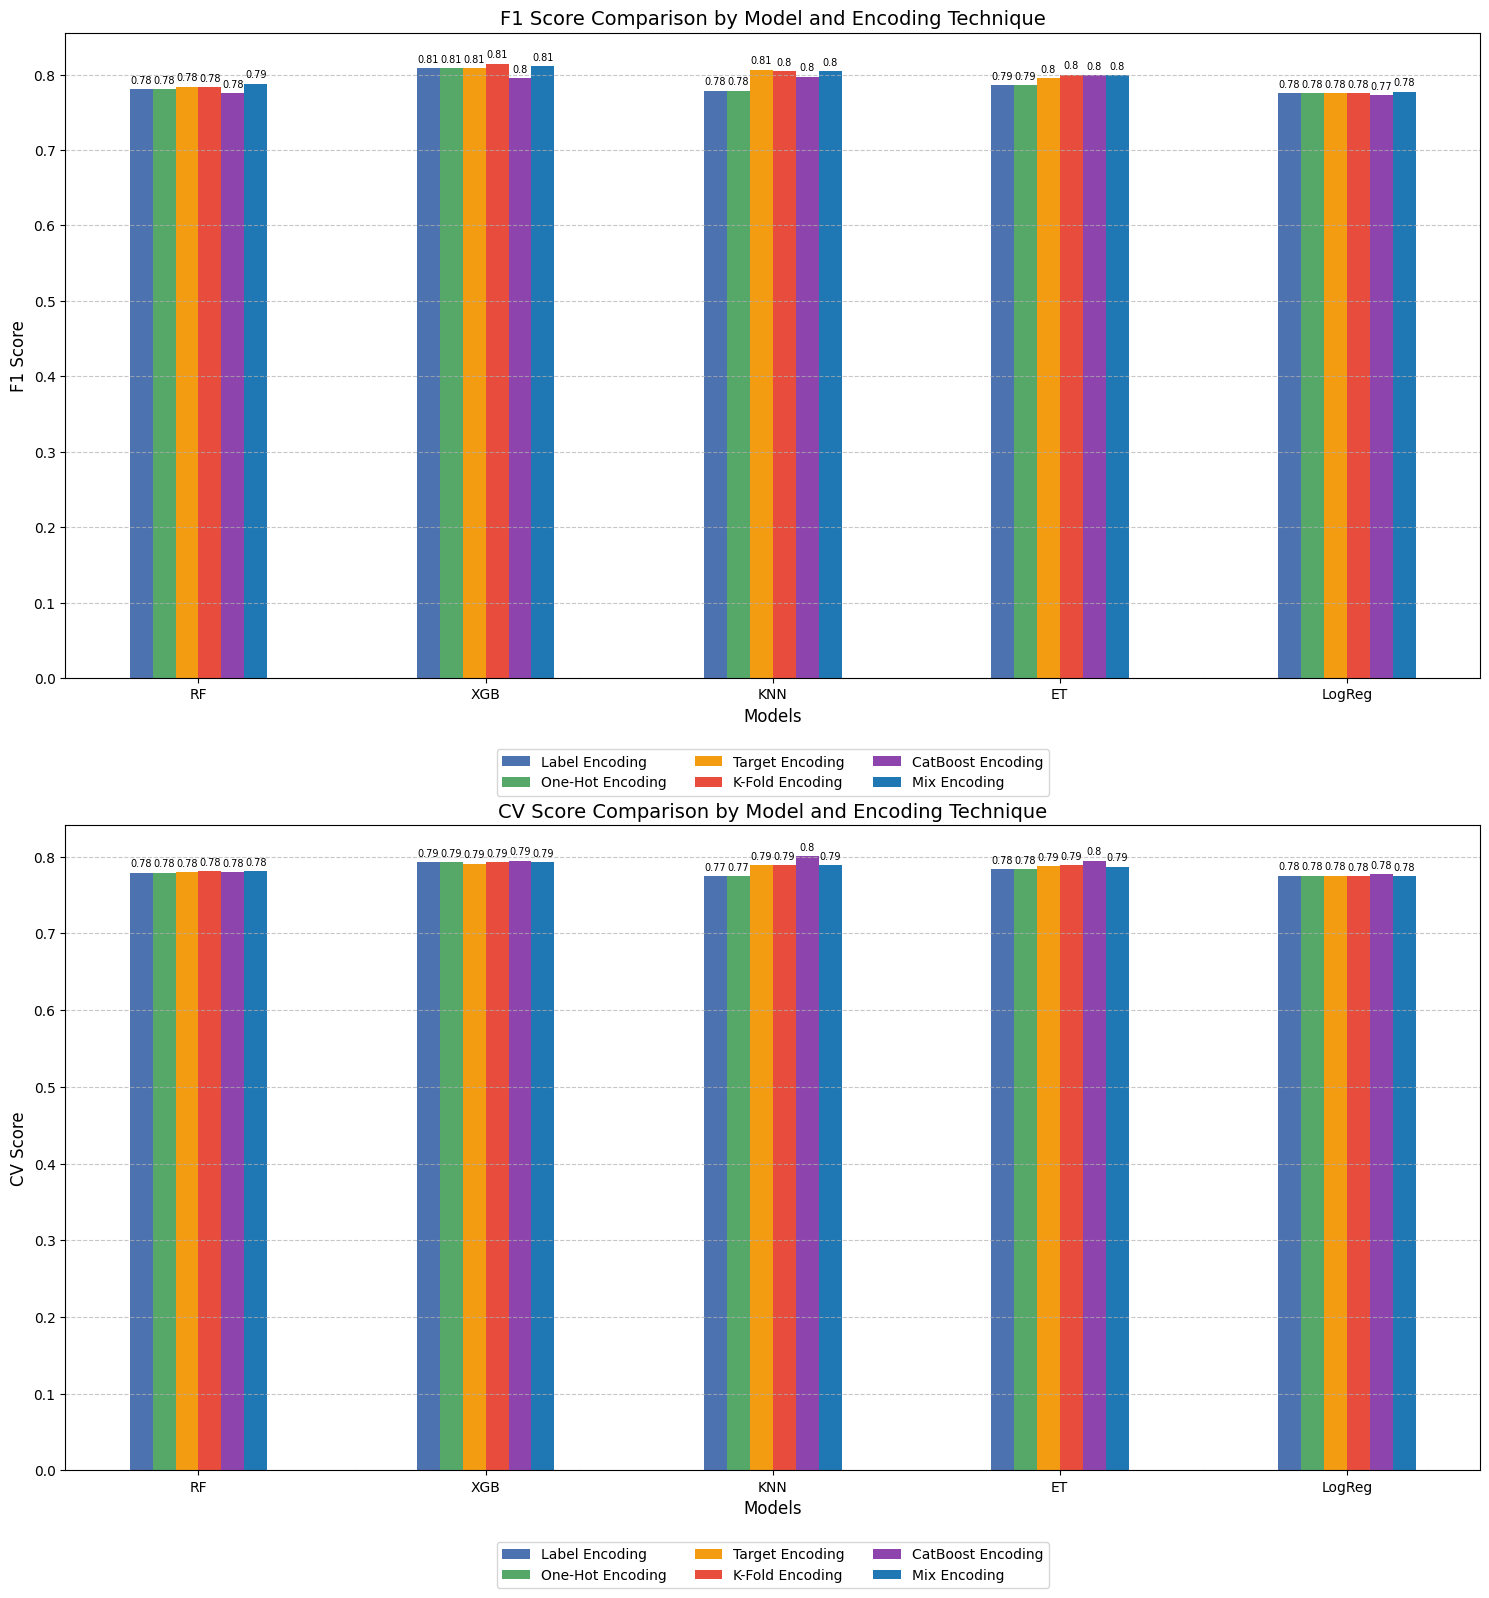

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data F1 dan CV scores dari variabel Anda
f1_rf = [le_rf_f1_score, ohe_rf_f1_score, target_rf_f1_score, kfold_rf_f1_score, catboost_rf_f1_score, mix_rf_f1_score]
cv_rf = [le_rf_cv, ohe_rf_cv, target_rf_cv, kfold_rf_cv, catboost_rf_cv, mix_rf_cv]

f1_xgb = [le_xgb_f1_score, ohe_xgb_f1_score, target_xgb_f1_score, kfold_xgb_f1_score, catboost_xgb_f1_score, mix_xgb_f1_score]
cv_xgb = [le_xgb_cv, ohe_xgb_cv, target_xgb_cv, kfold_xgb_cv, catboost_xgb_cv, mix_xgb_cv]

f1_knn = [le_knn_f1_score, ohe_knn_f1_score, target_knn_f1_score, kfold_knn_f1_score, catboost_knn_f1_score, mix_knn_f1_score]
cv_knn = [le_knn_cv, ohe_knn_cv, target_knn_cv, kfold_knn_cv, catboost_knn_cv, mix_knn_cv]

f1_et = [le_extra_trees_f1_score, ohe_extra_trees_f1_score, target_extra_trees_f1_score, kfold_extra_trees_f1_score, catboost_et_f1_score, mix_et_f1_score]
cv_et = [le_extra_trees_cv, ohe_extra_trees_cv, target_extra_trees_cv, kfold_extra_trees_cv, catboost_et_cv, mix_et_cv]

f1_lr = [le_logreg_f1_score, ohe_logreg_f1_score, target_logreg_f1_score, kfold_logreg_f1_score, catboost_lr_f1_score, mix_lr_f1_score]
cv_lr = [le_logreg_cv, ohe_logreg_cv, target_logreg_cv, kfold_logreg_cv, catboost_lr_cv, mix_lr_cv]

# Teknik encoding
encoding_methods = ['Label Encoding', 'One-Hot Encoding', 'Target Encoding', 'K-Fold Encoding', 'CatBoost Encoding', 'Mix Encoding']

# Data model
model_data_f1 = {
    'RF': dict(zip(encoding_methods, f1_rf)),
    'XGB': dict(zip(encoding_methods, f1_xgb)),
    'KNN': dict(zip(encoding_methods, f1_knn)),
    'ET': dict(zip(encoding_methods, f1_et)),
    'LogReg': dict(zip(encoding_methods, f1_lr))
}

model_data_cv = {
    'RF': dict(zip(encoding_methods, cv_rf)),
    'XGB': dict(zip(encoding_methods, cv_xgb)),
    'KNN': dict(zip(encoding_methods, cv_knn)),
    'ET': dict(zip(encoding_methods, cv_et)),
    'LogReg': dict(zip(encoding_methods, cv_lr))
}

models = list(model_data_f1.keys())
colors = ['#4c72b0', '#55a868', '#f39c12', '#e74c3c', '#8e44ad', '#1f77b4', '#ff7f0e']

x = np.arange(len(models))
width = 0.08  # Mengurangi lebar bar

fig, axes = plt.subplots(2, 1, figsize=(15, 16))  # Memperbesar ukuran figure

def create_bars(ax, x_positions, data, width, label, color):
    bars = ax.bar(x_positions, data, width, label=label, color=color)
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.005, round(yval, 2), ha='center', va='bottom', fontsize=7)  # Mengurangi font size dan jumlah desimal
    return bars

# Plot F1 Scores
for i, model_name in enumerate(models):
    for j, encoding_method in enumerate(encoding_methods):
        bar_position = x[i] - width * (len(encoding_methods) / 2 - 0.5) + j * width
        create_bars(axes[0], bar_position, [model_data_f1[model_name][encoding_method]], width, encoding_method if i == 0 else None, colors[j])

axes[0].set_xlabel('Models', fontsize=12)
axes[0].set_ylabel('F1 Score', fontsize=12)
axes[0].set_title('F1 Score Comparison by Model and Encoding Technique', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot CV Scores
for i, model_name in enumerate(models):
    for j, encoding_method in enumerate(encoding_methods):
        bar_position = x[i] - width * (len(encoding_methods) / 2 - 0.5) + j * width
        create_bars(axes[1], bar_position, [model_data_cv[model_name][encoding_method]], width, encoding_method if i == 0 else None, colors[j])

axes[1].set_xlabel('Models', fontsize=12)
axes[1].set_ylabel('CV Score', fontsize=12)
axes[1].set_title('CV Score Comparison by Model and Encoding Technique', fontsize=14)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Outlier

In [34]:
def std(data: list, ddof: int = 1) -> float:
    if ddof > 1 or ddof < 0:
        raise ValueError('ddof must be greater than 0')
    n = len(data)
    mean = sum(data) / n
    total_variance = sum((x - mean) ** 2 for x in data)
    variance = total_variance / (n - ddof)
    stdev = variance ** 0.5
    return stdev

def z_scores_1(num, data):
    mean = sum(data) / len(data)
    std_dev = std(data)
    return (num - mean) / std_dev

def detect_outliers(data, threshold=3):
    outliers = []
    mean = sum(data) / len(data)
    stdev_value = std(data)

    for i, num in enumerate(data):
        z_score = (num - mean) / stdev_value
        if abs(z_score) > threshold:
            outliers.append(i)

    return outliers

outliers_vehicles = detect_outliers(df_read['Number_of_casualties'])
print(f"Outliers pada 'Number_of_vehicles_involved': {outliers_vehicles}")

outliers_casualties = detect_outliers(df_read['Number_of_vehicles_involved'])
print(f"Outliers pada 'Number_of_casualties': {outliers_casualties}")


Outliers pada 'Number_of_vehicles_involved': [319, 320, 321, 322, 323, 324, 454, 455, 456, 457, 458, 459, 460, 463, 464, 465, 466, 467, 468, 697, 698, 699, 700, 701, 733, 734, 735, 736, 737, 920, 921, 922, 923, 924, 1140, 1141, 1142, 1143, 1144, 1145, 1381, 1382, 1383, 1384, 1385, 1386, 1387, 1575, 1576, 1577, 1578, 1579, 1580, 2490, 2491, 2492, 2493, 2494, 2495, 3686, 3687, 3688, 3689, 3690, 3691, 3692, 3693, 3803, 3804, 3805, 3806, 3807, 3808, 3809, 4086, 4087, 4088, 4089, 4090, 5058, 5059, 5060, 5061, 5062, 5095, 5096, 5097, 5098, 5099, 5100, 5428, 5429, 5430, 5431, 5432, 5433, 5697, 5698, 5699, 5700, 5701, 5702, 5712, 5713, 5714, 5715, 5716, 5955, 5956, 5957, 5958, 5959, 5960, 6020, 6021, 6022, 6023, 6024, 6025, 6221, 6222, 6223, 6224, 6225, 6232, 6233, 6234, 6235, 6236, 6237, 6238, 6327, 6328, 6329, 6330, 6331, 6332, 6333, 6408, 6409, 6410, 6411, 6412, 6413, 6414, 6911, 6912, 6913, 6914, 6915, 6916, 7024, 7025, 7026, 7027, 7028, 7215, 7216, 7217, 7218, 7219, 7431, 7432, 7433, 7434

In [35]:
def detect_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = [i for i, x in enumerate(data) if x < lower_bound or x > upper_bound]
    return outliers

outliers_vehicles_iqr = detect_outliers_iqr(df_mix['Number_of_vehicles_involved'])
print(f"Outliers pada 'Number_of_vehicles_involved' dengan IQR: {outliers_vehicles_iqr}")

outliers_casualties_iqr = detect_outliers_iqr(df_mix['Number_of_casualties'])
print(f"Outliers pada 'Number_of_casualties' dengan IQR: {outliers_casualties_iqr}")


Outliers pada 'Number_of_vehicles_involved' dengan IQR: [5, 6, 21, 27, 30, 31, 45, 72, 73, 74, 75, 76, 77, 82, 83, 95, 96, 97, 106, 107, 108, 109, 110, 111, 112, 113, 116, 117, 124, 125, 126, 127, 130, 131, 132, 133, 134, 137, 138, 139, 142, 143, 144, 145, 146, 147, 148, 149, 180, 186, 187, 188, 189, 195, 196, 197, 198, 199, 200, 219, 224, 225, 226, 227, 228, 229, 230, 240, 241, 242, 254, 262, 269, 270, 271, 279, 280, 286, 287, 288, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 307, 308, 309, 310, 311, 312, 313, 314, 325, 326, 327, 328, 333, 340, 343, 344, 347, 348, 355, 356, 360, 361, 362, 363, 364, 368, 376, 377, 378, 379, 380, 381, 386, 387, 388, 389, 390, 391, 398, 401, 409, 412, 415, 418, 419, 420, 423, 424, 425, 426, 427, 428, 432, 433, 434, 435, 442, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 463, 464, 465, 466, 467, 468, 471, 472, 483, 484, 485, 486, 490, 495, 496, 497, 503, 504, 505, 506, 509, 510, 511, 512, 513, 514, 515, 516, 532, 535

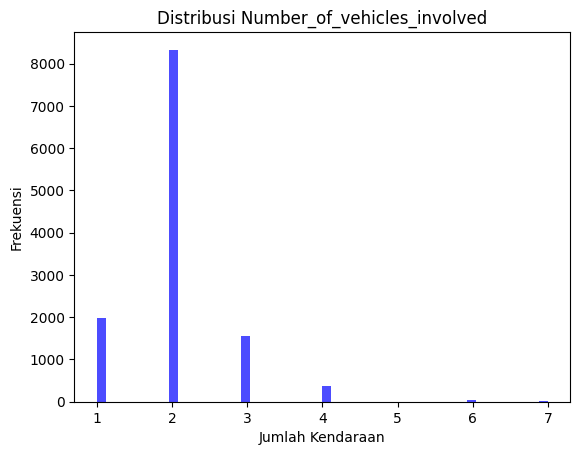

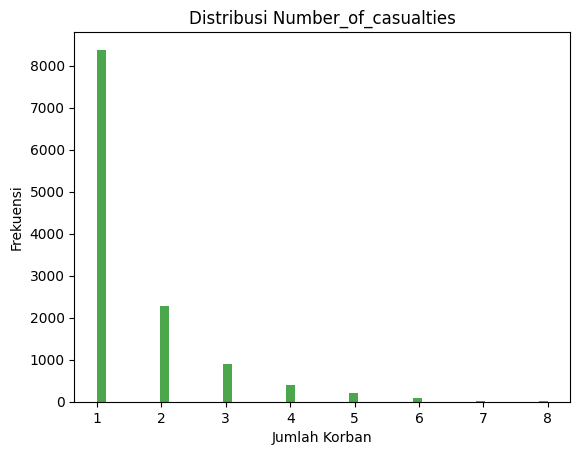

In [36]:
import matplotlib.pyplot as plt

# Visualisasikan distribusi data untuk kolom Number_of_vehicles_involved
plt.hist(df_mix['Number_of_vehicles_involved'], bins=50, color='blue', alpha=0.7)
plt.title('Distribusi Number_of_vehicles_involved')
plt.xlabel('Jumlah Kendaraan')
plt.ylabel('Frekuensi')
plt.show()

# Visualisasikan distribusi data untuk kolom Number_of_casualties
plt.hist(df_mix['Number_of_casualties'], bins=50, color='green', alpha=0.7)
plt.title('Distribusi Number_of_casualties')
plt.xlabel('Jumlah Korban')
plt.ylabel('Frekuensi')
plt.show()


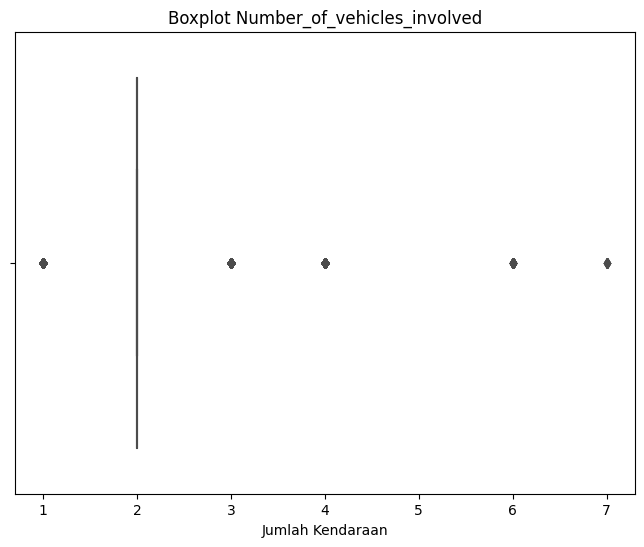

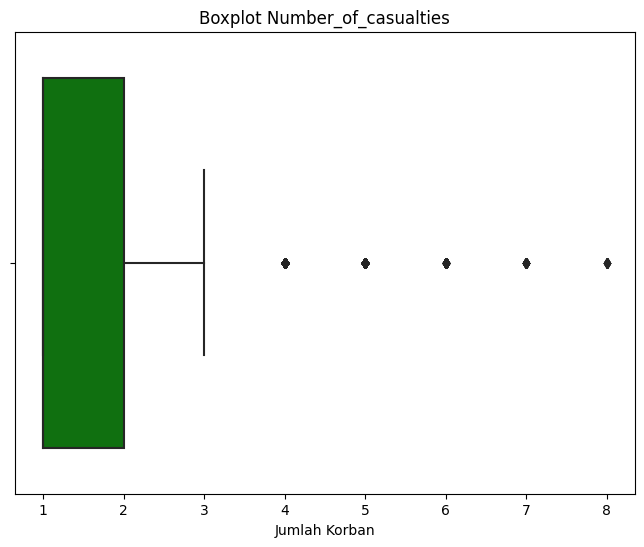

In [37]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_mix['Number_of_vehicles_involved'], color='blue')
plt.title('Boxplot Number_of_vehicles_involved')
plt.xlabel('Jumlah Kendaraan')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x=df_mix['Number_of_casualties'], color='green')
plt.title('Boxplot Number_of_casualties')
plt.xlabel('Jumlah Korban')
plt.show()


In [38]:
# df_mix.to_csv('../datasets/dataafterencod.csv', index=False)

# Feature Selection

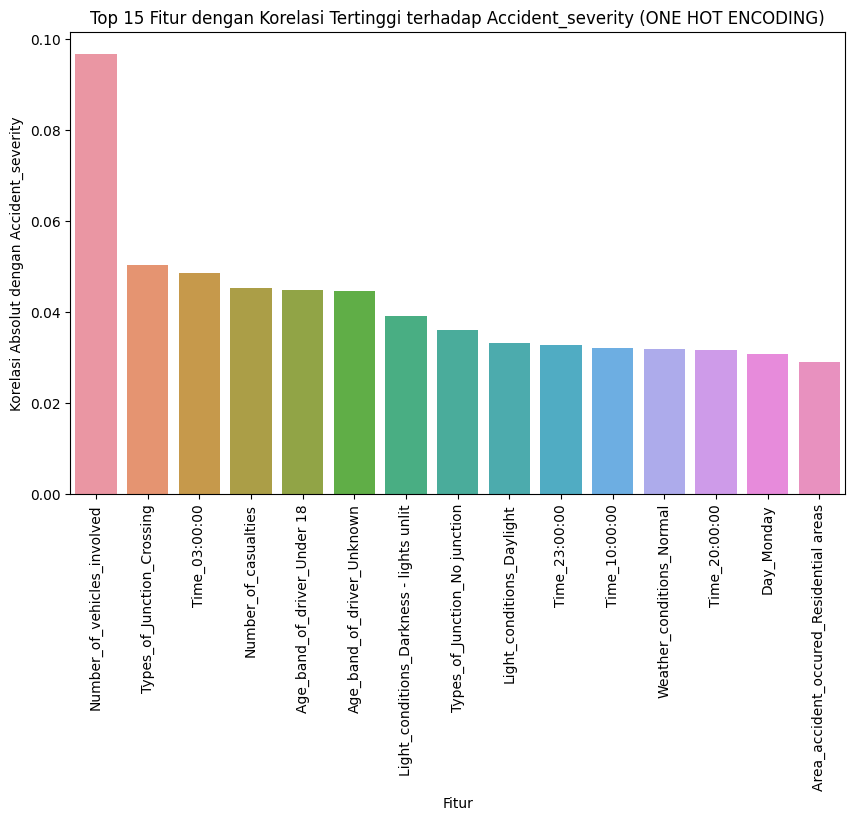

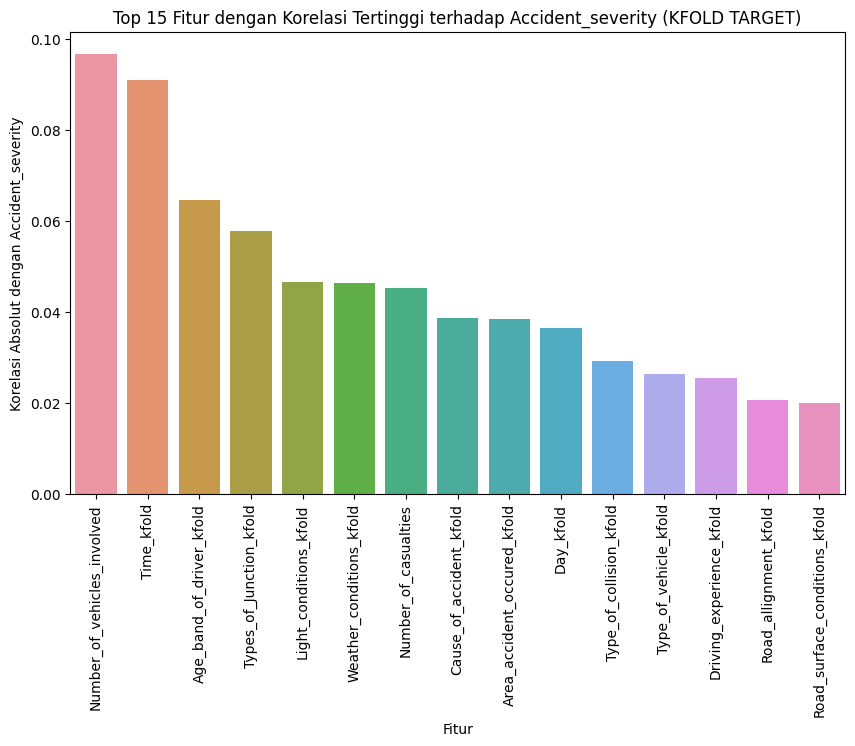

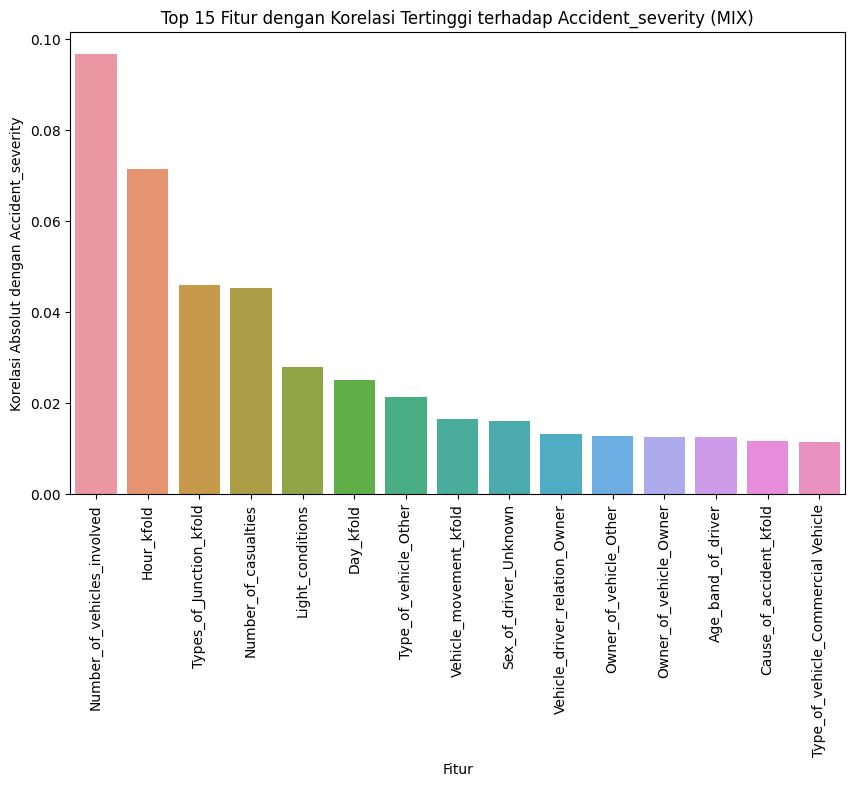

['Driving_experience',
 'Road_surface_conditions',
 'Casualty_severity',
 'Sex_of_driver_Female',
 'Sex_of_driver_Male',
 'Type_of_vehicle_Non-Motorized',
 'Type_of_vehicle_Private Vehicle',
 'Type_of_vehicle_Public Transport',
 'Owner_of_vehicle_Governmental',
 'Owner_of_vehicle_Organization',
 'Vehicle_driver_relation_Employee',
 'Vehicle_driver_relation_Other',
 'Vehicle_driver_relation_Unknown',
 'Road_surface_type_Asphalt roads',
 'Road_surface_type_Earth roads',
 'Road_surface_type_Gravel roads',
 'Road_surface_type_Other',
 'Type_of_collision_kfold',
 'Lanes_or_Medians_kfold',
 'Area_accident_occured_kfold',
 'Road_allignment_kfold']

In [39]:
# ohe
corr_matrix = df_ohe.corr()
target_corr = corr_matrix["Accident_severity"].drop("Accident_severity")

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.abs().sort_values(ascending=False)[:15].index,
            y=target_corr.abs().sort_values(ascending=False)[:15])
plt.xticks(rotation=90)
plt.xlabel("Fitur")
plt.ylabel("Korelasi Absolut dengan Accident_severity")
plt.title("Top 15 Fitur dengan Korelasi Tertinggi terhadap Accident_severity (ONE HOT ENCODING)")
plt.show()

low_corr_features = target_corr[abs(target_corr) < 0.01].index.tolist()
low_corr_features

# kfold
corr_matrix = df_kfold.corr()
target_corr = corr_matrix["Accident_severity"].drop("Accident_severity")

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.abs().sort_values(ascending=False)[:15].index,
            y=target_corr.abs().sort_values(ascending=False)[:15])
plt.xticks(rotation=90)
plt.xlabel("Fitur")
plt.ylabel("Korelasi Absolut dengan Accident_severity")
plt.title("Top 15 Fitur dengan Korelasi Tertinggi terhadap Accident_severity (KFOLD TARGET)")
plt.show()

low_corr_features = target_corr[abs(target_corr) < 0.01].index.tolist()
low_corr_features

# mix
corr_matrix = df_mix.corr()
target_corr = corr_matrix["Accident_severity"].drop("Accident_severity")

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.abs().sort_values(ascending=False)[:15].index,
            y=target_corr.abs().sort_values(ascending=False)[:15])
plt.xticks(rotation=90)
plt.xlabel("Fitur")
plt.ylabel("Korelasi Absolut dengan Accident_severity")
plt.title("Top 15 Fitur dengan Korelasi Tertinggi terhadap Accident_severity (MIX)")
plt.show()

low_corr_features = target_corr[abs(target_corr) < 0.01].index.tolist()
low_corr_features



# lassso

Fitur yang dipilih oleh Lasso:
['Age_band_of_driver', 'Driving_experience', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Casualty_severity', 'Sex_of_driver_Female', 'Sex_of_driver_Male', 'Sex_of_driver_Unknown', 'Type_of_vehicle_Commercial Vehicle', 'Type_of_vehicle_Non-Motorized', 'Type_of_vehicle_Other', 'Type_of_vehicle_Private Vehicle', 'Type_of_vehicle_Special Vehicle', 'Owner_of_vehicle_Governmental', 'Owner_of_vehicle_Organization', 'Owner_of_vehicle_Other', 'Owner_of_vehicle_Owner', 'Vehicle_driver_relation_Employee', 'Vehicle_driver_relation_Other', 'Vehicle_driver_relation_Owner', 'Road_surface_type_Asphalt roads with some distress', 'Road_surface_type_Earth roads', 'Road_surface_type_Gravel roads', 'Road_surface_type_Other', 'Types_of_Junction_kfold', 'Lanes_or_Medians_kfold', 'Hour_kfold', 'Road_allignment_kfold', 'Vehicle_movement_kfold']


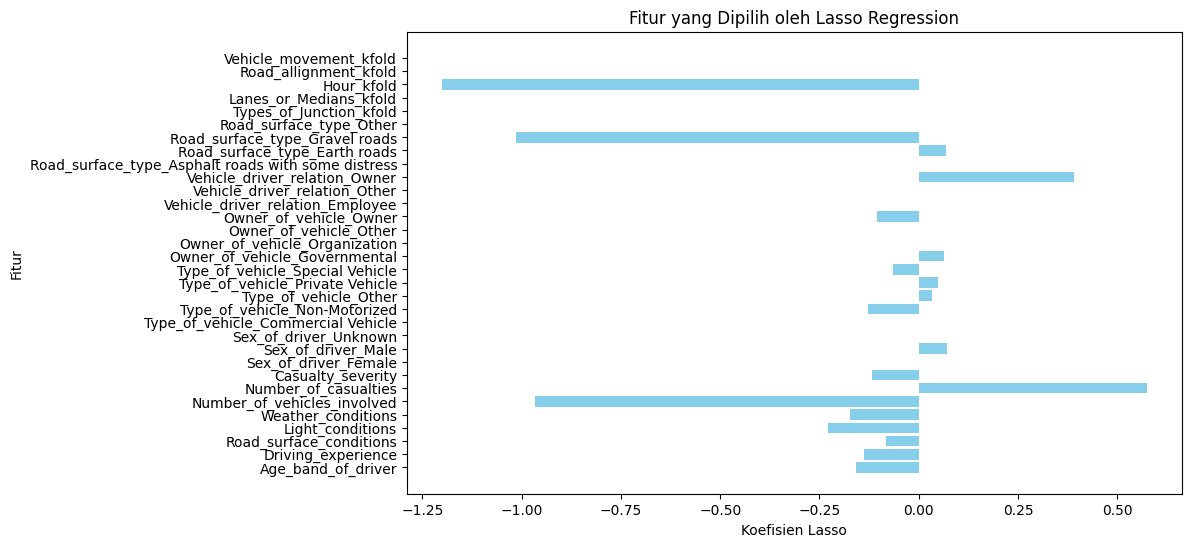

In [40]:
lasso = LogisticRegression(penalty="l1", solver="liblinear", random_state=42)
lasso.fit(X_train_mix, y_train_mix)

model = SelectFromModel(lasso, prefit=True)
selected_lasso_features = X_train_mix.columns[model.get_support()].tolist()

print("Fitur yang dipilih oleh Lasso:")
print(selected_lasso_features)

coefficients = lasso.coef_[0]

selected_coefficients = coefficients[[X_train_mix.columns.get_loc(f) for f in selected_lasso_features]]

plt.figure(figsize=(10, 6))
plt.barh(selected_lasso_features, selected_coefficients, color='skyblue')
plt.xlabel('Koefisien Lasso')
plt.ylabel('Fitur')
plt.title('Fitur yang Dipilih oleh Lasso Regression')
plt.show()



Fitur yang dipilih oleh Lasso:
['Number_of_vehicles_involved', 'Number_of_casualties', 'Time_00:00:00', 'Time_02:00:00', 'Time_03:00:00', 'Time_04:00:00', 'Time_05:00:00', 'Time_06:00:00', 'Time_07:00:00', 'Time_08:00:00', 'Time_09:00:00', 'Time_10:00:00', 'Time_11:00:00', 'Time_12:00:00', 'Time_13:00:00', 'Time_14:00:00', 'Time_15:00:00', 'Time_16:00:00', 'Time_17:00:00', 'Time_18:00:00', 'Time_19:00:00', 'Time_20:00:00', 'Time_21:00:00', 'Time_22:00:00', 'Time_23:00:00', 'Age_band_of_driver_18-30', 'Age_band_of_driver_31-50', 'Age_band_of_driver_Over 51', 'Age_band_of_driver_Under 18', 'Age_band_of_driver_Unknown', 'Sex_of_driver_Female', 'Sex_of_driver_Male', 'Sex_of_driver_Unknown', 'Vehicle_driver_relation_Employee', 'Vehicle_driver_relation_Other', 'Vehicle_driver_relation_Owner', 'Vehicle_driver_relation_Unknown', 'Driving_experience_1-2yr', 'Driving_experience_2-5yr', 'Driving_experience_5-10yr', 'Driving_experience_Above 10yr', 'Driving_experience_Below 1yr', 'Driving_experien

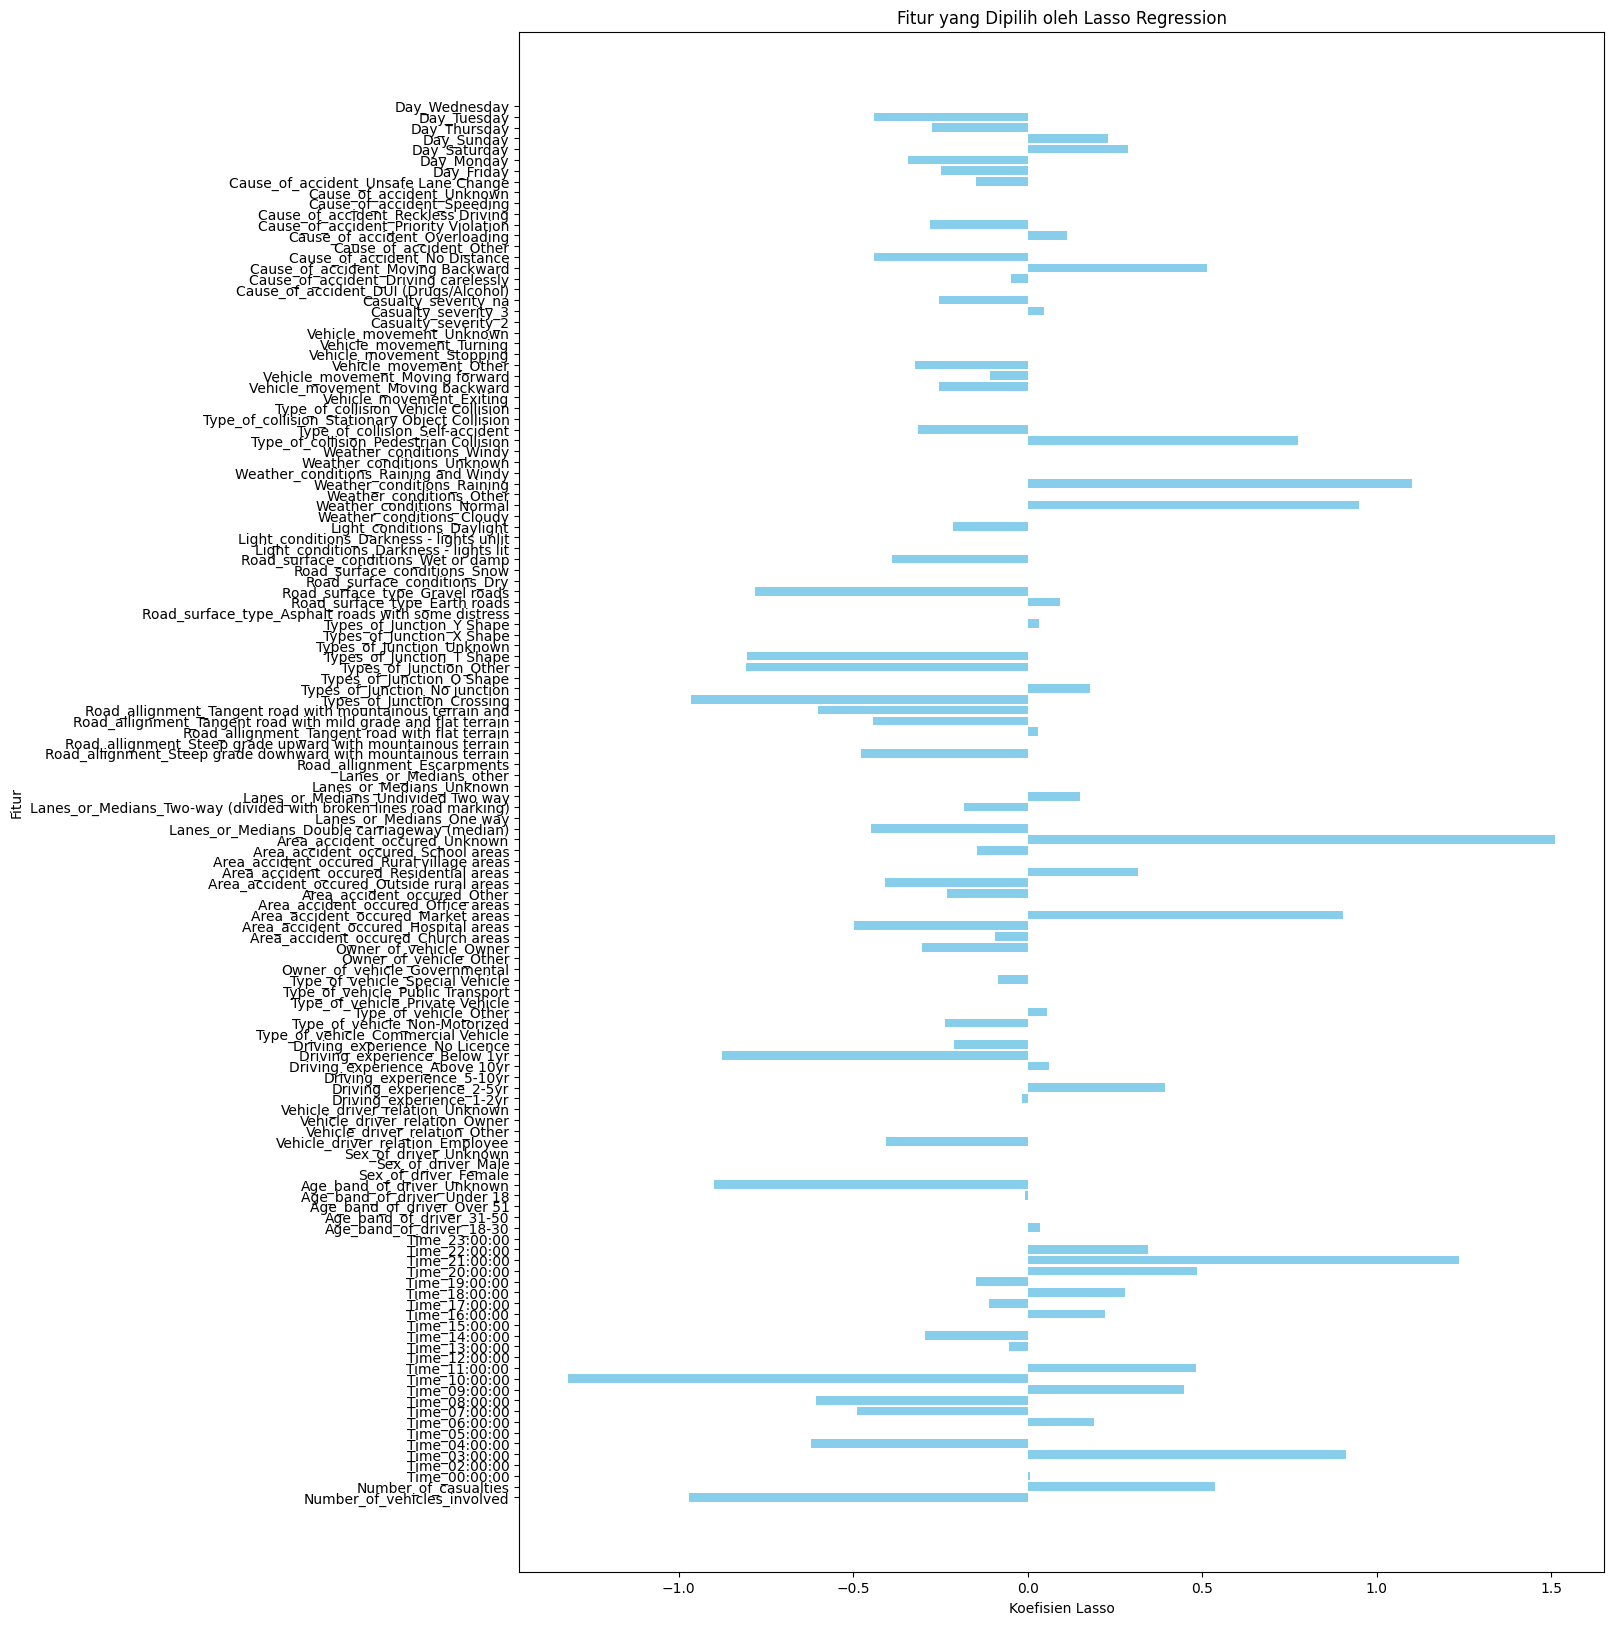

In [41]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# Melatih model Lasso
lasso = LogisticRegression(penalty="l1", solver="liblinear", random_state=42)
lasso.fit(X_train_ohe, y_train_ohe)

# Seleksi fitur dengan Lasso
model = SelectFromModel(lasso, prefit=True)
selected_lasso_features = X_train_ohe.columns[model.get_support()].tolist()

print("Fitur yang dipilih oleh Lasso:")
print(selected_lasso_features)

# Ambil koefisien dari fitur yang dipilih
coefficients = lasso.coef_[0]
selected_coefficients = coefficients[[X_train_ohe.columns.get_loc(f) for f in selected_lasso_features]]

# Meningkatkan ukuran gambar
plt.figure(figsize=(14, 20))  # Mengatur ukuran gambar lebih besar
plt.barh(selected_lasso_features, selected_coefficients, color='skyblue')
plt.xlabel('Koefisien Lasso')
plt.ylabel('Fitur')
plt.title('Fitur yang Dipilih oleh Lasso Regression')
plt.show()


Fitur yang dipilih oleh Lasso:
['Number_of_vehicles_involved', 'Number_of_casualties', 'Time_kfold', 'Age_band_of_driver_kfold', 'Sex_of_driver_kfold', 'Vehicle_driver_relation_kfold', 'Driving_experience_kfold', 'Owner_of_vehicle_kfold', 'Lanes_or_Medians_kfold', 'Road_allignment_kfold', 'Types_of_Junction_kfold', 'Road_surface_type_kfold', 'Road_surface_conditions_kfold', 'Weather_conditions_kfold', 'Vehicle_movement_kfold', 'Casualty_severity_kfold', 'Day_kfold']


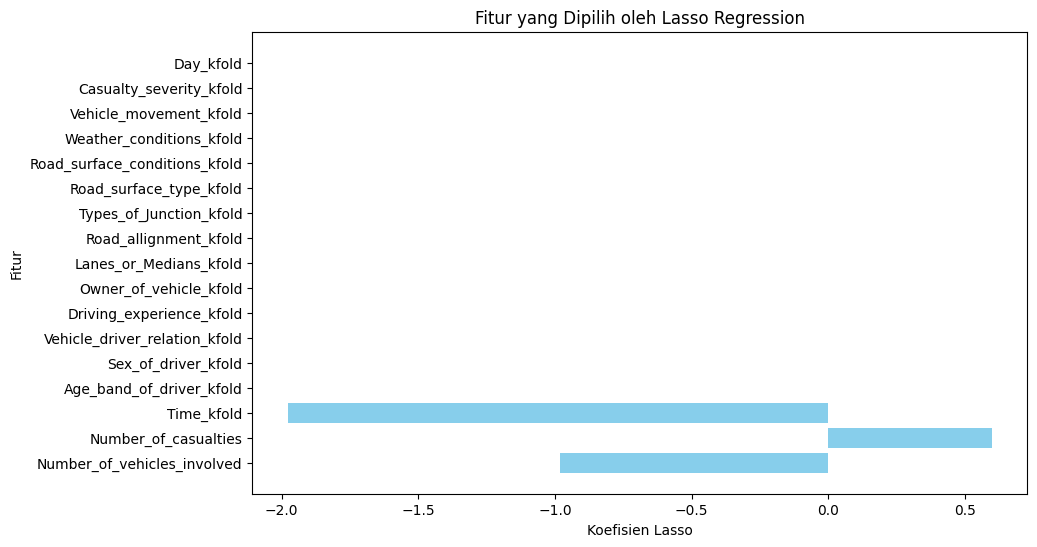

In [42]:
lasso = LogisticRegression(penalty="l1", solver="liblinear", random_state=42)
lasso.fit(X_train_kfold, y_train_kfold)

model = SelectFromModel(lasso, prefit=True)
selected_lasso_features = X_train_kfold.columns[model.get_support()].tolist()

print("Fitur yang dipilih oleh Lasso:")
print(selected_lasso_features)

coefficients = lasso.coef_[0]

selected_coefficients = coefficients[[X_train_kfold.columns.get_loc(f) for f in selected_lasso_features]]

plt.figure(figsize=(10, 6))
plt.barh(selected_lasso_features, selected_coefficients, color='skyblue')
plt.xlabel('Koefisien Lasso')
plt.ylabel('Fitur')
plt.title('Fitur yang Dipilih oleh Lasso Regression')
plt.show()


In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA

target_column = 'Accident_severity'
corr_matrix = df_mix.corr()
target_corr = corr_matrix[target_column].abs().sort_values(ascending=False)
selected_features_corr_mix = target_corr[target_corr > 0.05].index.tolist()
selected_features_corr_mix.remove(target_column)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(rf, n_features_to_select=10)
rfe.fit(X_train_mix, y_train_mix)
selected_features_rfe_mix = X_train_mix.columns[rfe.support_].tolist()

lasso = LassoCV(cv=5, random_state=42).fit(X_train_mix, y_train_mix)
model = SelectFromModel(lasso, prefit=True)
selected_features_lasso_mix = X_train_mix.columns[model.get_support()].tolist()

pca = PCA(n_components=0.95, random_state=42)
X_train_pca_mix = pca.fit_transform(X_train_mix)
X_test_pca_mix = pca.transform(X_test_mix)

len(selected_features_corr_mix), len(selected_features_rfe_mix), len(selected_features_lasso_mix), X_train_pca_mix.shape[1]


(2, 10, 24, 12)

Fitur yang dipilih berdasarkan korelasi: 2
Fitur yang dipilih dengan RFE: 10
Fitur yang dipilih dengan Lasso: 24
Jumlah komponen PCA: 12


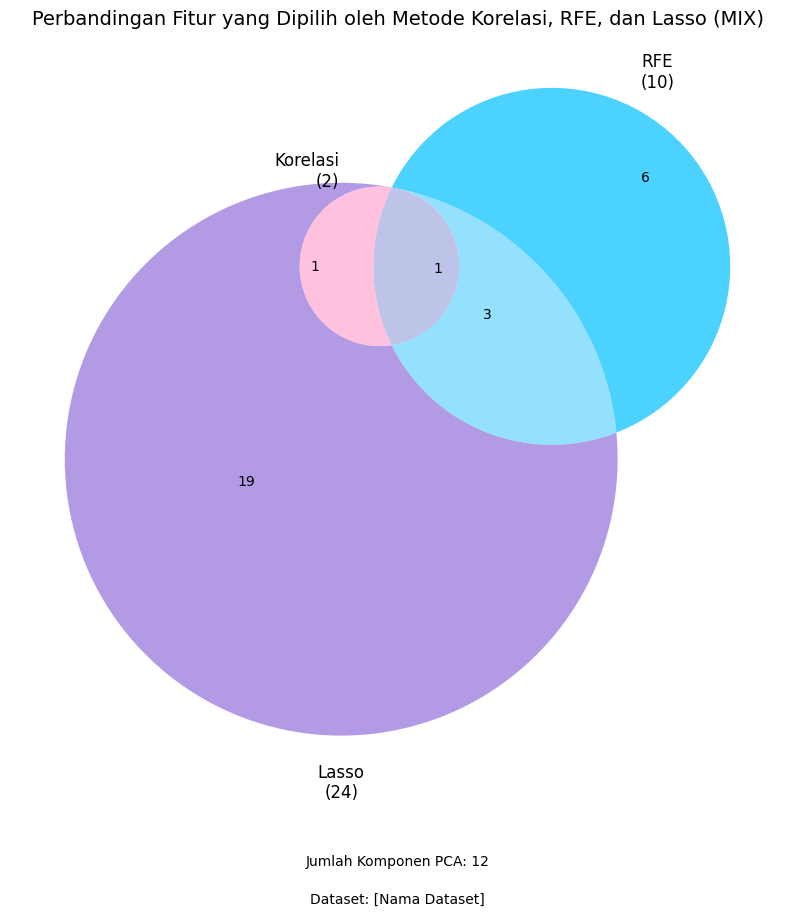

In [44]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

print(f"Fitur yang dipilih berdasarkan korelasi: {len(selected_features_corr_mix)}")
print(f"Fitur yang dipilih dengan RFE: {len(selected_features_rfe_mix)}")
print(f"Fitur yang dipilih dengan Lasso: {len(selected_features_lasso_mix)}")
print(f"Jumlah komponen PCA: {X_train_pca_mix.shape[1]}")

venn_labels = {
    '100': len(set(selected_features_corr_mix) - set(selected_features_rfe_mix) - set(selected_features_lasso_mix)),
    '010': len(set(selected_features_rfe_mix) - set(selected_features_corr_mix) - set(selected_features_lasso_mix)),
    '001': len(set(selected_features_lasso_mix) - set(selected_features_corr_mix) - set(selected_features_rfe_mix)),
    '110': len(set(selected_features_corr_mix) & set(selected_features_rfe_mix) - set(selected_features_lasso_mix)),
    '101': len(set(selected_features_corr_mix) & set(selected_features_lasso_mix) - set(selected_features_rfe_mix)),
    '011': len(set(selected_features_rfe_mix) & set(selected_features_lasso_mix) - set(selected_features_corr_mix)),
    '111': len(set(selected_features_corr_mix) & set(selected_features_rfe_mix) & set(selected_features_lasso_mix))
}

plt.figure(figsize=(10, 10))
v = venn3(subsets=venn_labels, set_labels=('Korelasi', 'RFE', 'Lasso'), alpha=0.7,
          set_colors=('coral', 'deepskyblue', 'mediumpurple'))

if v.set_labels:
    v.set_labels[0].set_text(f"Korelasi\n({len(selected_features_corr_mix)})")
    v.set_labels[1].set_text(f"RFE\n({len(selected_features_rfe_mix)})")
    v.set_labels[2].set_text(f"Lasso\n({len(selected_features_lasso_mix)})")

plt.title('Perbandingan Fitur yang Dipilih oleh Metode Korelasi, RFE, dan Lasso (MIX)', fontsize=14)
plt.annotate(f"Jumlah Komponen PCA: {X_train_pca_mix.shape[1]}", xy=(0.5, -0.1), xycoords='axes fraction', ha='center', fontsize=10)
plt.annotate("Dataset: [Nama Dataset]", xy=(0.5, -0.15), xycoords='axes fraction', ha='center', fontsize=10)
plt.show()

In [45]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_weighted').mean()
    return f1, cv_scores

rf_model_all_mix = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_f1_all_mix, rf_cv_all_mix = evaluate_model(rf_model_all_mix, X_train_mix, X_test_mix, y_train_mix, y_test_mix)

xgb_model_all_mix = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_f1_all_mix, xgb_cv_all_mix = evaluate_model(xgb_model_all_mix, X_train_mix, X_test_mix, y_train_mix, y_test_mix)

lr_model_all_mix = LogisticRegression(max_iter=1000, random_state=42)
lr_f1_all_mix, lr_cv_all_mix = evaluate_model(lr_model_all_mix, X_train_mix, X_test_mix, y_train_mix, y_test_mix)

knn_model_all_mix = KNeighborsClassifier(n_neighbors=5)
knn_f1_all_mix, knn_cv_all_mix = evaluate_model(knn_model_all_mix, X_train_mix, X_test_mix, y_train_mix, y_test_mix)

et_model_all_mix = ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced')
et_f1_all_mix, et_cv_all_mix = evaluate_model(et_model_all_mix, X_train_mix, X_test_mix, y_train_mix, y_test_mix)

rf_rfe_mix = RandomForestClassifier(n_estimators=100, random_state=42)
rfe_mix = RFE(rf_rfe_mix, n_features_to_select=10)
rfe_mix.fit(X_train_mix, y_train_mix)
selected_features_rfe_mix = X_train_mix.columns[rfe_mix.support_].tolist()
X_train_rfe_mix = X_train_mix[selected_features_rfe_mix]
X_test_rfe_mix = X_test_mix[selected_features_rfe_mix]

rf_f1_rfe_mix, rf_cv_rfe_mix = evaluate_model(rf_rfe_mix, X_train_rfe_mix, X_test_rfe_mix, y_train_mix, y_test_mix)
xgb_f1_rfe_mix, xgb_cv_rfe_mix = evaluate_model(xgb_model_all_mix, X_train_rfe_mix, X_test_rfe_mix, y_train_mix, y_test_mix)
lr_f1_rfe_mix, lr_cv_rfe_mix = evaluate_model(lr_model_all_mix, X_train_rfe_mix, X_test_rfe_mix, y_train_mix, y_test_mix)
knn_f1_rfe_mix, knn_cv_rfe_mix = evaluate_model(knn_model_all_mix, X_train_rfe_mix, X_test_rfe_mix, y_train_mix, y_test_mix)
et_f1_rfe_mix, et_cv_rfe_mix = evaluate_model(et_model_all_mix, X_train_rfe_mix, X_test_rfe_mix, y_train_mix, y_test_mix)

lasso_mix = LassoCV(cv=5, random_state=42).fit(X_train_mix, y_train_mix)
model_lasso_mix = SelectFromModel(lasso_mix, prefit=True)
selected_features_lasso_mix = X_train_mix.columns[model_lasso_mix.get_support()].tolist()
X_train_lasso_mix = X_train_mix[selected_features_lasso_mix]
X_test_lasso_mix = X_test_mix[selected_features_lasso_mix]

rf_f1_lasso_mix, rf_cv_lasso_mix = evaluate_model(rf_model_all_mix, X_train_lasso_mix, X_test_lasso_mix, y_train_mix, y_test_mix)
xgb_f1_lasso_mix, xgb_cv_lasso_mix = evaluate_model(xgb_model_all_mix, X_train_lasso_mix, X_test_lasso_mix, y_train_mix, y_test_mix)
lr_f1_lasso_mix, lr_cv_lasso_mix = evaluate_model(lr_model_all_mix, X_train_lasso_mix, X_test_lasso_mix, y_train_mix, y_test_mix)
knn_f1_lasso_mix, knn_cv_lasso_mix = evaluate_model(knn_model_all_mix, X_train_lasso_mix, X_test_lasso_mix, y_train_mix, y_test_mix)
et_f1_lasso_mix, et_cv_lasso_mix = evaluate_model(et_model_all_mix, X_train_lasso_mix, X_test_lasso_mix, y_train_mix, y_test_mix)

pca_mix = PCA(n_components=0.95, random_state=42)
X_train_pca_mix = pca_mix.fit_transform(X_train_mix)
X_test_pca_mix = pca_mix.transform(X_test_mix)

rf_f1_pca_mix, rf_cv_pca_mix = evaluate_model(rf_model_all_mix, X_train_pca_mix, X_test_pca_mix, y_train_mix, y_test_mix)
xgb_f1_pca_mix, xgb_cv_pca_mix = evaluate_model(xgb_model_all_mix, X_train_pca_mix, X_test_pca_mix, y_train_mix, y_test_mix)
lr_f1_pca_mix, lr_cv_pca_mix = evaluate_model(lr_model_all_mix, X_train_pca_mix, X_test_pca_mix, y_train_mix, y_test_mix)
knn_f1_pca_mix, knn_cv_pca_mix = evaluate_model(knn_model_all_mix, X_train_pca_mix, X_test_pca_mix, y_train_mix, y_test_mix)
et_f1_pca_mix, et_cv_pca_mix = evaluate_model(et_model_all_mix, X_train_pca_mix, X_test_pca_mix, y_train_mix, y_test_mix)

print("\nHasil Evaluasi Model dengan Semua Fitur:")
print("------------------------------------------------")
print(f"Random Forest - F1 Score: {rf_f1_all_mix:.4f}, Cross-Validation F1 Score: {rf_cv_all_mix:.4f}")
print(f"XGBoost - F1 Score: {xgb_f1_all_mix:.4f}, Cross-Validation F1 Score: {xgb_cv_all_mix:.4f}")
print(f"Logistic Regression - F1 Score: {lr_f1_all_mix:.4f}, Cross-Validation F1 Score: {lr_cv_all_mix:.4f}")
print(f"KNN - F1 Score: {knn_f1_all_mix:.4f}, Cross-Validation F1 Score: {knn_cv_all_mix:.4f}")
print(f"Extra Trees - F1 Score: {et_f1_all_mix:.4f}, Cross-Validation F1 Score: {et_cv_all_mix:.4f}")
print("------------------------------------------------\n")

print("\nHasil Evaluasi Model dengan RFE:")
print("------------------------------------------------")
print(f"Random Forest - F1 Score: {rf_f1_rfe_mix:.4f}, Cross-Validation F1 Score: {rf_cv_rfe_mix:.4f}")
print(f"XGBoost - F1 Score: {xgb_f1_rfe_mix:.4f}, Cross-Validation F1 Score: {xgb_cv_rfe_mix:.4f}")
print(f"Logistic Regression - F1 Score: {lr_f1_rfe_mix:.4f}, Cross-Validation F1 Score: {lr_cv_rfe_mix:.4f}")
print(f"KNN - F1 Score: {knn_f1_rfe_mix:.4f}, Cross-Validation F1 Score: {knn_cv_rfe_mix:.4f}")
print(f"Extra Trees - F1 Score: {et_f1_rfe_mix:.4f}, Cross-Validation F1 Score: {et_cv_rfe_mix:.4f}")
print("------------------------------------------------\n")

print("\nHasil Evaluasi Model dengan Lasso:")
print("------------------------------------------------")
print(f"Random Forest - F1 Score: {rf_f1_lasso_mix:.4f}, Cross-Validation F1 Score: {rf_cv_lasso_mix:.4f}")
print(f"XGBoost - F1 Score: {xgb_f1_lasso_mix:.4f}, Cross-Validation F1 Score: {xgb_cv_lasso_mix:.4f}")
print(f"Logistic Regression - F1 Score: {lr_f1_lasso_mix:.4f}, Cross-Validation F1 Score: {lr_cv_lasso_mix:.4f}")
print(f"KNN - F1 Score: {knn_f1_lasso_mix:.4f}, Cross-Validation F1 Score: {knn_cv_lasso_mix:.4f}")
print(f"Extra Trees - F1 Score: {et_f1_lasso_mix:.4f}, Cross-Validation F1 Score: {et_cv_lasso_mix:.4f}")
print("------------------------------------------------\n")

print("\nHasil Evaluasi Model dengan PCA:")
print("------------------------------------------------")
print(f"Random Forest - F1 Score: {rf_f1_pca_mix:.4f}, Cross-Validation F1 Score: {rf_cv_pca_mix:.4f}")
print(f"XGBoost - F1 Score: {xgb_f1_pca_mix:.4f}, Cross-Validation F1 Score: {xgb_cv_pca_mix:.4f}")
print(f"Logistic Regression - F1 Score: {lr_f1_pca_mix:.4f}, Cross-Validation F1 Score: {lr_cv_pca_mix:.4f}")
print(f"KNN - F1 Score: {knn_f1_pca_mix:.4f}, Cross-Validation F1 Score: {knn_cv_pca_mix:.4f}")
print(f"Extra Trees - F1 Score: {et_f1_pca_mix:.4f}, Cross-Validation F1 Score: {et_cv_pca_mix:.4f}")
print("------------------------------------------------\n")



Hasil Evaluasi Model dengan Semua Fitur:
------------------------------------------------
Random Forest - F1 Score: 0.7753, Cross-Validation F1 Score: 0.7759
XGBoost - F1 Score: 0.7994, Cross-Validation F1 Score: 0.7962
Logistic Regression - F1 Score: 0.7753, Cross-Validation F1 Score: 0.7752
KNN - F1 Score: 0.7794, Cross-Validation F1 Score: 0.7809
Extra Trees - F1 Score: 0.7803, Cross-Validation F1 Score: 0.7790
------------------------------------------------


Hasil Evaluasi Model dengan RFE:
------------------------------------------------
Random Forest - F1 Score: 0.7776, Cross-Validation F1 Score: 0.7755
XGBoost - F1 Score: 0.7775, Cross-Validation F1 Score: 0.7783
Logistic Regression - F1 Score: 0.7753, Cross-Validation F1 Score: 0.7752
KNN - F1 Score: 0.7732, Cross-Validation F1 Score: 0.7725
Extra Trees - F1 Score: 0.7841, Cross-Validation F1 Score: 0.7743
------------------------------------------------


Hasil Evaluasi Model dengan Lasso:
----------------------------------

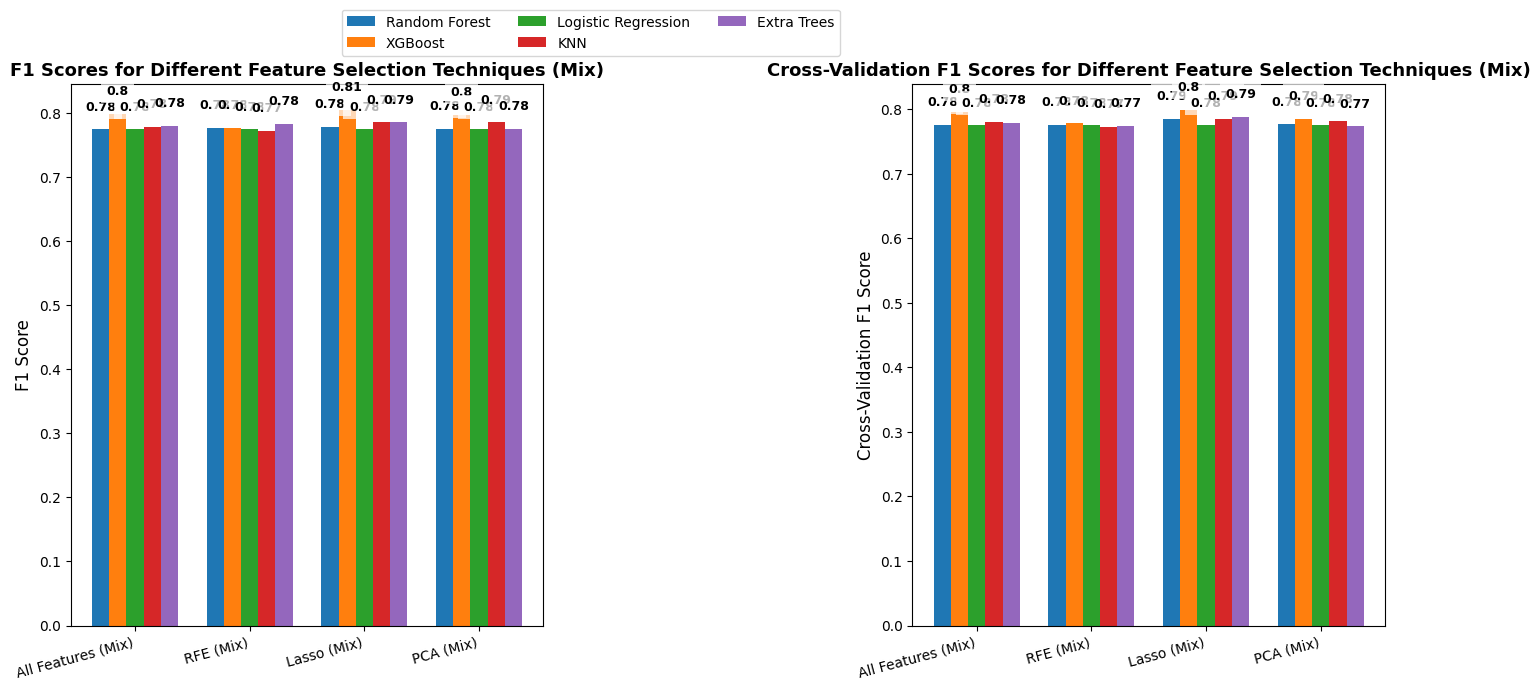

In [46]:
import numpy as np
import matplotlib.pyplot as plt

models = ['Random Forest', 'XGBoost', 'Logistic Regression', 'KNN', 'Extra Trees']
features = ['All Features (Mix)', 'RFE (Mix)', 'Lasso (Mix)', 'PCA (Mix)']

f1_scores_mix = {
    'Random Forest': [rf_f1_all_mix, rf_f1_rfe_mix, rf_f1_lasso_mix, rf_f1_pca_mix],
    'XGBoost': [xgb_f1_all_mix, xgb_f1_rfe_mix, xgb_f1_lasso_mix, xgb_f1_pca_mix],
    'Logistic Regression': [lr_f1_all_mix, lr_f1_rfe_mix, lr_f1_lasso_mix, lr_f1_pca_mix],
    'KNN': [knn_f1_all_mix, knn_f1_rfe_mix, knn_f1_lasso_mix, knn_f1_pca_mix],
    'Extra Trees': [et_f1_all_mix, et_f1_rfe_mix, et_f1_lasso_mix, et_f1_pca_mix],
}

cv_scores_mix = {
    'Random Forest': [rf_cv_all_mix, rf_cv_rfe_mix, rf_cv_lasso_mix, rf_cv_pca_mix],
    'XGBoost': [xgb_cv_all_mix, xgb_cv_rfe_mix, xgb_cv_lasso_mix, xgb_cv_pca_mix],
    'Logistic Regression': [lr_cv_all_mix, lr_cv_rfe_mix, lr_cv_lasso_mix, lr_cv_pca_mix],
    'KNN': [knn_cv_all_mix, knn_cv_rfe_mix, knn_cv_lasso_mix, knn_cv_pca_mix],
    'Extra Trees': [et_cv_all_mix, et_cv_rfe_mix, et_cv_lasso_mix, et_cv_pca_mix],
}

x = np.arange(len(features))
bar_width = 0.15

fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Plot F1 Score
for idx, model in enumerate(models):
    bars = ax[0].bar(x + idx * bar_width, f1_scores_mix[model], width=bar_width, label=model)
    for bar in bars:
        yval = bar.get_height()
        ax[0].text(bar.get_x() + bar.get_width()/2, yval + 0.025, round(yval, 2),
                   ha='center', va='bottom', fontsize=9, fontweight='bold',
                   bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# Plot Cross-Validation Score
for idx, model in enumerate(models):
    bars = ax[1].bar(x + idx * bar_width, cv_scores_mix[model], width=bar_width, label=model)
    for bar in bars:
        yval = bar.get_height()
        ax[1].text(bar.get_x() + bar.get_width()/2, yval + 0.025, round(yval, 2),
                   ha='center', va='bottom', fontsize=9, fontweight='bold',
                   bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# Atur sumbu X agar label berada di tengah grup
ax[0].set_xticks(x + (bar_width * (len(models) - 1) / 2))
ax[0].set_xticklabels(features, rotation=15, ha='right')
ax[0].set_title('F1 Scores for Different Feature Selection Techniques (Mix)', fontsize=13, fontweight='bold')
ax[0].set_ylabel('F1 Score', fontsize=12)

ax[1].set_xticks(x + (bar_width * (len(models) - 1) / 2))
ax[1].set_xticklabels(features, rotation=15, ha='right')
ax[1].set_title('Cross-Validation F1 Scores for Different Feature Selection Techniques (Mix)', fontsize=13, fontweight='bold')
ax[1].set_ylabel('Cross-Validation F1 Score', fontsize=12)

# Gabungkan legenda di satu subplot agar lebih rapi
ax[0].legend(loc='upper center', bbox_to_anchor=(1.1, 1.15), ncol=3, fontsize=10)

plt.tight_layout()
plt.show()


In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA

target_column = 'Accident_severity'
corr_matrix = df_ohe.corr()
target_corr = corr_matrix[target_column].abs().sort_values(ascending=False)
selected_features_corr_ohe = target_corr[target_corr > 0.05].index.tolist()
selected_features_corr_ohe.remove(target_column)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(rf, n_features_to_select=10)
rfe.fit(X_train_ohe, y_train_ohe)
selected_features_rfe_ohe = X_train_ohe.columns[rfe.support_].tolist()

lasso = LassoCV(cv=5, random_state=42).fit(X_train_ohe, y_train_ohe)
model = SelectFromModel(lasso, prefit=True)
selected_features_lasso_ohe = X_train_ohe.columns[model.get_support()].tolist()

pca = PCA(n_components=0.95, random_state=42)
X_train_pca_ohe = pca.fit_transform(X_train_ohe)
X_test_pca_ohe = pca.transform(X_test_ohe)

len(selected_features_corr_ohe), len(selected_features_rfe_ohe), len(selected_features_lasso_ohe), X_train_pca_ohe.shape[1]


(2, 10, 44, 72)

In [48]:

# pca = PCA(n_components=10)
# X_train_pca_ohe = pca.fit_transform(X_train_ohe)
# X_test_pca_ohe = pca.transform(X_test_ohe)

# len(selected_features_corr_ohe), len(selected_features_rfe_ohe), len(selected_features_lasso_ohe), X_train_pca_ohe.shape[1]


Fitur yang dipilih berdasarkan korelasi: 2
Fitur yang dipilih dengan RFE: 10
Fitur yang dipilih dengan Lasso: 44
Jumlah komponen PCA: 72


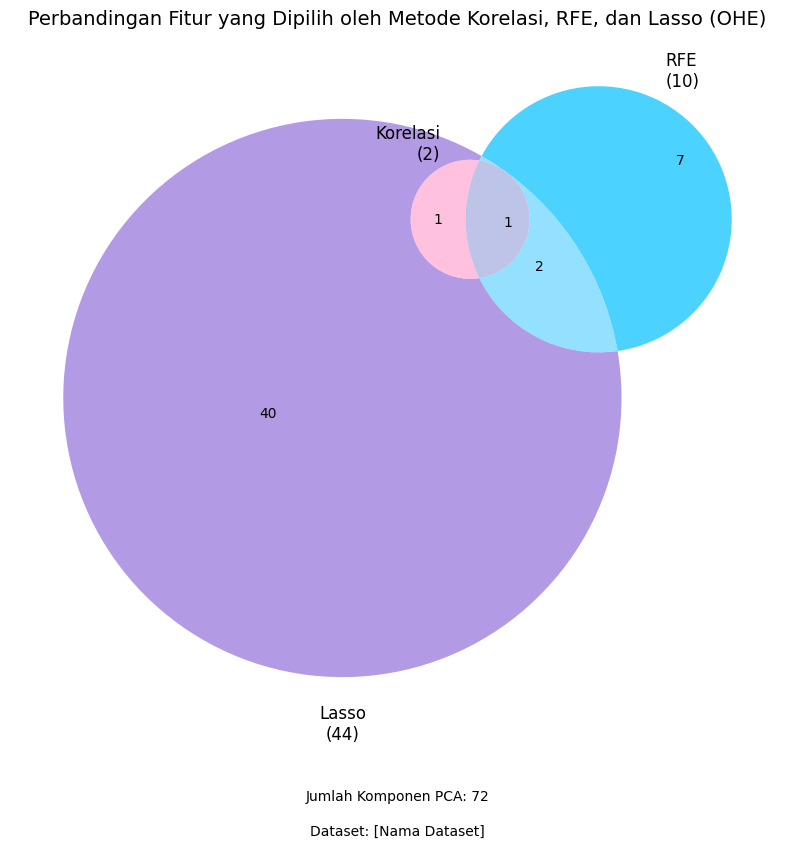

In [49]:

print(f"Fitur yang dipilih berdasarkan korelasi: {len(selected_features_corr_ohe)}")
print(f"Fitur yang dipilih dengan RFE: {len(selected_features_rfe_ohe)}")
print(f"Fitur yang dipilih dengan Lasso: {len(selected_features_lasso_ohe)}")
print(f"Jumlah komponen PCA: {X_train_pca_ohe.shape[1]}")

venn_labels = {
    '100': len(set(selected_features_corr_ohe) - set(selected_features_rfe_ohe) - set(selected_features_lasso_ohe)),
    '010': len(set(selected_features_rfe_ohe) - set(selected_features_corr_ohe) - set(selected_features_lasso_ohe)),
    '001': len(set(selected_features_lasso_ohe) - set(selected_features_corr_ohe) - set(selected_features_rfe_ohe)),
    '110': len(set(selected_features_corr_ohe) & set(selected_features_rfe_ohe) - set(selected_features_lasso_ohe)),
    '101': len(set(selected_features_corr_ohe) & set(selected_features_lasso_ohe) - set(selected_features_rfe_ohe)),
    '011': len(set(selected_features_rfe_ohe) & set(selected_features_lasso_ohe) - set(selected_features_corr_ohe)),
    '111': len(set(selected_features_corr_ohe) & set(selected_features_rfe_ohe) & set(selected_features_lasso_ohe))
}

plt.figure(figsize=(10, 10))
v = venn3(subsets=venn_labels, set_labels=('Korelasi', 'RFE', 'Lasso'), alpha=0.7,
          set_colors=('coral', 'deepskyblue', 'mediumpurple'))

if v.set_labels:
    v.set_labels[0].set_text(f"Korelasi\n({len(selected_features_corr_ohe)})")
    v.set_labels[1].set_text(f"RFE\n({len(selected_features_rfe_ohe)})")
    v.set_labels[2].set_text(f"Lasso\n({len(selected_features_lasso_ohe)})")

plt.title('Perbandingan Fitur yang Dipilih oleh Metode Korelasi, RFE, dan Lasso (OHE)', fontsize=14)
plt.annotate(f"Jumlah Komponen PCA: {X_train_pca_ohe.shape[1]}", xy=(0.5, -0.1), xycoords='axes fraction', ha='center', fontsize=10)
plt.annotate("Dataset: [Nama Dataset]", xy=(0.5, -0.15), xycoords='axes fraction', ha='center', fontsize=10)
plt.show()

In [50]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_weighted').mean()
    return f1, cv_scores

rf_model_all_ohe = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_f1_all_ohe, rf_cv_all_ohe = evaluate_model(rf_model_all_ohe, X_train_ohe, X_test_ohe, y_train_mix, y_test_mix)

xgb_model_all_ohe = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_f1_all_ohe, xgb_cv_all_ohe = evaluate_model(xgb_model_all_ohe, X_train_ohe, X_test_ohe, y_train_mix, y_test_mix)

lr_model_all_ohe = LogisticRegression(max_iter=1000, random_state=42)
lr_f1_all_ohe, lr_cv_all_ohe = evaluate_model(lr_model_all_ohe, X_train_ohe, X_test_ohe, y_train_mix, y_test_mix)

knn_model_all_ohe = KNeighborsClassifier(n_neighbors=5)
knn_f1_all_ohe, knn_cv_all_ohe = evaluate_model(knn_model_all_ohe, X_train_ohe, X_test_ohe, y_train_mix, y_test_mix)

et_model_all_ohe = ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced')
et_f1_all_ohe, et_cv_all_ohe = evaluate_model(et_model_all_ohe, X_train_ohe, X_test_ohe, y_train_mix, y_test_mix)

rf_rfe_ohe = RandomForestClassifier(n_estimators=100, random_state=42)
rfe_ohe = RFE(rf_rfe_ohe, n_features_to_select=10)
rfe_ohe.fit(X_train_ohe, y_train_mix)
selected_features_rfe_ohe = X_train_ohe.columns[rfe_ohe.support_].tolist()
X_train_rfe_ohe = X_train_ohe[selected_features_rfe_ohe]
X_test_rfe_ohe = X_test_ohe[selected_features_rfe_ohe]

rf_f1_rfe_ohe, rf_cv_rfe_ohe = evaluate_model(rf_rfe_ohe, X_train_rfe_ohe, X_test_rfe_ohe, y_train_mix, y_test_mix)
xgb_f1_rfe_ohe, xgb_cv_rfe_ohe = evaluate_model(xgb_model_all_ohe, X_train_rfe_ohe, X_test_rfe_ohe, y_train_mix, y_test_mix)
lr_f1_rfe_ohe, lr_cv_rfe_ohe = evaluate_model(lr_model_all_ohe, X_train_rfe_ohe, X_test_rfe_ohe, y_train_mix, y_test_mix)
knn_f1_rfe_ohe, knn_cv_rfe_ohe = evaluate_model(knn_model_all_ohe, X_train_rfe_ohe, X_test_rfe_ohe, y_train_mix, y_test_mix)
et_f1_rfe_ohe, et_cv_rfe_ohe = evaluate_model(et_model_all_ohe, X_train_rfe_ohe, X_test_rfe_ohe, y_train_mix, y_test_mix)

lasso_ohe = LassoCV(cv=5, random_state=42).fit(X_train_ohe, y_train_mix)
model_lasso_ohe = SelectFromModel(lasso_ohe, prefit=True)
selected_features_lasso_ohe = X_train_ohe.columns[model_lasso_ohe.get_support()].tolist()
X_train_lasso_ohe = X_train_ohe[selected_features_lasso_ohe]
X_test_lasso_ohe = X_test_ohe[selected_features_lasso_ohe]

rf_f1_lasso_ohe, rf_cv_lasso_ohe = evaluate_model(rf_model_all_ohe, X_train_lasso_ohe, X_test_lasso_ohe, y_train_mix, y_test_mix)
xgb_f1_lasso_ohe, xgb_cv_lasso_ohe = evaluate_model(xgb_model_all_ohe, X_train_lasso_ohe, X_test_lasso_ohe, y_train_mix, y_test_mix)
lr_f1_lasso_ohe, lr_cv_lasso_ohe = evaluate_model(lr_model_all_ohe, X_train_lasso_ohe, X_test_lasso_ohe, y_train_mix, y_test_mix)
knn_f1_lasso_ohe, knn_cv_lasso_ohe = evaluate_model(knn_model_all_ohe, X_train_lasso_ohe, X_test_lasso_ohe, y_train_mix, y_test_mix)
et_f1_lasso_ohe, et_cv_lasso_ohe = evaluate_model(et_model_all_ohe, X_train_lasso_ohe, X_test_lasso_ohe, y_train_mix, y_test_mix)

pca_ohe = PCA(n_components=0.95, random_state=42)
X_train_pca_ohe = pca_ohe.fit_transform(X_train_ohe)
X_test_pca_ohe = pca_ohe.transform(X_test_ohe)


rf_f1_pca_ohe, rf_cv_pca_ohe = evaluate_model(rf_model_all_ohe, X_train_pca_ohe, X_test_pca_ohe, y_train_mix, y_test_mix)
xgb_f1_pca_ohe, xgb_cv_pca_ohe = evaluate_model(xgb_model_all_ohe, X_train_pca_ohe, X_test_pca_ohe, y_train_mix, y_test_mix)
lr_f1_pca_ohe, lr_cv_pca_ohe = evaluate_model(lr_model_all_ohe, X_train_pca_ohe, X_test_pca_ohe, y_train_mix, y_test_mix)
knn_f1_pca_ohe, knn_cv_pca_ohe = evaluate_model(knn_model_all_ohe, X_train_pca_ohe, X_test_pca_ohe, y_train_mix, y_test_mix)
et_f1_pca_ohe, et_cv_pca_ohe = evaluate_model(et_model_all_ohe, X_train_pca_ohe, X_test_pca_ohe, y_train_mix, y_test_mix)

print("\nHasil Evaluasi Model dengan Semua Fitur (OHE):")
print("------------------------------------------------")
print(f"Random Forest - F1 Score: {rf_f1_all_ohe:.4f}, Cross-Validation F1 Score: {rf_cv_all_ohe:.4f}")
print(f"XGBoost - F1 Score: {xgb_f1_all_ohe:.4f}, Cross-Validation F1 Score: {xgb_cv_all_ohe:.4f}")
print(f"Logistic Regression - F1 Score: {lr_f1_all_ohe:.4f}, Cross-Validation F1 Score: {lr_cv_all_ohe:.4f}")
print(f"KNN - F1 Score: {knn_f1_all_ohe:.4f}, Cross-Validation F1 Score: {knn_cv_all_ohe:.4f}")
print(f"Extra Trees - F1 Score: {et_f1_all_ohe:.4f}, Cross-Validation F1 Score: {et_cv_all_ohe:.4f}")
print("------------------------------------------------\n")

print("\nHasil Evaluasi Model dengan RFE (OHE):")
print("------------------------------------------------")
print(f"Random Forest - F1 Score: {rf_f1_rfe_ohe:.4f}, Cross-Validation F1 Score: {rf_cv_rfe_ohe:.4f}")
print(f"XGBoost - F1 Score: {xgb_f1_rfe_ohe:.4f}, Cross-Validation F1 Score: {xgb_cv_rfe_ohe:.4f}")
print(f"Logistic Regression - F1 Score: {lr_f1_rfe_ohe:.4f}, Cross-Validation F1 Score: {lr_cv_rfe_ohe:.4f}")
print(f"KNN - F1 Score: {knn_f1_rfe_ohe:.4f}, Cross-Validation F1 Score: {knn_cv_rfe_ohe:.4f}")
print(f"Extra Trees - F1 Score: {et_f1_rfe_ohe:.4f}, Cross-Validation F1 Score: {et_cv_rfe_ohe:.4f}")
print("------------------------------------------------\n")
print("\nHasil Evaluasi Model dengan Lasso (OHE):")
print("------------------------------------------------")
print(f"Random Forest - F1 Score: {rf_f1_lasso_ohe:.4f}, Cross-Validation F1 Score: {rf_cv_lasso_ohe:.4f}")
print(f"XGBoost - F1 Score: {xgb_f1_lasso_ohe:.4f}, Cross-Validation F1 Score: {xgb_cv_lasso_ohe:.4f}")
print(f"Logistic Regression - F1 Score: {lr_f1_lasso_ohe:.4f}, Cross-Validation F1 Score: {lr_cv_lasso_ohe:.4f}")
print(f"KNN - F1 Score: {knn_f1_lasso_ohe:.4f}, Cross-Validation F1 Score: {knn_cv_lasso_ohe:.4f}")
print(f"Extra Trees - F1 Score: {et_f1_lasso_ohe:.4f}, Cross-Validation F1 Score: {et_cv_lasso_ohe:.4f}")
print("------------------------------------------------\n")

print("\nHasil Evaluasi Model dengan PCA (OHE):")
print("------------------------------------------------")
print(f"Random Forest - F1 Score: {rf_f1_pca_ohe:.4f}, Cross-Validation F1 Score: {rf_cv_pca_ohe:.4f}")
print(f"XGBoost - F1 Score: {xgb_f1_pca_ohe:.4f}, Cross-Validation F1 Score: {xgb_cv_pca_ohe:.4f}")
print(f"Logistic Regression - F1 Score: {lr_f1_pca_ohe:.4f}, Cross-Validation F1 Score: {lr_cv_pca_ohe:.4f}")
print(f"KNN - F1 Score: {knn_f1_pca_ohe:.4f}, Cross-Validation F1 Score: {knn_cv_pca_ohe:.4f}")
print(f"Extra Trees - F1 Score: {et_f1_pca_ohe:.4f}, Cross-Validation F1 Score: {et_cv_pca_ohe:.4f}")
print("------------------------------------------------\n")



Hasil Evaluasi Model dengan Semua Fitur (OHE):
------------------------------------------------
Random Forest - F1 Score: 0.7763, Cross-Validation F1 Score: 0.7784
XGBoost - F1 Score: 0.8136, Cross-Validation F1 Score: 0.8037
Logistic Regression - F1 Score: 0.7776, Cross-Validation F1 Score: 0.7768
KNN - F1 Score: 0.7876, Cross-Validation F1 Score: 0.7884
Extra Trees - F1 Score: 0.7783, Cross-Validation F1 Score: 0.7787
------------------------------------------------


Hasil Evaluasi Model dengan RFE (OHE):
------------------------------------------------
Random Forest - F1 Score: 0.7786, Cross-Validation F1 Score: 0.7855
XGBoost - F1 Score: 0.7857, Cross-Validation F1 Score: 0.7910
Logistic Regression - F1 Score: 0.7753, Cross-Validation F1 Score: 0.7752
KNN - F1 Score: 0.7796, Cross-Validation F1 Score: 0.7866
Extra Trees - F1 Score: 0.6296, Cross-Validation F1 Score: 0.6418
------------------------------------------------


Hasil Evaluasi Model dengan Lasso (OHE):
----------------

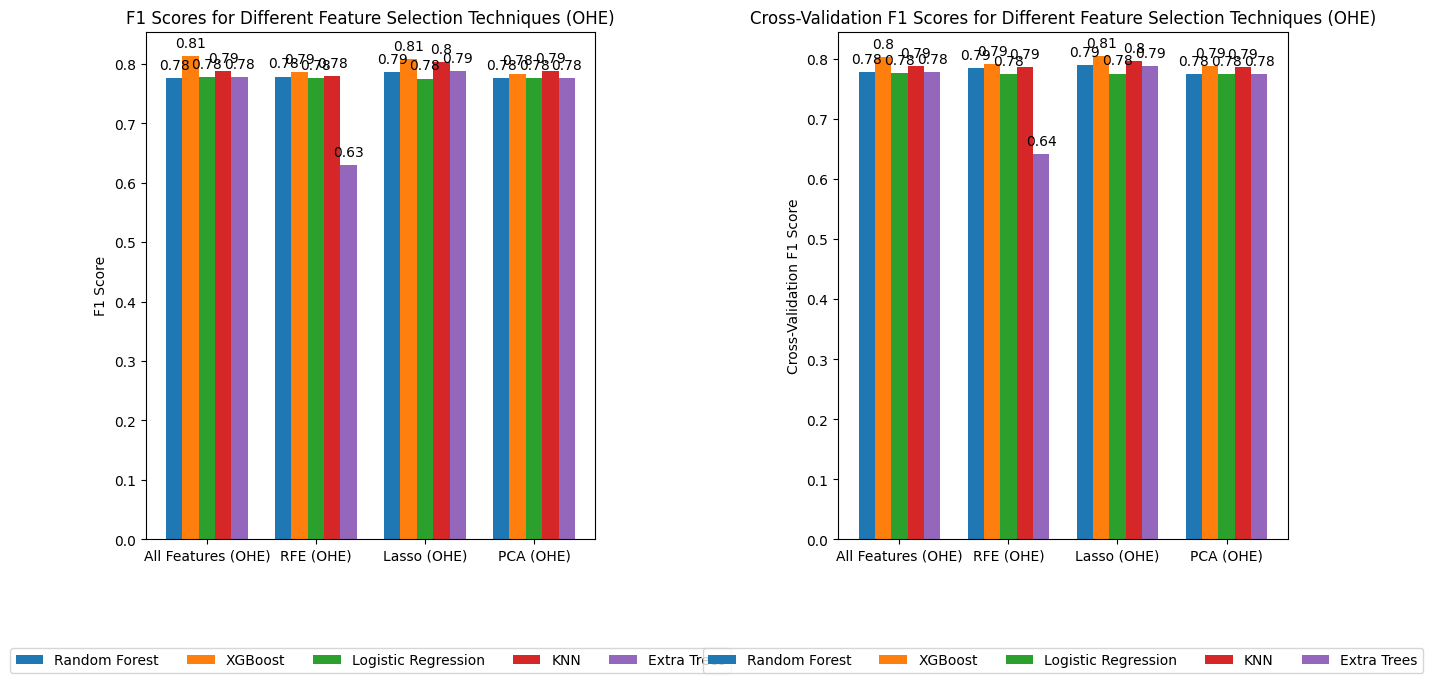

In [51]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Random Forest', 'XGBoost', 'Logistic Regression', 'KNN', 'Extra Trees']
features = ['All Features (OHE)', 'RFE (OHE)', 'Lasso (OHE)', 'PCA (OHE)']

# F1 Scores (OHE)
f1_scores_ohe = {
    'Random Forest': [rf_f1_all_ohe, rf_f1_rfe_ohe, rf_f1_lasso_ohe, rf_f1_pca_ohe],
    'XGBoost': [xgb_f1_all_ohe, xgb_f1_rfe_ohe, xgb_f1_lasso_ohe, xgb_f1_pca_ohe],
    'Logistic Regression': [lr_f1_all_ohe, lr_f1_rfe_ohe, lr_f1_lasso_ohe, lr_f1_pca_ohe],
    'KNN': [knn_f1_all_ohe, knn_f1_rfe_ohe, knn_f1_lasso_ohe, knn_f1_pca_ohe],
    'Extra Trees': [et_f1_all_ohe, et_f1_rfe_ohe, et_f1_lasso_ohe, et_f1_pca_ohe],
}

cv_scores_ohe = {
    'Random Forest': [rf_cv_all_ohe, rf_cv_rfe_ohe, rf_cv_lasso_ohe, rf_cv_pca_ohe],
    'XGBoost': [xgb_cv_all_ohe, xgb_cv_rfe_ohe, xgb_cv_lasso_ohe, xgb_cv_pca_ohe],
    'Logistic Regression': [lr_cv_all_ohe, lr_cv_rfe_ohe, lr_cv_lasso_ohe, lr_cv_pca_ohe],
    'KNN': [knn_cv_all_ohe, knn_cv_rfe_ohe, knn_cv_lasso_ohe, knn_cv_pca_ohe],
    'Extra Trees': [et_cv_all_ohe, et_cv_rfe_ohe, et_cv_lasso_ohe, et_cv_pca_ohe],
}


x = np.arange(len(features))

fig, ax = plt.subplots(1, 2, figsize=(14, 7))

bar_width = 0.15

for idx, model in enumerate(models):
    bars = ax[0].bar(x + idx * bar_width, f1_scores_ohe[model], width=bar_width, label=model)

    for bar in bars:
        yval = bar.get_height()
        ax[0].text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom', fontsize=10)

for idx, model in enumerate(models):
    bars = ax[1].bar(x + idx * bar_width, cv_scores_ohe[model], width=bar_width, label=model)

    for bar in bars:
        yval = bar.get_height()
        ax[1].text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom', fontsize=10)

ax[0].set_xticks(x + 0.3)
ax[0].set_xticklabels(features)
ax[0].set_title('F1 Scores for Different Feature Selection Techniques (OHE)')
ax[0].set_ylabel('F1 Score')

ax[1].set_xticks(x + 0.3)
ax[1].set_xticklabels(features)
ax[1].set_title('Cross-Validation F1 Scores for Different Feature Selection Techniques (OHE)')
ax[1].set_ylabel('Cross-Validation F1 Score')

ax[0].legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5)
ax[1].legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5)

plt.tight_layout()
plt.show()


In [52]:
target_column = 'Accident_severity'
corr_matrix = df_kfold.corr()
target_corr = corr_matrix[target_column].abs().sort_values(ascending=False)
selected_features_corr_kfold = target_corr[target_corr > 0.05].index.tolist()
selected_features_corr_kfold.remove(target_column)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(rf, n_features_to_select=10)
rfe.fit(X_train_kfold, y_train_kfold)
selected_features_rfe_kfold = X_train_kfold.columns[rfe.support_].tolist()

lasso = LassoCV(cv=5, random_state=42).fit(X_train_kfold, y_train_kfold)
model = SelectFromModel(lasso, prefit=True)
selected_features_lasso_kfold = X_train_kfold.columns[model.get_support()].tolist()

pca = PCA(n_components=0.95, random_state=42)
X_train_pca_kfold = pca.fit_transform(X_train_kfold)
X_test_pca_kfold = pca.transform(X_test_kfold)

len(selected_features_corr_kfold), len(selected_features_rfe_kfold), len(selected_features_lasso_kfold), X_train_pca_kfold.shape[1]



(4, 10, 19, 2)

Fitur yang dipilih berdasarkan korelasi: 4
Fitur yang dipilih dengan RFE: 10
Fitur yang dipilih dengan Lasso: 19
Jumlah komponen PCA: 2


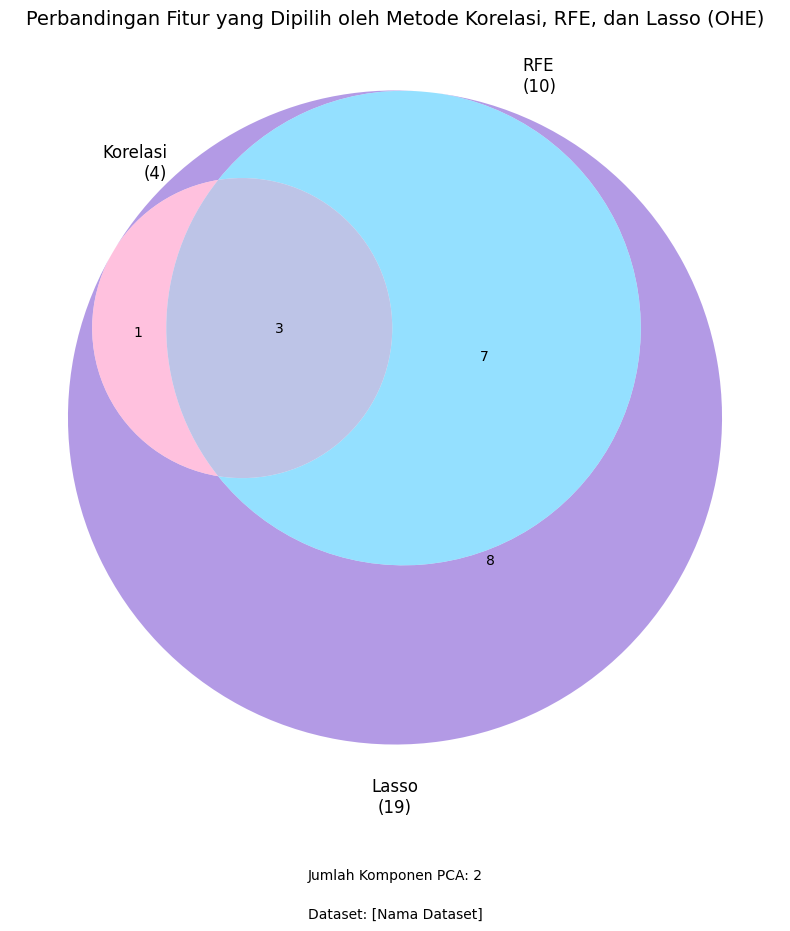

In [53]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

print(f"Fitur yang dipilih berdasarkan korelasi: {len(selected_features_corr_kfold)}")
print(f"Fitur yang dipilih dengan RFE: {len(selected_features_rfe_kfold)}")
print(f"Fitur yang dipilih dengan Lasso: {len(selected_features_lasso_kfold)}")
print(f"Jumlah komponen PCA: {X_train_pca_kfold.shape[1]}")

venn_labels = {
    '100': len(set(selected_features_corr_kfold) - set(selected_features_rfe_kfold) - set(selected_features_lasso_kfold)),
    '010': len(set(selected_features_rfe_kfold) - set(selected_features_corr_kfold) - set(selected_features_lasso_kfold)),
    '001': len(set(selected_features_lasso_kfold) - set(selected_features_corr_kfold) - set(selected_features_rfe_kfold)),
    '110': len(set(selected_features_corr_kfold) & set(selected_features_rfe_kfold) - set(selected_features_lasso_kfold)),
    '101': len(set(selected_features_corr_kfold) & set(selected_features_lasso_kfold) - set(selected_features_rfe_kfold)),
    '011': len(set(selected_features_rfe_kfold) & set(selected_features_lasso_kfold) - set(selected_features_corr_kfold)),
    '111': len(set(selected_features_corr_kfold) & set(selected_features_rfe_kfold) & set(selected_features_lasso_kfold))
}

plt.figure(figsize=(10, 10))
v = venn3(subsets=venn_labels, set_labels=('Korelasi', 'RFE', 'Lasso'), alpha=0.7,
          set_colors=('coral', 'deepskyblue', 'mediumpurple'))

if v.set_labels:
    v.set_labels[0].set_text(f"Korelasi\n({len(selected_features_corr_kfold)})")
    v.set_labels[1].set_text(f"RFE\n({len(selected_features_rfe_kfold)})")
    v.set_labels[2].set_text(f"Lasso\n({len(selected_features_lasso_kfold)})")

plt.title('Perbandingan Fitur yang Dipilih oleh Metode Korelasi, RFE, dan Lasso (OHE)', fontsize=14)
plt.annotate(f"Jumlah Komponen PCA: {X_train_pca_kfold.shape[1]}", xy=(0.5, -0.1), xycoords='axes fraction', ha='center', fontsize=10)
plt.annotate("Dataset: [Nama Dataset]", xy=(0.5, -0.15), xycoords='axes fraction', ha='center', fontsize=10)
plt.show()

In [54]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

def evaluate_model_kfold(model, X_train, y_train, X_test, y_test, cv=5):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred, average='weighted')

    cv_scores = cross_val_score(model, X_train_kfold, y_train, cv=cv, scoring='f1_weighted')
    return f1, np.mean(cv_scores)

rf_model_all_kfold = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_f1_all_kfold, rf_cv_all_kfold = evaluate_model_kfold(rf_model_all_kfold, X_train_kfold, y_train_kfold, X_test_kfold, y_test_kfold)

xgb_model_all_kfold = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_f1_all_kfold, xgb_cv_all_kfold = evaluate_model_kfold(xgb_model_all_kfold, X_train_kfold, y_train_kfold, X_test_kfold, y_test_kfold)

lr_model_all_kfold = LogisticRegression(max_iter=1000, random_state=42)
lr_f1_all_kfold, lr_cv_all_kfold = evaluate_model_kfold(lr_model_all_kfold, X_train_kfold, y_train_kfold, X_test_kfold, y_test_kfold)

knn_model_all_kfold = KNeighborsClassifier(n_neighbors=5)
knn_f1_all_kfold, knn_cv_all_kfold = evaluate_model_kfold(knn_model_all_kfold, X_train_kfold, y_train_kfold, X_test_kfold, y_test_kfold)

et_model_all_kfold = ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced')
et_f1_all_kfold, et_cv_all_kfold = evaluate_model_kfold(et_model_all_kfold, X_train_kfold, y_train_kfold, X_test_kfold, y_test_kfold)

rf_rfe_kfold = RandomForestClassifier(n_estimators=100, random_state=42)
rfe_kfold = RFE(rf_rfe_kfold, n_features_to_select=10)
rfe_kfold.fit(X_train_kfold, y_train_kfold)
selected_features_rfe_kfold = X_train_kfold.columns[rfe_kfold.support_].tolist()
X_train_rfe_kfold = X_train_kfold[selected_features_rfe_kfold]
X_test_rfe_kfold = X_test_kfold[selected_features_rfe_kfold]

rf_f1_rfe_kfold, rf_cv_rfe_kfold = evaluate_model_kfold(rf_rfe_kfold, X_train_rfe_kfold, y_train_kfold, X_test_rfe_kfold, y_test_kfold)
xgb_f1_rfe_kfold, xgb_cv_rfe_kfold = evaluate_model_kfold(xgb_model_all_kfold, X_train_rfe_kfold, y_train_kfold, X_test_rfe_kfold, y_test_kfold)
lr_f1_rfe_kfold, lr_cv_rfe_kfold = evaluate_model_kfold(lr_model_all_kfold, X_train_rfe_kfold, y_train_kfold, X_test_rfe_kfold, y_test_kfold)
knn_f1_rfe_kfold, knn_cv_rfe_kfold = evaluate_model_kfold(knn_model_all_kfold, X_train_rfe_kfold, y_train_kfold, X_test_rfe_kfold, y_test_kfold)
et_f1_rfe_kfold, et_cv_rfe_kfold = evaluate_model_kfold(et_model_all_kfold, X_train_rfe_kfold, y_train_kfold, X_test_rfe_kfold, y_test_kfold)

lasso_kfold = LassoCV(cv=5, random_state=42).fit(X_train_kfold, y_train_kfold)
model_lasso_kfold = SelectFromModel(lasso_kfold, prefit=True)
selected_features_lasso_kfold = X_train_kfold.columns[model_lasso_kfold.get_support()].tolist()
X_train_lasso_kfold = X_train_kfold[selected_features_lasso_kfold]
X_test_lasso_kfold = X_test_kfold[selected_features_lasso_kfold]

rf_f1_lasso_kfold, rf_cv_lasso_kfold = evaluate_model_kfold(rf_model_all_kfold, X_train_lasso_kfold, y_train_kfold, X_test_lasso_kfold, y_test_kfold)
xgb_f1_lasso_kfold, xgb_cv_lasso_kfold = evaluate_model_kfold(xgb_model_all_kfold, X_train_lasso_kfold, y_train_kfold, X_test_lasso_kfold, y_test_kfold)
lr_f1_lasso_kfold, lr_cv_lasso_kfold = evaluate_model_kfold(lr_model_all_kfold, X_train_lasso_kfold, y_train_kfold, X_test_lasso_kfold, y_test_kfold)
knn_f1_lasso_kfold, knn_cv_lasso_kfold = evaluate_model_kfold(knn_model_all_kfold, X_train_lasso_kfold, y_train_kfold, X_test_lasso_kfold, y_test_kfold)
et_f1_lasso_kfold, et_cv_lasso_kfold = evaluate_model_kfold(et_model_all_kfold, X_train_lasso_kfold, y_train_kfold, X_test_lasso_kfold, y_test_kfold)

pca_kfold = PCA(n_components=0.95, random_state=42)
X_train_pca_kfold = pca_kfold.fit_transform(X_train_kfold)
X_test_pca_kfold = pca_kfold.transform(X_test_kfold)

rf_f1_pca_kfold, rf_cv_pca_kfold = evaluate_model_kfold(rf_model_all_kfold, X_train_pca_kfold, y_train_kfold, X_test_pca_kfold, y_test_kfold)
xgb_f1_pca_kfold, xgb_cv_pca_kfold = evaluate_model_kfold(xgb_model_all_kfold, X_train_pca_kfold, y_train_kfold, X_test_pca_kfold, y_test_kfold)
lr_f1_pca_kfold, lr_cv_pca_kfold = evaluate_model_kfold(lr_model_all_kfold, X_train_pca_kfold, y_train_kfold, X_test_pca_kfold, y_test_kfold)
knn_f1_pca_kfold, knn_cv_pca_kfold = evaluate_model_kfold(knn_model_all_kfold, X_train_pca_kfold, y_train_kfold, X_test_pca_kfold, y_test_kfold)
et_f1_pca_kfold, et_cv_pca_kfold = evaluate_model_kfold(et_model_all_kfold, X_train_pca_kfold, y_train_kfold, X_test_pca_kfold, y_test_kfold)

print("\nHasil Evaluasi Model dengan Semua Fitur (K-Fold):")
print("------------------------------------------------")
print(f"Random Forest - F1 Score: {rf_f1_all_kfold:.4f}, Cross-Validation F1 Score: {rf_cv_all_kfold:.4f}")
print(f"XGBoost - F1 Score: {xgb_f1_all_kfold:.4f}, Cross-Validation F1 Score: {xgb_cv_all_kfold:.4f}")
print(f"Logistic Regression - F1 Score: {lr_f1_all_kfold:.4f}, Cross-Validation F1 Score: {lr_cv_all_kfold:.4f}")
print(f"KNN - F1 Score: {knn_f1_all_kfold:.4f}, Cross-Validation F1 Score: {knn_cv_all_kfold:.4f}")
print(f"Extra Trees - F1 Score: {et_f1_all_kfold:.4f}, Cross-Validation F1 Score: {et_cv_all_kfold:.4f}")
print("------------------------------------------------\n")

print("\nHasil Evaluasi Model dengan RFE (K-Fold):")
print("------------------------------------------------")
print(f"Random Forest - F1 Score: {rf_f1_rfe_kfold:.4f}, Cross-Validation F1 Score: {rf_cv_rfe_kfold:.4f}")
print(f"XGBoost - F1 Score: {xgb_f1_rfe_kfold:.4f}, Cross-Validation F1 Score: {xgb_cv_rfe_kfold:.4f}")
print(f"Logistic Regression - F1 Score: {lr_f1_rfe_kfold:.4f}, Cross-Validation F1 Score: {lr_cv_rfe_kfold:.4f}")
print(f"KNN - F1 Score: {knn_f1_rfe_kfold:.4f}, Cross-Validation F1 Score: {knn_cv_rfe_kfold:.4f}")
print(f"Extra Trees - F1 Score: {et_f1_rfe_kfold:.4f}, Cross-Validation F1 Score: {et_cv_rfe_kfold:.4f}")
print("------------------------------------------------\n")

print("\nHasil Evaluasi Model dengan Lasso (K-Fold):")
print("------------------------------------------------")
print(f"Random Forest - F1 Score: {rf_f1_lasso_kfold:.4f}, Cross-Validation F1 Score: {rf_cv_lasso_kfold:.4f}")
print(f"XGBoost - F1 Score: {xgb_f1_lasso_kfold:.4f}, Cross-Validation F1 Score: {xgb_cv_lasso_kfold:.4f}")
print(f"Logistic Regression - F1 Score: {lr_f1_lasso_kfold:.4f}, Cross-Validation F1 Score: {lr_cv_lasso_kfold:.4f}")
print(f"KNN - F1 Score: {knn_f1_lasso_kfold:.4f}, Cross-Validation F1 Score: {knn_cv_lasso_kfold:.4f}")
print(f"Extra Trees - F1 Score: {et_f1_lasso_kfold:.4f}, Cross-Validation F1 Score: {et_cv_lasso_kfold:.4f}")
print("------------------------------------------------\n")

print("\nHasil Evaluasi Model dengan PCA (K-Fold):")
print("------------------------------------------------")
print(f"Random Forest - F1 Score: {rf_f1_pca_kfold:.4f}, Cross-Validation F1 Score: {rf_cv_pca_kfold:.4f}")
print(f"XGBoost - F1 Score: {xgb_f1_pca_kfold:.4f}, Cross-Validation F1 Score: {xgb_cv_pca_kfold:.4f}")
print(f"Logistic Regression - F1 Score: {lr_f1_pca_kfold:.4f}, Cross-Validation F1 Score: {lr_cv_pca_kfold:.4f}")
print(f"KNN - F1 Score: {knn_f1_pca_kfold:.4f}, Cross-Validation F1 Score: {knn_cv_pca_kfold:.4f}")
print(f"Extra Trees - F1 Score: {et_f1_pca_kfold:.4f}, Cross-Validation F1 Score: {et_cv_pca_kfold:.4f}")



Hasil Evaluasi Model dengan Semua Fitur (K-Fold):
------------------------------------------------
Random Forest - F1 Score: 0.7831, Cross-Validation F1 Score: 0.7851
XGBoost - F1 Score: 0.8146, Cross-Validation F1 Score: 0.8037
Logistic Regression - F1 Score: 0.7753, Cross-Validation F1 Score: 0.7752
KNN - F1 Score: 0.8045, Cross-Validation F1 Score: 0.8056
Extra Trees - F1 Score: 0.7992, Cross-Validation F1 Score: 0.7938
------------------------------------------------


Hasil Evaluasi Model dengan RFE (K-Fold):
------------------------------------------------
Random Forest - F1 Score: 0.7810, Cross-Validation F1 Score: 0.7908
XGBoost - F1 Score: 0.7850, Cross-Validation F1 Score: 0.8037
Logistic Regression - F1 Score: 0.7753, Cross-Validation F1 Score: 0.7752
KNN - F1 Score: 0.7727, Cross-Validation F1 Score: 0.8056
Extra Trees - F1 Score: 0.7850, Cross-Validation F1 Score: 0.7938
------------------------------------------------


Hasil Evaluasi Model dengan Lasso (K-Fold):
-------

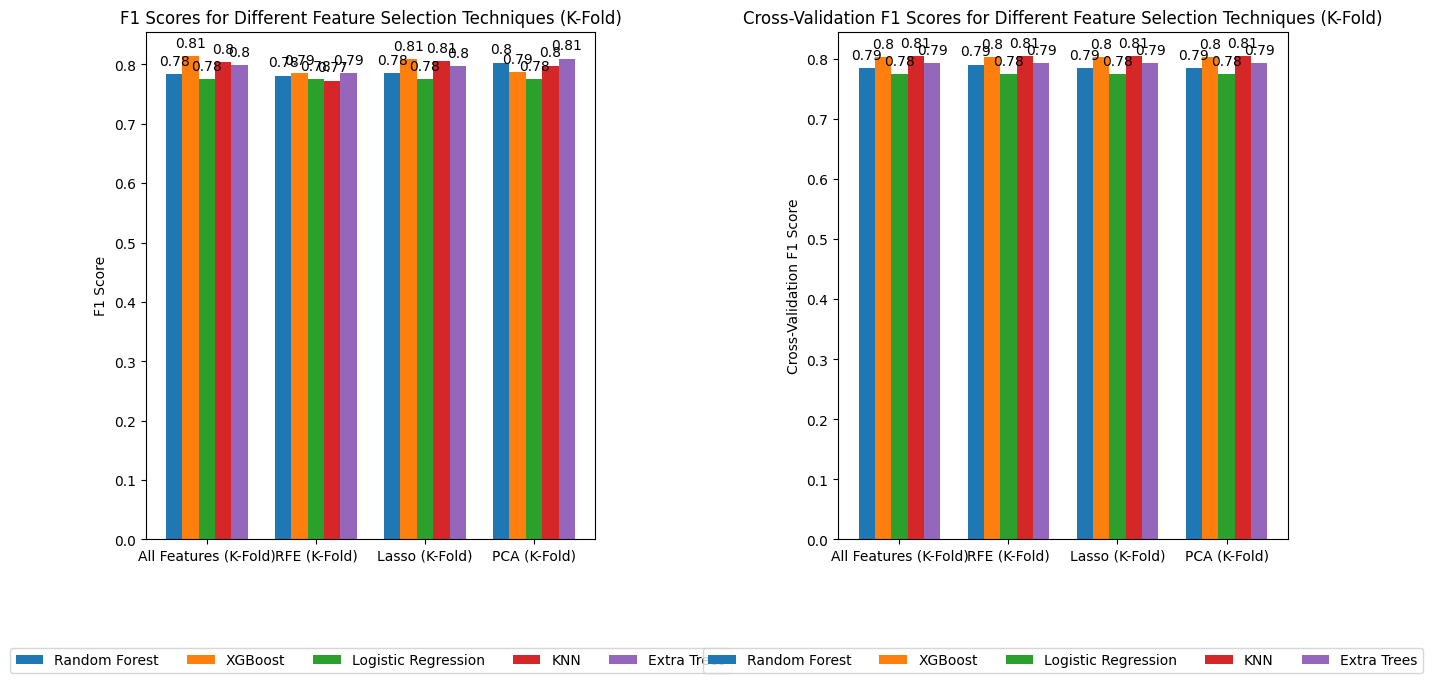

In [55]:

models = ['Random Forest', 'XGBoost', 'Logistic Regression', 'KNN', 'Extra Trees']
features = ['All Features (K-Fold)', 'RFE (K-Fold)', 'Lasso (K-Fold)', 'PCA (K-Fold)']

f1_scores_kfold = {
    'Random Forest': [rf_f1_all_kfold, rf_f1_rfe_kfold, rf_f1_lasso_kfold, rf_f1_pca_kfold],
    'XGBoost': [xgb_f1_all_kfold, xgb_f1_rfe_kfold, xgb_f1_lasso_kfold, xgb_f1_pca_kfold],
    'Logistic Regression': [lr_f1_all_kfold, lr_f1_rfe_kfold, lr_f1_lasso_kfold, lr_f1_pca_kfold],
    'KNN': [knn_f1_all_kfold, knn_f1_rfe_kfold, knn_f1_lasso_kfold, knn_f1_pca_kfold],
    'Extra Trees': [et_f1_all_kfold, et_f1_rfe_kfold, et_f1_lasso_kfold, et_f1_pca_kfold],
}
cv_scores_kfold = {
    'Random Forest': [rf_cv_all_kfold, rf_cv_rfe_kfold, rf_cv_lasso_kfold, rf_cv_pca_kfold],
    'XGBoost': [xgb_cv_all_kfold, xgb_cv_rfe_kfold, xgb_cv_lasso_kfold, xgb_cv_pca_kfold],
    'Logistic Regression': [lr_cv_all_kfold, lr_cv_rfe_kfold, lr_cv_lasso_kfold, lr_cv_pca_kfold],
    'KNN': [knn_cv_all_kfold, knn_cv_rfe_kfold, knn_cv_lasso_kfold, knn_cv_pca_kfold],
    'Extra Trees': [et_cv_all_kfold, et_cv_rfe_kfold, et_cv_lasso_kfold, et_cv_pca_kfold],
}


x = np.arange(len(features))
fig, ax = plt.subplots(1, 2, figsize=(14, 7))


bar_width = 0.15

for idx, model in enumerate(models):
    bars = ax[0].bar(x + idx * bar_width, f1_scores_kfold[model], width=bar_width, label=model)

    for bar in bars:
        yval = bar.get_height()
        ax[0].text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom', fontsize=10)

for idx, model in enumerate(models):
    bars = ax[1].bar(x + idx * bar_width, cv_scores_kfold[model], width=bar_width, label=model)

    for bar in bars:
        yval = bar.get_height()
        ax[1].text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom', fontsize=10)

ax[0].set_xticks(x + 0.3)
ax[0].set_xticklabels(features)
ax[0].set_title('F1 Scores for Different Feature Selection Techniques (K-Fold)')
ax[0].set_ylabel('F1 Score')

ax[1].set_xticks(x + 0.3)
ax[1].set_xticklabels(features)
ax[1].set_title('Cross-Validation F1 Scores for Different Feature Selection Techniques (K-Fold)')
ax[1].set_ylabel('Cross-Validation F1 Score')

ax[0].legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5)
ax[1].legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5)

plt.tight_layout()
plt.show()


# Imbalance data

In [56]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np

# DataFrame global untuk menyimpan hasil evaluasi
# evaluation_results = pd.DataFrame(columns=['model_type', 'method', 'technique', 'f1_score_weighted', 'accuracy', 'precision', 'recall'])

def resample(X_train, y_train, method='smote', random_state=42, k_neighbors=5):
    """
    Fungsi untuk melakukan resampling dataset untuk klasifikasi multi-class.

    Parameters:
    - X_train: Fitur data pelatihan
    - y_train: Label target pelatihan
    - method: Metode resampling yang digunakan ('smote', 'smote_tomek', 'weighted')
    - random_state: Random seed untuk reprodusibilitas
    - k_neighbors: Jumlah tetangga terdekat untuk SMOTE (default=5)

    Returns:
    - X_train_resampled: Fitur data pelatihan setelah resampling
    - y_train_resampled: Label target pelatihan setelah resampling
    - sample_weights: Bobot sampel (hanya jika 'weighted' dipilih)
    """
    if method == 'smote':
        print("Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.")
        class_counts = np.bincount(y_train)
        majority_class_count = max(class_counts)
        sampling_strategy = {class_label: majority_class_count // 2 if count < majority_class_count else count
                             for class_label, count in enumerate(class_counts)}

        smote = SMOTE(sampling_strategy=sampling_strategy, random_state=random_state, k_neighbors=k_neighbors)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    elif method == 'smote_tomek':
        print("Resampling menggunakan SMOTE-Tomek.")
        smote_tomek = SMOTETomek(random_state=random_state)
        X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train, y_train)

    elif method == 'weighted':
        print("Resampling dengan weighted sampling berdasarkan model.")
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
        X_train_resampled, y_train_resampled = X_train, y_train
        return X_train_resampled, y_train_resampled, sample_weights

    else:
        raise ValueError("Metode resampling tidak dikenali. Pilih antara 'smote', 'smote_tomek', atau 'weighted'.")

    return X_train_resampled, y_train_resampled, None


import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, precision_score, recall_score, balanced_accuracy_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np

# DataFrame global untuk menyimpan hasil evaluasi
evaluation_results2 = pd.DataFrame(columns=['model_type', 'method', 'technique',
                                           'f1_weighted', 'accuracy', 'precision', 'recall',
                                           'f1_micro', 'f1_macro', 'balanced_accuracy', 'roc_auc'])

def train_and_evaluate_model(X_train, y_train, X_test, y_test, model_type='xgboost', method='smote', technique='all features', random_state=42, k_neighbors=5):
    """
    Fungsi untuk melatih dan mengevaluasi model dengan tambahan metrik evaluasi.
    """

    # Lakukan resampling
    X_train_resampled, y_train_resampled, sample_weights = resample(X_train, y_train, method=method, random_state=random_state, k_neighbors=k_neighbors)

    # Pilih model berdasarkan parameter model_type
    if model_type == 'xgboost':
        model = xgb.XGBClassifier(random_state=random_state, n_jobs=-1)
    elif model_type == 'randomforest':
        model = RandomForestClassifier(random_state=random_state, n_jobs=-1)
    elif model_type == 'extratrees':
        model = ExtraTreesClassifier(random_state=random_state, n_jobs=-1)
    elif model_type == 'knn':
        model = KNeighborsClassifier(n_jobs=-1)
    elif model_type == 'logreg':
        model = LogisticRegression(random_state=random_state, n_jobs=-1)
    else:
        raise ValueError("Model tidak dikenali. Pilih antara 'xgboost', 'randomforest', 'extratrees', 'knn', atau 'logreg'.")

    # Latih model
    if model_type in ['knn']:
        model.fit(X_train_resampled, y_train_resampled)  # KNN tidak mendukung sample_weight
    else:
        model.fit(X_train_resampled, y_train_resampled, sample_weight=sample_weights)

    # Prediksi dan evaluasi model pada data uji
    y_pred = model.predict(X_test)

    # Metrik evaluasi
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1_micro = f1_score(y_test, y_pred, average='micro')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # ROC-AUC Per Kelas (hanya jika model mendukung probabilitas)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr")
    else:
        roc_auc = np.nan  # Tidak dapat dihitung jika model tidak mendukung predict_proba

    # Menambahkan hasil evaluasi ke dalam DataFrame global
    evaluation_results2.loc[len(evaluation_results2)] = [model_type, method, technique,
                                                        f1_weighted, accuracy, precision, recall,
                                                        f1_micro, f1_macro, balanced_acc, roc_auc]

    # Menampilkan hasil evaluasi
    print(f"Model: {model_type}, Metode Resampling: {method}")
    print(f"F1-Score (Weighted): {f1_weighted:.4f}")
    print(f"F1-Score (Micro): {f1_micro:.4f}")
    print(f"F1-Score (Macro): {f1_macro:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"ROC-AUC (One-vs-Rest): {roc_auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return model, f1_weighted, accuracy, precision, recall, f1_micro, f1_macro, balanced_acc, roc_auc


ohe

In [57]:
def run_all_models_with_resampling(X_train_ohe, y_train, X_test, y_test, technique):
    models = ['xgboost', 'randomforest', 'extratrees', 'knn', 'logreg']
    methods = ['smote', 'smote_tomek', 'weighted']

    for model_type in models:
        for method in methods:
            print(f"\nTraining {model_type} dengan teknik resampling {method}...")
            model, f1_weighted, accuracy, precision, recall, f1_micro, f1_macro, balanced_acc, roc_auc  = train_and_evaluate_model(
                X_train_ohe, y_train, X_test, y_test, model_type=model_type, method=method, technique=technique
            )

    # Menampilkan DataFrame hasil evaluasi
    print("\nDataFrame Hasil Evaluasi Model:")
    print(evaluation_results2)

run_all_models_with_resampling(X_train_ohe, y_train_ohe, X_test_ohe, y_test_ohe, 'All features (OHE)')



Training xgboost dengan teknik resampling smote...
Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
Model: xgboost, Metode Resampling: smote
F1-Score (Weighted): 0.8059
F1-Score (Micro): 0.8512
F1-Score (Macro): 0.4097
Balanced Accuracy: 0.3887
ROC-AUC (One-vs-Rest): 0.7392
Accuracy: 0.8512
Precision: 0.8182
Recall: 0.8512
Confusion Matrix:
[[   2    0   30]
 [   0   41  306]
 [   1   29 2051]]

Training xgboost dengan teknik resampling smote_tomek...
Resampling menggunakan SMOTE-Tomek.
Model: xgboost, Metode Resampling: smote_tomek
F1-Score (Weighted): 0.8099
F1-Score (Micro): 0.8541
F1-Score (Macro): 0.4324
Balanced Accuracy: 0.4025
ROC-AUC (One-vs-Rest): 0.7609
Accuracy: 0.8541
Precision: 0.8266
Recall: 0.8541
Confusion Matrix:
[[   3    0   29]
 [   0   44  303]
 [   1   26 2054]]

Training xgboost dengan teknik resampling weighted...
Resampling dengan weighted sampling berdasarkan model.
Model: xgboost, Metode Resampling: weighted
F1-Score (Weighted): 0.7677
F

In [58]:
run_all_models_with_resampling(X_train_pca_ohe, y_train_ohe, X_test_pca_ohe, y_test_ohe, 'PCA (OHE)')


Training xgboost dengan teknik resampling smote...
Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
Model: xgboost, Metode Resampling: smote
F1-Score (Weighted): 0.7940
F1-Score (Micro): 0.8329
F1-Score (Macro): 0.4343
Balanced Accuracy: 0.4091
ROC-AUC (One-vs-Rest): 0.6884
Accuracy: 0.8329
Precision: 0.7793
Recall: 0.8329
Confusion Matrix:
[[   5    4   23]
 [   0   37  310]
 [   6   68 2007]]

Training xgboost dengan teknik resampling smote_tomek...
Resampling menggunakan SMOTE-Tomek.
Model: xgboost, Metode Resampling: smote_tomek
F1-Score (Weighted): 0.7887
F1-Score (Micro): 0.8110
F1-Score (Macro): 0.4231
Balanced Accuracy: 0.3992
ROC-AUC (One-vs-Rest): 0.6912
Accuracy: 0.8110
Precision: 0.7758
Recall: 0.8110
Confusion Matrix:
[[   3    5   24]
 [   0   61  286]
 [   3  147 1931]]

Training xgboost dengan teknik resampling weighted...
Resampling dengan weighted sampling berdasarkan model.
Model: xgboost, Metode Resampling: weighted
F1-Score (Weighted): 0.7966
F

In [59]:
run_all_models_with_resampling(X_train_lasso_ohe, y_train_ohe, X_test_lasso_ohe, y_test_ohe, 'LASSO (OHE)')


Training xgboost dengan teknik resampling smote...
Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
Model: xgboost, Metode Resampling: smote
F1-Score (Weighted): 0.8087
F1-Score (Micro): 0.8516
F1-Score (Macro): 0.4170
Balanced Accuracy: 0.3929
ROC-AUC (One-vs-Rest): 0.7155
Accuracy: 0.8516
Precision: 0.8216
Recall: 0.8516
Confusion Matrix:
[[   2    1   29]
 [   0   46  301]
 [   0   34 2047]]

Training xgboost dengan teknik resampling smote_tomek...
Resampling menggunakan SMOTE-Tomek.
Model: xgboost, Metode Resampling: smote_tomek
F1-Score (Weighted): 0.8007
F1-Score (Micro): 0.8439
F1-Score (Macro): 0.4051
Balanced Accuracy: 0.3851
ROC-AUC (One-vs-Rest): 0.7053
Accuracy: 0.8439
Precision: 0.8027
Recall: 0.8439
Confusion Matrix:
[[   2    2   28]
 [   0   40  307]
 [   0   47 2034]]

Training xgboost dengan teknik resampling weighted...
Resampling dengan weighted sampling berdasarkan model.
Model: xgboost, Metode Resampling: weighted
F1-Score (Weighted): 0.7471
F

kfold

In [60]:
run_all_models_with_resampling(X_train_kfold, y_train_kfold, X_test_kfold, y_test_kfold, 'All features (KFOLD)')


Training xgboost dengan teknik resampling smote...
Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
Model: xgboost, Metode Resampling: smote
F1-Score (Weighted): 0.8050
F1-Score (Micro): 0.8512
F1-Score (Macro): 0.4501
Balanced Accuracy: 0.4155
ROC-AUC (One-vs-Rest): 0.7470
Accuracy: 0.8512
Precision: 0.8166
Recall: 0.8512
Confusion Matrix:
[[   5    0   27]
 [   1   36  310]
 [   1   27 2053]]

Training xgboost dengan teknik resampling smote_tomek...
Resampling menggunakan SMOTE-Tomek.
Model: xgboost, Metode Resampling: smote_tomek
F1-Score (Weighted): 0.8034
F1-Score (Micro): 0.8496
F1-Score (Macro): 0.4341
Balanced Accuracy: 0.4046
ROC-AUC (One-vs-Rest): 0.7389
Accuracy: 0.8496
Precision: 0.8118
Recall: 0.8496
Confusion Matrix:
[[   4    1   27]
 [   0   36  311]
 [   2   29 2050]]

Training xgboost dengan teknik resampling weighted...
Resampling dengan weighted sampling berdasarkan model.
Model: xgboost, Metode Resampling: weighted
F1-Score (Weighted): 0.7670
F

In [61]:
run_all_models_with_resampling(X_train_pca_kfold, y_train_kfold, X_test_pca_kfold, y_test_kfold, 'PCA (KFOLD)')


Training xgboost dengan teknik resampling smote...
Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
Model: xgboost, Metode Resampling: smote
F1-Score (Weighted): 0.7595
F1-Score (Micro): 0.7402
F1-Score (Macro): 0.4120
Balanced Accuracy: 0.4727
ROC-AUC (One-vs-Rest): 0.7160
Accuracy: 0.7402
Precision: 0.7824
Recall: 0.7402
Confusion Matrix:
[[  10    4   18]
 [  22   98  227]
 [ 137  231 1713]]

Training xgboost dengan teknik resampling smote_tomek...
Resampling menggunakan SMOTE-Tomek.
Model: xgboost, Metode Resampling: smote_tomek
F1-Score (Weighted): 0.6730
F1-Score (Micro): 0.6110
F1-Score (Macro): 0.3839
Balanced Accuracy: 0.5180
ROC-AUC (One-vs-Rest): 0.7100
Accuracy: 0.6110
Precision: 0.7869
Recall: 0.6110
Confusion Matrix:
[[  14    6   12]
 [  29  167  151]
 [ 222  537 1322]]

Training xgboost dengan teknik resampling weighted...
Resampling dengan weighted sampling berdasarkan model.
Model: xgboost, Metode Resampling: weighted
F1-Score (Weighted): 0.6882
F

In [62]:
run_all_models_with_resampling(X_train_lasso_kfold, y_train_kfold, X_test_lasso_kfold, y_test_kfold, 'LASSO (KFOLD)')


Training xgboost dengan teknik resampling smote...
Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
Model: xgboost, Metode Resampling: smote
F1-Score (Weighted): 0.8052
F1-Score (Micro): 0.8492
F1-Score (Macro): 0.4257
Balanced Accuracy: 0.3982
ROC-AUC (One-vs-Rest): 0.7509
Accuracy: 0.8492
Precision: 0.8120
Recall: 0.8492
Confusion Matrix:
[[   3    1   28]
 [   0   41  306]
 [   1   35 2045]]

Training xgboost dengan teknik resampling smote_tomek...
Resampling menggunakan SMOTE-Tomek.
Model: xgboost, Metode Resampling: smote_tomek
F1-Score (Weighted): 0.8025
F1-Score (Micro): 0.8476
F1-Score (Macro): 0.4050
Balanced Accuracy: 0.3857
ROC-AUC (One-vs-Rest): 0.7462
Accuracy: 0.8476
Precision: 0.8073
Recall: 0.8476
Confusion Matrix:
[[   2    1   29]
 [   0   39  308]
 [   1   36 2044]]

Training xgboost dengan teknik resampling weighted...
Resampling dengan weighted sampling berdasarkan model.
Model: xgboost, Metode Resampling: weighted
F1-Score (Weighted): 0.7720
F

mix

In [63]:
run_all_models_with_resampling(X_train_mix, y_train_mix, X_test_mix, y_test_mix, 'All features MIX')


Training xgboost dengan teknik resampling smote...
Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
Model: xgboost, Metode Resampling: smote
F1-Score (Weighted): 0.7961
F1-Score (Micro): 0.8423
F1-Score (Macro): 0.3765
Balanced Accuracy: 0.3694
ROC-AUC (One-vs-Rest): 0.6548
Accuracy: 0.8423
Precision: 0.7899
Recall: 0.8423
Confusion Matrix:
[[   1    2   29]
 [   0   34  313]
 [   3   41 2037]]

Training xgboost dengan teknik resampling smote_tomek...
Resampling menggunakan SMOTE-Tomek.
Model: xgboost, Metode Resampling: smote_tomek
F1-Score (Weighted): 0.7963
F1-Score (Micro): 0.8427
F1-Score (Macro): 0.3920
Balanced Accuracy: 0.3790
ROC-AUC (One-vs-Rest): 0.6531
Accuracy: 0.8427
Precision: 0.7922
Recall: 0.8427
Confusion Matrix:
[[   2    1   29]
 [   0   33  314]
 [   4   39 2038]]

Training xgboost dengan teknik resampling weighted...
Resampling dengan weighted sampling berdasarkan model.
Model: xgboost, Metode Resampling: weighted
F1-Score (Weighted): 0.7690
F

In [64]:
run_all_models_with_resampling(X_train_pca_mix, y_train_mix, X_test_pca_mix, y_test_mix, 'PCA MIX')


Training xgboost dengan teknik resampling smote...
Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
Model: xgboost, Metode Resampling: smote
F1-Score (Weighted): 0.7914
F1-Score (Micro): 0.8089
F1-Score (Macro): 0.4347
Balanced Accuracy: 0.4261
ROC-AUC (One-vs-Rest): 0.6783
Accuracy: 0.8089
Precision: 0.7793
Recall: 0.8089
Confusion Matrix:
[[   5    1   26]
 [   3   70  274]
 [  21  145 1915]]

Training xgboost dengan teknik resampling smote_tomek...
Resampling menggunakan SMOTE-Tomek.
Model: xgboost, Metode Resampling: smote_tomek
F1-Score (Weighted): 0.7651
F1-Score (Micro): 0.7602
F1-Score (Macro): 0.4191
Balanced Accuracy: 0.4261
ROC-AUC (One-vs-Rest): 0.6666
Accuracy: 0.7602
Precision: 0.7704
Recall: 0.7602
Confusion Matrix:
[[   5    3   24]
 [   6   94  247]
 [  29  281 1771]]

Training xgboost dengan teknik resampling weighted...
Resampling dengan weighted sampling berdasarkan model.
Model: xgboost, Metode Resampling: weighted
F1-Score (Weighted): 0.7295
F

In [65]:
run_all_models_with_resampling(X_train_lasso_mix, y_train_mix, X_test_lasso_mix, y_test_mix, 'LASSO MIX')


Training xgboost dengan teknik resampling smote...
Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
Model: xgboost, Metode Resampling: smote
F1-Score (Weighted): 0.8010
F1-Score (Micro): 0.8329
F1-Score (Macro): 0.4308
Balanced Accuracy: 0.4125
ROC-AUC (One-vs-Rest): 0.6912
Accuracy: 0.8329
Precision: 0.7897
Recall: 0.8329
Confusion Matrix:
[[   4    0   28]
 [   2   54  291]
 [  12   78 1991]]

Training xgboost dengan teknik resampling smote_tomek...
Resampling menggunakan SMOTE-Tomek.
Model: xgboost, Metode Resampling: smote_tomek
F1-Score (Weighted): 0.8006
F1-Score (Micro): 0.8276
F1-Score (Macro): 0.4405
Balanced Accuracy: 0.4341
ROC-AUC (One-vs-Rest): 0.6973
Accuracy: 0.8276
Precision: 0.7900
Recall: 0.8276
Confusion Matrix:
[[   6    2   24]
 [   5   58  284]
 [  23   86 1972]]

Training xgboost dengan teknik resampling weighted...
Resampling dengan weighted sampling berdasarkan model.
Model: xgboost, Metode Resampling: weighted
F1-Score (Weighted): 0.7483
F

In [66]:
evaluation_results2

,model_type,method,technique,f1_weighted,accuracy,precision,recall,f1_micro,f1_macro,balanced_accuracy,roc_auc
0,xgboost,smote,All features (OHE),0.805864,0.851220,0.818150,0.851220,0.851220,0.409671,0.388746,0.739224
1,xgboost,smote_tomek,All features (OHE),0.809885,0.854065,0.826648,0.854065,0.854065,0.432444,0.402526,0.760870
2,xgboost,weighted,All features (OHE),0.767676,0.746341,0.799149,0.746341,0.746341,0.463401,0.484498,0.771759
3,randomforest,smote,All features (OHE),0.777845,0.846341,0.801008,0.846341,0.846341,0.311237,0.335895,0.674219
4,randomforest,smote_tomek,All features (OHE),0.780506,0.847154,0.811236,0.847154,0.847154,0.316914,0.338616,0.701645
...,...,...,...,...,...,...,...,...,...,...,...
130,knn,smote_tomek,LASSO MIX,0.656690,0.595528,0.778783,0.595528,0.595528,0.376123,0.485159,0.636639
131,knn,weighted,LASSO MIX,0.785866,0.833740,0.769303,0.833740,0.833740,0.373351,0.368251,0.602624
132,logreg,smote,LASSO MIX,0.736537,0.741057,0.748126,0.741057,0.741057,0.318353,0.353695,0.556703
133,logreg,smote_tomek,LASSO MIX,0.623147,0.547154,0.745884,0.547154,0.547154,0.310882,0.364239,0.550325


In [67]:
df_sorted = evaluation_results2.sort_values(by='recall', ascending=False)
df_sorted.head(10)

,model_type,method,technique,f1_weighted,accuracy,precision,recall,f1_micro,f1_macro,balanced_accuracy,roc_auc
51,extratrees,smote,All features (KFOLD),0.809490,0.857317,0.843437,0.857317,0.857317,0.444813,0.409261,0.776556
52,extratrees,smote_tomek,All features (KFOLD),0.806046,0.855285,0.834889,0.855285,0.855285,0.421291,0.395802,0.760519
53,extratrees,weighted,All features (KFOLD),0.799151,0.854878,0.854609,0.854878,0.854878,0.372999,0.367925,0.744567
1,xgboost,smote_tomek,All features (OHE),0.809885,0.854065,0.826648,0.854065,0.854065,0.432444,0.402526,0.760870
83,extratrees,weighted,LASSO (KFOLD),0.796658,0.852846,0.841348,0.852846,0.852846,0.368984,0.365523,0.749688
82,extratrees,smote_tomek,LASSO (KFOLD),0.805161,0.851626,0.819145,0.851626,0.851626,0.452532,0.415674,0.758136
49,randomforest,smote_tomek,All features (KFOLD),0.792671,0.851626,0.836760,0.851626,0.851626,0.409367,0.389409,0.659206
30,xgboost,smote,LASSO (OHE),0.808715,0.851626,0.821608,0.851626,0.851626,0.416983,0.392909,0.715474
45,xgboost,smote,All features (KFOLD),0.804982,0.851220,0.816550,0.851220,0.851220,0.450128,0.415514,0.747045
0,xgboost,smote,All features (OHE),0.805864,0.851220,0.818150,0.851220,0.851220,0.409671,0.388746,0.739224


# HYPERPARAMETER TUNNING

In [68]:
!pip install optuna

# KNN

In [69]:
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.utils.class_weight import compute_sample_weight

def resample(X_train, y_train, method, random_state=42, k_neighbors=5):
    """
    Fungsi untuk melakukan resampling dataset untuk klasifikasi multi-class.

    Parameters:
    - X_train: Fitur data pelatihan
    - y_train: Label target pelatihan
    - method: Metode resampling yang digunakan ('smote', 'smote_tomek', 'weighted')
    - random_state: Random seed untuk reprodusibilitas
    - k_neighbors: Jumlah tetangga terdekat untuk SMOTE (default=5)

    Returns:
    - X_train_resampled: Fitur data pelatihan setelah resampling
    - y_train_resampled: Label target pelatihan setelah resampling
    - sample_weights: Bobot sampel (hanya jika 'weighted' dipilih)
    """
    if method == 'smote':
        print("Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.")
        class_counts = np.bincount(y_train)
        majority_class_count = max(class_counts)
        sampling_strategy = {class_label: majority_class_count // 2 if count < majority_class_count else count
                             for class_label, count in enumerate(class_counts)}

        smote = SMOTE(sampling_strategy=sampling_strategy, random_state=random_state, k_neighbors=k_neighbors)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    elif method == 'smote_tomek':
        print("Resampling menggunakan SMOTE-Tomek.")
        smote_tomek = SMOTETomek(random_state=random_state)
        X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train, y_train)

    elif method == 'weighted':
        print("Resampling dengan weighted sampling berdasarkan model.")
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
        X_train_resampled, y_train_resampled = X_train, y_train
        return X_train_resampled, y_train_resampled, sample_weights

    else:
        raise ValueError("Metode resampling tidak dikenali. Pilih antara 'smote', 'smote_tomek', atau 'weighted'.")

    # Menghapus data duplikat setelah resampling
    # Menggunakan np.unique untuk menghapus duplikat fitur
    X_train_resampled, unique_indices = np.unique(X_train_resampled, axis=0, return_index=True)
    y_train_resampled = y_train_resampled[unique_indices]

    return X_train_resampled, y_train_resampled, None


# Contoh penggunaan:
# X_train_knn1, y_train_knn1, _ = resample(X_train_pca_kfold, y_train_kfold, method='smote_tomek', random_state=42, k_neighbors=5)


In [70]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

def objective(trial, X_train, y_train):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 30, step=2)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"])

    knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric)

    f1 = cross_val_score(knn, X_train, y_train, cv=5, scoring="f1_weighted").mean()
    precision = cross_val_score(knn, X_train, y_train, cv=5, scoring="precision_weighted").mean()
    recall = cross_val_score(knn, X_train, y_train, cv=5, scoring="recall_weighted").mean()

    trial.set_user_attr("precision", precision)
    trial.set_user_attr("recall", recall)

    return f1

In [71]:



# Training knn dengan teknik resampling smote_tomek...
# Resampling menggunakan SMOTE-Tomek.
# Model: knn, Metode Resampling: smote_tomek
# F1-Score (Weighted): 0.6698
# F1-Score (Micro): 0.6065
# F1-Score (Macro): 0.3883
# Balanced Accuracy: 0.5369
# ROC-AUC (One-vs-Rest): 0.6856
# Accuracy: 0.6065
# Precision: 0.7934
# Recall: 0.6065
# Confusion Matrix:
# [[  15    7   10]
#  [  28  180  139]
#  [ 221  563 1297]]

# run_all_models_with_resampling(X_train_pca_kfold, y_train_kfold, X_test_pca_kfold, y_test_kfold, 'PCA (KFOLD)')
X_train_knn1, y_train_knn1, _ = resample(X_train_pca_kfold, y_train_kfold, method='smote_tomek', random_state=42, k_neighbors=5)

study = optuna.create_study(direction="maximize")
study.optimize(lambda trial: objective(trial, X_train_knn1, y_train_knn1), n_trials=30)
best_trial = study.best_trial
print("Best Parameters:", best_trial.params)
print("Best F1 Score:", best_trial.value)
print("Best Precision:", best_trial.user_attrs["precision"])
print("Best Recall:", best_trial.user_attrs["recall"])

best_knn = KNeighborsClassifier(
    n_neighbors=best_trial.params["n_neighbors"],
    weights=best_trial.params["weights"],
    metric=best_trial.params["metric"]
)

best_knn.fit(X_train_knn1, y_train_knn1)
y_pred = best_knn.predict(X_test_pca_kfold)
test_precision = precision_score(y_test_kfold, y_pred, average="weighted")
test_recall = recall_score(y_test_kfold, y_pred, average="weighted")
test_f1 = f1_score(y_test_kfold, y_pred, average="weighted")

# Confusion matrix
cm = confusion_matrix(y_test_kfold, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nTest Set Evaluation:")
print("Precision on Test Set:", test_precision)
print("Recall on Test Set:", test_recall)
print("F1 Score on Test Set:", test_f1)

print("\nX_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)


[I 2025-03-14 01:20:52,224] A new study created in memory with name: no-name-d9ade7d4-c190-4ef6-a49a-eee90a85f880


Resampling menggunakan SMOTE-Tomek.


[I 2025-03-14 01:20:52,493] Trial 0 finished with value: 0.16478802889630786 and parameters: {'n_neighbors': 1, 'weights': 'distance', 'metric': 'minkowski'}. Best is trial 0 with value: 0.16478802889630786.
[I 2025-03-14 01:20:52,820] Trial 1 finished with value: 0.1655037692915512 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 1 with value: 0.1655037692915512.
[I 2025-03-14 01:20:53,233] Trial 2 finished with value: 0.17246199184232563 and parameters: {'n_neighbors': 11, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 2 with value: 0.17246199184232563.
[I 2025-03-14 01:20:56,218] Trial 3 finished with value: 0.17450188556343518 and parameters: {'n_neighbors': 27, 'weights': 'uniform', 'metric': 'minkowski'}. Best is trial 3 with value: 0.17450188556343518.
[I 2025-03-14 01:20:59,053] Trial 4 finished with value: 0.16478802889630786 and parameters: {'n_neighbors': 1, 'weights': 'uniform', 'metric': 'euclidean'}. Best is tri

Best Parameters: {'n_neighbors': 27, 'weights': 'uniform', 'metric': 'manhattan'}
Best F1 Score: 0.17752239325135394
Best Precision: 0.2647592961372488
Best Recall: 0.24195071140398733

Confusion Matrix:
[[  18    9    5]
 [  32  195  120]
 [ 265  697 1119]]

Test Set Evaluation:
Precision on Test Set: 0.7922051880860097
Recall on Test Set: 0.5414634146341464
F1 Score on Test Set: 0.6148140233773087

X_train Shape: (8607, 22)
y_train Shape: (8607,)
X_test Shape: (3689, 22)
y_test Shape: (3689,)


In [72]:



# Training knn dengan teknik resampling smote...
# Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
# Model: knn, Metode Resampling: smote
# F1-Score (Weighted): 0.5735
# F1-Score (Micro): 0.4939
# F1-Score (Macro): 0.3397
# Balanced Accuracy: 0.5550
# ROC-AUC (One-vs-Rest): 0.6870
# Accuracy: 0.4939
# Precision: 0.7896
# Recall: 0.4939
# Confusion Matrix:
# [[  20    5    7]
#  [  47  194  106]
#  [ 331  749 1001]]
# run_all_models_with_resampling(X_train_pca_kfold, y_train_kfold, X_test_pca_kfold, y_test_kfold, 'PCA (KFOLD)')


# all features ohe
X_train_knn2, y_train_knn2, _ = resample(X_train_ohe, y_train_ohe, method='smote', random_state=42, k_neighbors=5)

study = optuna.create_study(direction="maximize")
study.optimize(lambda trial: objective(trial, X_train_knn2, y_train_knn2), n_trials=30)
best_trial = study.best_trial
print("Best Parameters:", best_trial.params)
print("Best F1 Score:", best_trial.value)
print("Best Precision:", best_trial.user_attrs["precision"])
print("Best Recall:", best_trial.user_attrs["recall"])

best_knn = KNeighborsClassifier(
    n_neighbors=best_trial.params["n_neighbors"],
    weights=best_trial.params["weights"],
    metric=best_trial.params["metric"]
)

best_knn.fit(X_train_knn2, y_train_knn2)
y_pred = best_knn.predict(X_test_ohe)
test_precision = precision_score(y_test_ohe, y_pred, average="weighted")
test_recall = recall_score(y_test_ohe, y_pred, average="weighted")
test_f1 = f1_score(y_test_ohe, y_pred, average="weighted")

# Confusion matrix
cm = confusion_matrix(y_test_ohe, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nTest Set Evaluation:")
print("Precision on Test Set:", test_precision)
print("Recall on Test Set:", test_recall)
print("F1 Score on Test Set:", test_f1)

print("\nX_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)


Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.


[I 2025-03-14 01:22:05,180] A new study created in memory with name: no-name-6026f860-fd65-4c04-8946-b634e17c10fc
[I 2025-03-14 01:22:08,255] Trial 0 finished with value: 0.4686829511402779 and parameters: {'n_neighbors': 15, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 0 with value: 0.4686829511402779.
[I 2025-03-14 01:22:13,110] Trial 1 finished with value: 0.4301185790121124 and parameters: {'n_neighbors': 17, 'weights': 'uniform', 'metric': 'minkowski'}. Best is trial 0 with value: 0.4686829511402779.
[I 2025-03-14 01:22:16,400] Trial 2 finished with value: 0.42398673969638745 and parameters: {'n_neighbors': 27, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 0 with value: 0.4686829511402779.
[I 2025-03-14 01:22:21,261] Trial 3 finished with value: 0.4301185790121124 and parameters: {'n_neighbors': 17, 'weights': 'uniform', 'metric': 'minkowski'}. Best is trial 0 with value: 0.4686829511402779.
[I 2025-03-14 01:22:24,393] Trial 4 finished with value: 0.

Best Parameters: {'n_neighbors': 1, 'weights': 'distance', 'metric': 'manhattan'}
Best F1 Score: 0.7800280323552334
Best Precision: 0.7879846056513438
Best Recall: 0.7785302832593466

Confusion Matrix:
[[   6    5   21]
 [   1   99  247]
 [  21  276 1784]]

Test Set Evaluation:
Precision on Test Set: 0.7749887195404953
Recall on Test Set: 0.7678861788617887
F1 Score on Test Set: 0.771310558338787

X_train Shape: (8607, 22)
y_train Shape: (8607,)
X_test Shape: (3689, 22)
y_test Shape: (3689,)


# logreg

In [73]:
# pca ohe

# Training logreg dengan teknik resampling smote...
# Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
# Model: logreg, Metode Resampling: smote
# F1-Score (Weighted): 0.7245
# F1-Score (Micro): 0.7102
# F1-Score (Macro): 0.3409
# Balanced Accuracy: 0.4442
# ROC-AUC (One-vs-Rest): 0.6206
# Accuracy: 0.7102
# Precision: 0.7495
# Recall: 0.7102
# Confusion Matrix:
# [[  14    0   18]
#  [  51   26  270]
#  [ 254  120 1707]]

# Training logreg dengan teknik resampling smote_tomek...
# Resampling menggunakan SMOTE-Tomek.
# Model: logreg, Metode Resampling: smote_tomek
# F1-Score (Weighted): 0.5803
# F1-Score (Micro): 0.4931
# F1-Score (Macro): 0.3173
# Balanced Accuracy: 0.4916
# ROC-AUC (One-vs-Rest): 0.6186
# Accuracy: 0.4931
# Precision: 0.7643
# Recall: 0.4931
# Confusion Matrix:
# [[  19    5    8]
#  [  74  128  145]
#  [ 396  619 1066]]

# Training logreg dengan teknik resampling weighted...
# Resampling dengan weighted sampling berdasarkan model.
# Model: logreg, Metode Resampling: weighted
# F1-Score (Weighted): 0.5708
# F1-Score (Micro): 0.4813
# F1-Score (Macro): 0.3109
# Balanced Accuracy: 0.4767
# ROC-AUC (One-vs-Rest): 0.6161
# Accuracy: 0.4813
# Precision: 0.7634
# Recall: 0.4813
# Confusion Matrix:
# [[  18    5    9]
#  [  78  128  141]
#  [ 419  624 1038]]

[I 2025-03-14 01:39:39,133] A new study created in memory with name: no-name-c1a8468a-8a29-4a43-bf98-a465257b56fc


Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.


[I 2025-03-14 01:39:43,957] Trial 0 finished with value: 0.7324881269733821 and parameters: {'C': 38.66772929669251, 'solver': 'newton-cg', 'max_iter': 200}. Best is trial 0 with value: 0.7324881269733821.
[I 2025-03-14 01:44:26,234] Trial 1 finished with value: 0.7322174662517889 and parameters: {'C': 5.945705399139726, 'solver': 'saga', 'max_iter': 250}. Best is trial 1 with value: 0.7322174662517889.
[I 2025-03-14 01:44:30,903] Trial 2 finished with value: 0.7325340099907133 and parameters: {'C': 89.92274811536797, 'solver': 'newton-cg', 'max_iter': 200}. Best is trial 1 with value: 0.7322174662517889.
[I 2025-03-14 01:44:35,050] Trial 3 finished with value: 0.731618434038602 and parameters: {'C': 0.40145494241105306, 'solver': 'lbfgs', 'max_iter': 150}. Best is trial 3 with value: 0.731618434038602.
[I 2025-03-14 01:45:28,255] Trial 4 finished with value: 0.7198535209186704 and parameters: {'C': 0.8993248399393692, 'solver': 'liblinear', 'max_iter': 100}. Best is trial 4 with value


Best Parameters: {'C': 96.70815049974499, 'solver': 'liblinear', 'max_iter': 150}
Best Validation Loss: 0.7183545369020612

Confusion Matrix:
[[  13    0   19]
 [  51   25  271]
 [ 260  103 1718]]

Test Set Evaluation:
Precision on Test Set: 0.7518351867609858
Recall on Test Set: 0.7138211382113822
F1 Score on Test Set: 0.7266400256756576

X_train Shape: (16639, 72)
y_train_ohe1 Shape: (16639,)
X_test Shape: (2460, 72)
y_test Shape: (2460,)


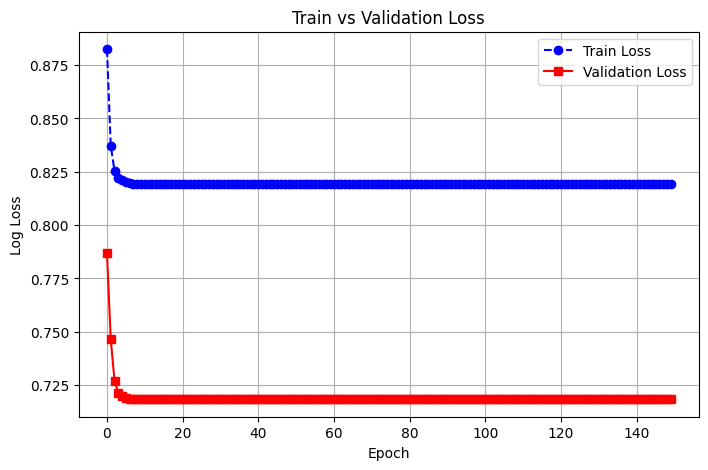

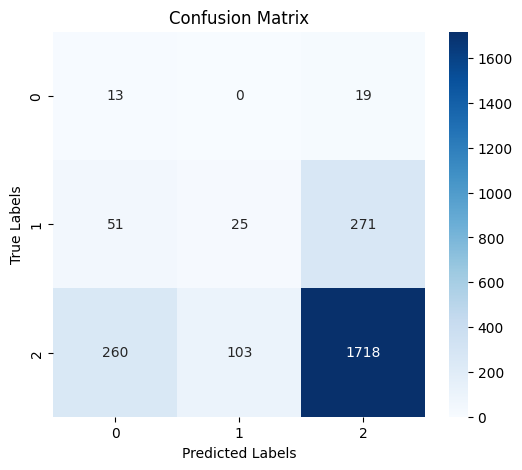

In [74]:
# import optuna
# from sklearn.model_selection import train_test_split, cross_val_score
# from sklearn.linear_model import LogisticRegression
# from sklearn.datasets import load_iris

# def objective(trial, X_train, y_train):
#     C = trial.suggest_loguniform("C", 1e-3, 1e2)
#     solver = trial.suggest_categorical("solver", ["liblinear", "lbfgs", "newton-cg", "saga"])
#     max_iter = trial.suggest_int("max_iter", 50, 300, step=50)

#     model = LogisticRegression(C=C, solver=solver, max_iter=max_iter, random_state=42, multi_class="auto")
#     f1 = cross_val_score(model, X_train, y_train, cv=5, scoring="f1_weighted").mean()
#     precision = cross_val_score(model, X_train, y_train, cv=5, scoring="precision_weighted").mean()
#     recall = cross_val_score(model, X_train, y_train, cv=5, scoring="recall_weighted").mean()

#     trial.set_user_attr("precision", precision)
#     trial.set_user_attr("recall", recall)

#     return f1

# X_train_knn1, y_train_knn1, _ = resample(X_train_pca_ohe, y_train_ohe, method='smote', random_state=42, k_neighbors=5)

# study = optuna.create_study(direction="maximize")
# study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=30)

# # Hasil terbaik
# best_trial = study.best_trial

# print("Best Parameters:", best_trial.params)
# print("Best F1 Score:", best_trial.value)
# print("Best Precision:", best_trial.user_attrs["precision"])
# print("Best Recall:", best_trial.user_attrs["recall"])

# # Menampilkan X_train, y_train, X_test, y_test untuk referensi
# print("\nX_train Shape:", X_train.shape)
# print("y_train Shape:", y_train.shape)
# print("X_test Shape:", X_test.shape)
# print("y_test Shape:", y_test.shape)


import optuna
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.datasets import load_iris


def objective(trial, X_train, y_train):
    C = trial.suggest_loguniform("C", 1e-3, 1e2)
    solver = trial.suggest_categorical("solver", ["liblinear", "lbfgs", "newton-cg", "saga"])
    max_iter = trial.suggest_int("max_iter", 50, 300, step=50)

    model = LogisticRegression(C=C, solver=solver, max_iter=max_iter, random_state=42, multi_class="auto", warm_start=True)

    train_losses = []
    val_losses = []

    for i in range(1, max_iter + 1):
        model.max_iter = i
        model.fit(X_train, y_train)

        train_loss = log_loss(y_train, model.predict_proba(X_train))
        val_loss = log_loss(y_test_ohe, model.predict_proba(X_test_pca_ohe))

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    trial.set_user_attr("train_losses", train_losses)
    trial.set_user_attr("val_losses", val_losses)

    return val_losses[-1]


X_train_ohe1, y_train_ohe1, _ = resample(X_train_pca_ohe, y_train_ohe, method='smote', random_state=42, k_neighbors=5)
study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, X_train_ohe1, y_train_ohe1), n_trials=30)

best_trial = study.best_trial

print("\nBest Parameters:", best_trial.params)
print("Best Validation Loss:", best_trial.value)

best_model = LogisticRegression(
    C=best_trial.params["C"],
    solver=best_trial.params["solver"],
    max_iter=best_trial.params["max_iter"],
    random_state=42,
    multi_class="auto"
)

best_model.fit(X_train_ohe1, y_train_ohe1)
y_pred = best_model.predict(X_test_pca_ohe)

test_precision = precision_score(y_test_ohe, y_pred, average="weighted")
test_recall = recall_score(y_test_ohe, y_pred, average="weighted")
test_f1 = f1_score(y_test_ohe, y_pred, average="weighted")

cm = confusion_matrix(y_test_ohe, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nTest Set Evaluation:")
print("Precision on Test Set:", test_precision)
print("Recall on Test Set:", test_recall)
print("F1 Score on Test Set:", test_f1)

print("\nX_train Shape:", X_train_ohe1.shape)
print("y_train_ohe1 Shape:", y_train_ohe1.shape)
print("X_test Shape:", X_test_pca_ohe.shape)
print("y_test Shape:", y_test_ohe.shape)

best_train_losses = best_trial.user_attrs["train_losses"]
best_val_losses = best_trial.user_attrs["val_losses"]

plt.figure(figsize=(8, 5))
plt.plot(best_train_losses, label="Train Loss", marker="o", linestyle="--", color="blue")
plt.plot(best_val_losses, label="Validation Loss", marker="s", linestyle="-", color="red")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


Resampling menggunakan SMOTE-Tomek.


[I 2025-03-14 02:15:41,948] A new study created in memory with name: no-name-6968bad9-6ef3-4a1f-8a28-5998017c17ae
[I 2025-03-14 02:21:00,893] Trial 0 finished with value: 0.9774148233162938 and parameters: {'C': 1.0255039015059508, 'solver': 'saga', 'max_iter': 200}. Best is trial 0 with value: 0.9774148233162938.
[I 2025-03-14 02:21:12,163] Trial 1 finished with value: 0.978328509008321 and parameters: {'C': 13.48043769556947, 'solver': 'lbfgs', 'max_iter': 300}. Best is trial 0 with value: 0.9774148233162938.
[I 2025-03-14 02:21:17,379] Trial 2 finished with value: 0.9727022033173317 and parameters: {'C': 0.045849861650648464, 'solver': 'newton-cg', 'max_iter': 200}. Best is trial 2 with value: 0.9727022033173317.
[I 2025-03-14 02:21:19,115] Trial 3 finished with value: 0.9720411478371573 and parameters: {'C': 0.03830479282873412, 'solver': 'newton-cg', 'max_iter': 50}. Best is trial 3 with value: 0.9720411478371573.
[I 2025-03-14 02:21:26,393] Trial 4 finished with value: 0.97717694


Best Parameters: {'C': 89.97485356490078, 'solver': 'liblinear', 'max_iter': 100}
Best Validation Loss: 0.953635703692675

Confusion Matrix:
[[  19    4    9]
 [  74  119  154]
 [ 422  568 1091]]

Test Set Evaluation:
Precision on Test Set: 0.760748818532704
Recall on Test Set: 0.49959349593495933
F1 Score on Test Set: 0.5867184895301898

X_train Shape: (24957, 72)
y_train_ohe2 Shape: (24957,)
X_test Shape: (2460, 72)
y_test Shape: (2460,)


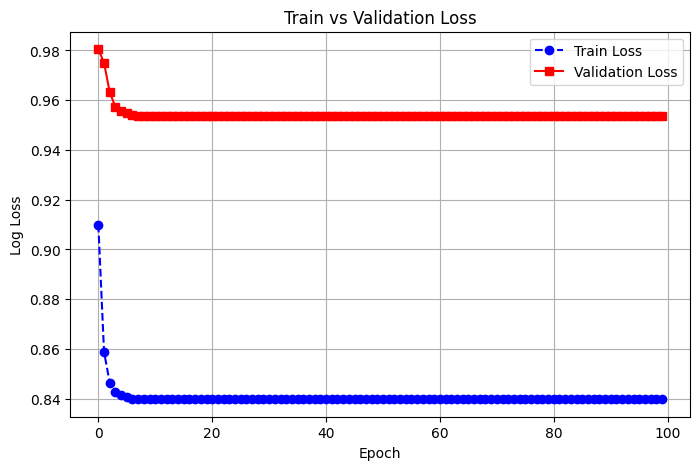

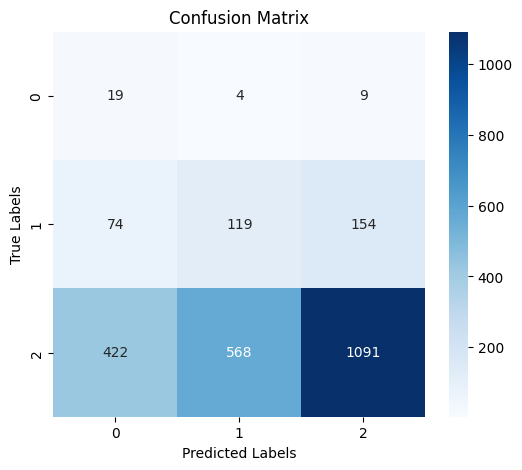

In [75]:

X_train_ohe2, y_train_ohe2, _ = resample(X_train_pca_ohe, y_train_ohe, method='smote_tomek', random_state=42, k_neighbors=5)
study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, X_train_ohe2, y_train_ohe2), n_trials=30)

best_trial = study.best_trial

print("\nBest Parameters:", best_trial.params)
print("Best Validation Loss:", best_trial.value)

best_model = LogisticRegression(
    C=best_trial.params["C"],
    solver=best_trial.params["solver"],
    max_iter=best_trial.params["max_iter"],
    random_state=42,
    multi_class="auto"
)

best_model.fit(X_train_ohe2, y_train_ohe2)
y_pred = best_model.predict(X_test_pca_ohe)

test_precision = precision_score(y_test_ohe, y_pred, average="weighted")
test_recall = recall_score(y_test_ohe, y_pred, average="weighted")
test_f1 = f1_score(y_test_ohe, y_pred, average="weighted")

cm = confusion_matrix(y_test_ohe, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nTest Set Evaluation:")
print("Precision on Test Set:", test_precision)
print("Recall on Test Set:", test_recall)
print("F1 Score on Test Set:", test_f1)

print("\nX_train Shape:", X_train_ohe2.shape)
print("y_train_ohe2 Shape:", y_train_ohe2.shape)
print("X_test Shape:", X_test_pca_ohe.shape)
print("y_test Shape:", y_test_ohe.shape)

best_train_losses = best_trial.user_attrs["train_losses"]
best_val_losses = best_trial.user_attrs["val_losses"]

plt.figure(figsize=(8, 5))
plt.plot(best_train_losses, label="Train Loss", marker="o", linestyle="--", color="blue")
plt.plot(best_val_losses, label="Validation Loss", marker="s", linestyle="-", color="red")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# Heatmap of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


[I 2025-03-14 02:59:32,363] A new study created in memory with name: no-name-d999c543-329b-4bf1-b6f5-30d34fa9d931


Resampling dengan weighted sampling berdasarkan model.


[I 2025-03-14 03:00:36,147] Trial 0 finished with value: 0.4712760542390198 and parameters: {'C': 14.928626749584188, 'solver': 'liblinear', 'max_iter': 200}. Best is trial 0 with value: 0.4712760542390198.
[I 2025-03-14 03:00:43,569] Trial 1 finished with value: 0.4790393392037826 and parameters: {'C': 0.014796849285345286, 'solver': 'liblinear', 'max_iter': 50}. Best is trial 0 with value: 0.4712760542390198.
[I 2025-03-14 03:01:11,381] Trial 2 finished with value: 0.4850071464805293 and parameters: {'C': 0.010136363011124886, 'solver': 'liblinear', 'max_iter': 200}. Best is trial 0 with value: 0.4712760542390198.
[I 2025-03-14 03:01:16,691] Trial 3 finished with value: 0.4712412732180965 and parameters: {'C': 1.447367239835613, 'solver': 'lbfgs', 'max_iter': 250}. Best is trial 3 with value: 0.4712412732180965.
[I 2025-03-14 03:02:08,447] Trial 4 finished with value: 0.4691044210304309 and parameters: {'C': 0.0019410855953043728, 'solver': 'saga', 'max_iter': 200}. Best is trial 4 w


Best Parameters: {'C': 0.004235795467963199, 'solver': 'newton-cg', 'max_iter': 250}
Best Validation Loss: 0.46877253015951686

Confusion Matrix:
[[   0    0   32]
 [   0    0  347]
 [   0    0 2081]]

Test Set Evaluation:
Precision on Test Set: 0.7156059554497984
Recall on Test Set: 0.8459349593495935
F1 Score on Test Set: 0.7753317112558925

X_train Shape: (9836, 72)
y_train_ohe3 Shape: (9836,)
X_test Shape: (2460, 72)
y_test Shape: (2460,)


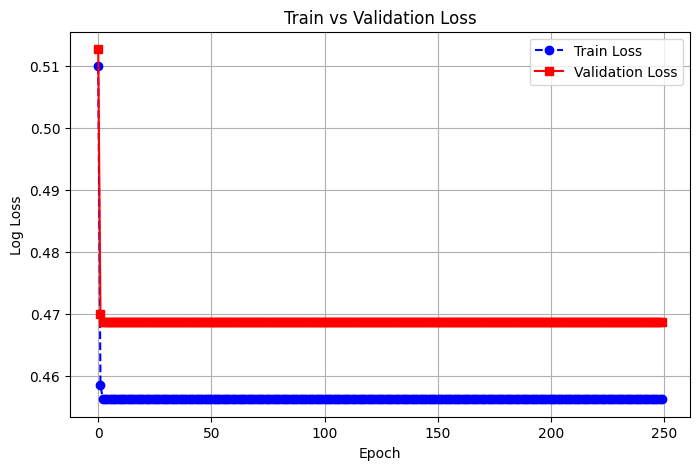

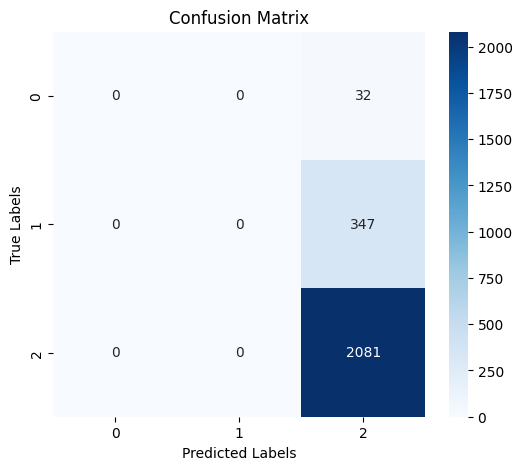

In [76]:

X_train_ohe3, y_train_ohe3, _ = resample(X_train_pca_ohe, y_train_ohe, method='weighted', random_state=42, k_neighbors=5)
study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, X_train_ohe3, y_train_ohe3), n_trials=30)

best_trial = study.best_trial

print("\nBest Parameters:", best_trial.params)
print("Best Validation Loss:", best_trial.value)

best_model = LogisticRegression(
    C=best_trial.params["C"],
    solver=best_trial.params["solver"],
    max_iter=best_trial.params["max_iter"],
    random_state=42,
    multi_class="auto"
)

best_model.fit(X_train_ohe3, y_train_ohe3)
y_pred = best_model.predict(X_test_pca_ohe)

test_precision = precision_score(y_test_ohe, y_pred, average="weighted")
test_recall = recall_score(y_test_ohe, y_pred, average="weighted")
test_f1 = f1_score(y_test_ohe, y_pred, average="weighted")

cm = confusion_matrix(y_test_ohe, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nTest Set Evaluation:")
print("Precision on Test Set:", test_precision)
print("Recall on Test Set:", test_recall)
print("F1 Score on Test Set:", test_f1)

print("\nX_train Shape:", X_train_ohe3.shape)
print("y_train_ohe3 Shape:", y_train_ohe3.shape)
print("X_test Shape:", X_test_pca_ohe.shape)
print("y_test Shape:", y_test_ohe.shape)

best_train_losses = best_trial.user_attrs["train_losses"]
best_val_losses = best_trial.user_attrs["val_losses"]

plt.figure(figsize=(8, 5))
plt.plot(best_train_losses, label="Train Loss", marker="o", linestyle="--", color="blue")
plt.plot(best_val_losses, label="Validation Loss", marker="s", linestyle="-", color="red")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# Heatmap of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


# ET

In [77]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import log_loss, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.datasets import load_iris


def objective(trial, X_train, y_train):
    n_estimators = trial.suggest_int("n_estimators", 50, 300, step=50)
    max_depth = trial.suggest_int("max_depth", 3, 20, step=1)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    model = ExtraTreesClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42,
        warm_start=True
    )

    train_losses = []
    val_losses = []

    for i in range(1, n_estimators + 1):
        model.n_estimators = i
        model.fit(X_train, y_train)

        train_loss = log_loss(y_train, model.predict_proba(X_train))
        val_loss = log_loss(y_test, model.predict_proba(X_test_pca_kfold))

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    trial.set_user_attr("train_losses", train_losses)
    trial.set_user_attr("val_losses", val_losses)

    return val_losses[-1]

In [78]:


# Training extratrees dengan teknik resampling smote...
# Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
# Model: extratrees, Metode Resampling: smote
# F1-Score (Weighted): 0.7632
# F1-Score (Micro): 0.7407
# F1-Score (Macro): 0.4393
# Balanced Accuracy: 0.5307
# ROC-AUC (One-vs-Rest): 0.7196
# Accuracy: 0.7407
# Precision: 0.7917
# Recall: 0.7407
# Confusion Matrix:
# [[  14    4   14]
#  [  22  119  206]
#  [ 116  276 1689]]

# Training extratrees dengan teknik resampling smote_tomek...
# Resampling menggunakan SMOTE-Tomek.
# Model: extratrees, Metode Resampling: smote_tomek
# F1-Score (Weighted): 0.7273
# F1-Score (Micro): 0.6829
# F1-Score (Macro): 0.4164
# Balanced Accuracy: 0.5249
# ROC-AUC (One-vs-Rest): 0.7051
# Accuracy: 0.6829
# Precision: 0.7944
# Recall: 0.6829
# Confusion Matrix:
# [[  13    6   13]
#  [  24  153  170]
#  [ 171  396 1514]]


X_train_et1, y_train_et1, _ = resample(X_train_pca_kfold, y_train_kfold, method='smote', random_state=42, k_neighbors=5)
study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, X_train_et1, y_train_et1), n_trials=30)

best_trial = study.best_trial

print("\nBest Parameters:", best_trial.params)
print("Best Validation Loss:", best_trial.value)

best_model = ExtraTreesClassifier(
    n_estimators=best_trial.params["n_estimators"],
    max_depth=best_trial.params["max_depth"],
    min_samples_split=best_trial.params["min_samples_split"],
    min_samples_leaf=best_trial.params["min_samples_leaf"],
    criterion=best_trial.params["criterion"],
    random_state=42
)

best_model.fit(X_train_et1, y_train_et1)
y_pred = best_model.predict(X_test_pca_kfold)

test_precision = precision_score(y_test_kfold, y_pred, average="weighted")
test_recall = recall_score(y_test_kfold, y_pred, average="weighted")
test_f1 = f1_score(y_test_kfold, y_pred, average="weighted")

cm = confusion_matrix(y_test_kfold, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nTest Set Evaluation:")
print("Precision on Test Set:", test_precision)
print("Recall on Test Set:", test_recall)
print("F1 Score on Test Set:", test_f1)

print("\nX_train Shape:", X_train_et1.shape)
print("y_train Shape:", y_train_et1.shape)
print("X_test Shape:", X_test_pca_kfold.shape)
print("y_test Shape:", y_test.shape)

best_train_losses = best_trial.user_attrs["train_losses"]
best_val_losses = best_trial.user_attrs["val_losses"]

plt.figure(figsize=(8, 5))
plt.plot(best_train_losses, label="Train Loss", marker="o", linestyle="--", color="blue")
plt.plot(best_val_losses, label="Validation Loss", marker="s", linestyle="-", color="red")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# Heatmap of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


[I 2025-03-14 03:11:47,238] A new study created in memory with name: no-name-0cc1cbe4-7a9c-4534-bdec-f1f3993b7d5e
[W 2025-03-14 03:11:47,252] Trial 0 failed with parameters: {'n_estimators': 50, 'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 1, 'criterion': 'gini'} because of the following error: ValueError('Found input variables with inconsistent numbers of samples: [2460, 3689]').
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "<ipython-input-78-a1222dfd072f>", line 36, in <lambda>
    study.optimize(lambda trial: objective(trial, X_train_et1, y_train_et1), n_trials=30)
  File "<ipython-input-77-d87750f239ea>", line 36, in objective
    val_loss = log_loss(y_test, model.predict_proba(X_test_pca_kfold))
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py", line 2592, in log_loss
    check_consistent_length(y_pred, 

Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.


ValueError: Found input variables with inconsistent numbers of samples: [2460, 3689]

In [ ]:


X_train_et2, y_train_et2, _ = resample(X_train_pca_kfold, y_train_kfold, method='smote_tomek', random_state=42, k_neighbors=5)
study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, X_train_et2, y_train_et2), n_trials=30)

best_trial = study.best_trial

print("\nBest Parameters:", best_trial.params)
print("Best Validation Loss:", best_trial.value)

best_model = ExtraTreesClassifier(
    n_estimators=best_trial.params["n_estimators"],
    max_depth=best_trial.params["max_depth"],
    min_samples_split=best_trial.params["min_samples_split"],
    min_samples_leaf=best_trial.params["min_samples_leaf"],
    criterion=best_trial.params["criterion"],
    random_state=42
)

best_model.fit(X_train_et2, y_train_et2)
y_pred = best_model.predict(X_test_pca_kfold)

test_precision = precision_score(y_test_kfold, y_pred, average="weighted")
test_recall = recall_score(y_test_kfold, y_pred, average="weighted")
test_f1 = f1_score(y_test_kfold, y_pred, average="weighted")

cm = confusion_matrix(y_test_kfold, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nTest Set Evaluation:")
print("Precision on Test Set:", test_precision)
print("Recall on Test Set:", test_recall)
print("F1 Score on Test Set:", test_f1)

print("\nX_train Shape:", X_train_et2.shape)
print("y_train Shape:", y_train_et2.shape)
print("X_test Shape:", X_test_pca_kfold.shape)
print("y_test Shape:", y_test.shape)

best_train_losses = best_trial.user_attrs["train_losses"]
best_val_losses = best_trial.user_attrs["val_losses"]

plt.figure(figsize=(8, 5))
plt.plot(best_train_losses, label="Train Loss", marker="o", linestyle="--", color="blue")
plt.plot(best_val_losses, label="Validation Loss", marker="s", linestyle="-", color="red")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# Heatmap of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


# XGBOOST

In [ ]:
import optuna
import numpy as np
import xgboost as xgb
from sklearn.metrics import log_loss
from sklearn.utils.class_weight import compute_class_weight

def objective(trial, X_train, y_train):
    # Calculate class weights
    class_weights = compute_class_weight(
        class_weight='balanced', 
        classes=np.unique(y_train), 
        y=y_train
    )
    
    # Map class weights to the corresponding classes
    class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
    
    # Weights for each instance in the training set
    sample_weights = np.array([class_weight_dict[label] for label in y_train])

    # Define parameters for the XGB model
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_uniform("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_uniform("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-8, 10.0),
        "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-8, 10.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10)
    }

    # Initialize the XGBClassifier
    model = xgb.XGBClassifier(
        **params,
        objective="multi:softprob",
        eval_metric="mlogloss",
        use_label_encoder=False,
        random_state=42
    )

    # Lists to store train and validation losses
    train_losses = []
    val_losses = []

    # Train the model for each iteration up to n_estimators
    for i in range(1, params["n_estimators"] + 1):
        model.set_params(n_estimators=i)
        model.fit(X_train, y_train, sample_weight=sample_weights)

        # Calculate log_loss for train and validation sets
        train_loss = log_loss(y_train, model.predict_proba(X_train))
        val_loss = log_loss(y_test_kfold, model.predict_proba(X_test_pca_kfold))

        # Append the losses for each iteration
        train_losses.append(train_loss)
        val_losses.append(val_loss)

    # Optionally, store these losses as user attributes for later analysis
    trial.set_user_attr("train_losses", train_losses)
    trial.set_user_attr("val_losses", val_losses)

    # Return the last validation loss
    return val_losses[-1]


In [ ]:
# Training xgboost dengan teknik resampling smote...
# Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
# Model: xgboost, Metode Resampling: smote
# F1-Score (Weighted): 0.7595
# F1-Score (Micro): 0.7402
# F1-Score (Macro): 0.4120
# Balanced Accuracy: 0.4727
# ROC-AUC (One-vs-Rest): 0.7160
# Accuracy: 0.7402
# Precision: 0.7824
# Recall: 0.7402
# Confusion Matrix:
# [[  10    4   18]
#  [  22   98  227]
#  [ 137  231 1713]]

# Training xgboost dengan teknik resampling smote_tomek...
# Resampling menggunakan SMOTE-Tomek.
# Model: xgboost, Metode Resampling: smote_tomek
# F1-Score (Weighted): 0.6730
# F1-Score (Micro): 0.6110
# F1-Score (Macro): 0.3839
# Balanced Accuracy: 0.5180
# ROC-AUC (One-vs-Rest): 0.7100
# Accuracy: 0.6110
# Precision: 0.7869
# Recall: 0.6110
# Confusion Matrix:
# [[  14    6   12]
#  [  29  167  151]
#  [ 222  537 1322]]

# Hyperparameter tuning

X_train_xgb1, y_train_xgb1, _ = resample(X_train_pca_kfold, y_train_kfold, method='smote_tomek', random_state=42, k_neighbors=5)
study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, X_train_xgb1, y_train_xgb1), n_trials=30)

best_trial = study.best_trial

print("\nBest Parameters:", best_trial.params)
print("Best Validation Loss:", best_trial.value)

# Train final model with best parameters
best_model = xgb.XGBClassifier(
    **best_trial.params,
    objective="multi:softprob",
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42
)

best_model.fit(X_train_xgb1, y_train_xgb1)
y_pred = best_model.predict(X_test_pca_kfold)

# Evaluation
test_precision = precision_score(y_test_kfold, y_pred, average="weighted")
test_recall = recall_score(y_test_kfold, y_pred, average="weighted")
test_f1 = f1_score(y_test_kfold, y_pred, average="weighted")

cm = confusion_matrix(y_test_kfold, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nTest Set Evaluation:")
print("Precision on Test Set:", test_precision)
print("Recall on Test Set:", test_recall)
print("F1 Score on Test Set:", test_f1)

print("\nX_train Shape:", X_train_xgb1.shape)
print("y_train Shape:", y_train_kfold.shape)
print("X_test Shape:", X_test_kfold.shape)
print("y_test Shape:", y_test.shape)

# Plot Loss Curves
best_train_losses = best_trial.user_attrs["train_losses"]
best_val_losses = best_trial.user_attrs["val_losses"]

plt.figure(figsize=(8, 5))
plt.plot(best_train_losses, label="Train Loss", marker="o", linestyle="--", color="blue")
plt.plot(best_val_losses, label="Validation Loss", marker="s", linestyle="-", color="red")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# Plot Confusion Matrix
# Heatmap of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Training xgboost dengan teknik resampling smote...
# Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
# Model: xgboost, Metode Resampling: smote
# F1-Score (Weighted): 0.7595
# F1-Score (Micro): 0.7402
# F1-Score (Macro): 0.4120
# Balanced Accuracy: 0.4727
# ROC-AUC (One-vs-Rest): 0.7160
# Accuracy: 0.7402
# Precision: 0.7824
# Recall: 0.7402
# Confusion Matrix:
# [[  10    4   18]
#  [  22   98  227]
#  [ 137  231 1713]]

# Training xgboost dengan teknik resampling smote_tomek...
# Resampling menggunakan SMOTE-Tomek.
# Model: xgboost, Metode Resampling: smote_tomek
# F1-Score (Weighted): 0.6730
# F1-Score (Micro): 0.6110
# F1-Score (Macro): 0.3839
# Balanced Accuracy: 0.5180
# ROC-AUC (One-vs-Rest): 0.7100
# Accuracy: 0.6110
# Precision: 0.7869
# Recall: 0.6110
# Confusion Matrix:
# [[  14    6   12]
#  [  29  167  151]
#  [ 222  537 1322]]

# Hyperparameter tuning

X_train_xgb2, y_train_xgb2, _ = resample(X_train_pca_kfold, y_train_kfold, method='smote', random_state=42, k_neighbors=5)
study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, X_train_xgb2, y_train_xgb2), n_trials=30)

best_trial = study.best_trial

print("\nBest Parameters:", best_trial.params)
print("Best Validation Loss:", best_trial.value)

# Train final model with best parameters
best_model = xgb.XGBClassifier(
    **best_trial.params,
    objective="multi:softprob",
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42
)

best_model.fit(X_train_xgb2, y_train_xgb2)
y_pred = best_model.predict(X_test_pca_kfold)

# Evaluation
test_precision = precision_score(y_test_kfold, y_pred, average="weighted")
test_recall = recall_score(y_test_kfold, y_pred, average="weighted")
test_f1 = f1_score(y_test_kfold, y_pred, average="weighted")

cm = confusion_matrix(y_test_kfold, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nTest Set Evaluation:")
print("Precision on Test Set:", test_precision)
print("Recall on Test Set:", test_recall)
print("F1 Score on Test Set:", test_f1)

print("\nX_train Shape:", X_train_xgb1.shape)
print("y_train Shape:", y_train_kfold.shape)
print("X_test Shape:", X_test_kfold.shape)
print("y_test Shape:", y_test.shape)

# Plot Loss Curves
best_train_losses = best_trial.user_attrs["train_losses"]
best_val_losses = best_trial.user_attrs["val_losses"]

plt.figure(figsize=(8, 5))
plt.plot(best_train_losses, label="Train Loss", marker="o", linestyle="--", color="blue")
plt.plot(best_val_losses, label="Validation Loss", marker="s", linestyle="-", color="red")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# Plot Confusion Matrix
# Heatmap of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


# RANDOM FOREST

In [ ]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.datasets import load_iris
def objective(trial, X_train, y_train):
    n_estimators = trial.suggest_int("n_estimators", 50, 300, step=50)
    max_depth = trial.suggest_int("max_depth", 3, 20, step=1)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42,
        warm_start=True
    )

    train_losses = []
    val_losses = []

    for i in range(1, n_estimators + 1):
        model.n_estimators = i
        model.fit(X_train, y_train)

        train_loss = log_loss(y_train, model.predict_proba(X_train))
        val_loss = log_loss(y_test, model.predict_proba(X_test_pca_kfold))

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    trial.set_user_attr("train_losses", train_losses)
    trial.set_user_attr("val_losses", val_losses)

    return val_losses[-1]

In [ ]:


# Training randomforest dengan teknik resampling smote...
# Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
# Model: randomforest, Metode Resampling: smote
# F1-Score (Weighted): 0.7611
# F1-Score (Micro): 0.7382
# F1-Score (Macro): 0.4275
# Balanced Accuracy: 0.5052
# ROC-AUC (One-vs-Rest): 0.7176
# Accuracy: 0.7382
# Precision: 0.7894
# Recall: 0.7382
# Confusion Matrix:
# [[  12    4   16]
#  [  25  114  208]
#  [ 121  270 1690]]

# Training randomforest dengan teknik resampling smote_tomek...
# Resampling menggunakan SMOTE-Tomek.
# Model: randomforest, Metode Resampling: smote_tomek
# F1-Score (Weighted): 0.7147
# F1-Score (Micro): 0.6654
# F1-Score (Macro): 0.4093
# Balanced Accuracy: 0.5236
# ROC-AUC (One-vs-Rest): 0.7085
# Accuracy: 0.6654
# Precision: 0.7943
# Recall: 0.6654
# Confusion Matrix:
# [[  13    7   12]
#  [  26  160  161]
#  [ 174  443 1464]]
# run_all_models_with_resampling(X_train_pca_kfold, y_train_kfold, X_test_pca_kfold, y_test_kfold, 'PCA (KFOLD)')


X_train_rf1, y_train_rf1, _ = resample(X_train_pca_kfold, y_train_kfold, method='smote', random_state=42, k_neighbors=5)
study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, X_train_rf1, y_train_rf1), n_trials=30)

best_trial = study.best_trial

print("\nBest Parameters:", best_trial.params)
print("Best Validation Loss:", best_trial.value)

best_model = RandomForestClassifier(
    n_estimators=best_trial.params["n_estimators"],
    max_depth=best_trial.params["max_depth"],
    min_samples_split=best_trial.params["min_samples_split"],
    min_samples_leaf=best_trial.params["min_samples_leaf"],
    criterion=best_trial.params["criterion"],
    random_state=42
)

best_model.fit(X_train_rf1, y_train_rf1)
y_pred = best_model.predict(X_test_pca_kfold)

test_precision = precision_score(y_test_kfold, y_pred, average="weighted")
test_recall = recall_score(y_test_kfold, y_pred, average="weighted")
test_f1 = f1_score(y_test_kfold, y_pred, average="weighted")

cm = confusion_matrix(y_test_kfold, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nTest Set Evaluation:")
print("Precision on Test Set:", test_precision)
print("Recall on Test Set:", test_recall)
print("F1 Score on Test Set:", test_f1)

print("\nX_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

best_train_losses = best_trial.user_attrs["train_losses"]
best_val_losses = best_trial.user_attrs["val_losses"]

plt.figure(figsize=(8, 5))
plt.plot(best_train_losses, label="Train Loss", marker="o", linestyle="--", color="blue")
plt.plot(best_val_losses, label="Validation Loss", marker="s", linestyle="-", color="red")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# Heatmap of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [ ]:

X_train_rf2, y_train_rf2, _ = resample(X_train_pca_kfold, y_train_kfold, method='smote_tomek', random_state=42, k_neighbors=5)
study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, X_train_rf2, y_train_rf2), n_trials=30)

best_trial = study.best_trial

print("\nBest Parameters:", best_trial.params)
print("Best Validation Loss:", best_trial.value)

best_model = RandomForestClassifier(
    n_estimators=best_trial.params["n_estimators"],
    max_depth=best_trial.params["max_depth"],
    min_samples_split=best_trial.params["min_samples_split"],
    min_samples_leaf=best_trial.params["min_samples_leaf"],
    criterion=best_trial.params["criterion"],
    random_state=42
)

best_model.fit(X_train_rf12, y_train_rf12)
y_pred = best_model.predict(X_test_pca_kfold)

test_precision = precision_score(y_test_kfold, y_pred, average="weighted")
test_recall = recall_score(y_test_kfold, y_pred, average="weighted")
test_f1 = f1_score(y_test_kfold, y_pred, average="weighted")

cm = confusion_matrix(y_test_kfold, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nTest Set Evaluation:")
print("Precision on Test Set:", test_precision)
print("Recall on Test Set:", test_recall)
print("F1 Score on Test Set:", test_f1)

print("\nX_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

best_train_losses = best_trial.user_attrs["train_losses"]
best_val_losses = best_trial.user_attrs["val_losses"]

plt.figure(figsize=(8, 5))
plt.plot(best_train_losses, label="Train Loss", marker="o", linestyle="--", color="blue")
plt.plot(best_val_losses, label="Validation Loss", marker="s", linestyle="-", color="red")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# Heatmap of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()
